In [1]:
import os
import json

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# T20

# TODO: при увеличении числа тем когерентность Ньюмана увеличилась, а интратекст -- уменьшилась

# TODO: 20NG and MKB10 values are just the same for BOW and NOOW (20NG preprocessing the same, MKB10 in NOOW)

DATASET_BAD_COHERENCE_THRESHOLDS_20_TOPTOK = {
    'postnauka': 0.4834872457111293,  # 0.5568860704432789 (bow vw 20%),  # 1.7938763485672071 (intra 10%) 1.890894097939173 (intra 20%)
    '20newsgroups': 0.8497888357888863,  # 0.8497888357888863 (bow vw 20%),  # 1.953001866389115 (intra 10%)
    'mkb10': 0.48898656658973,  # 0.48898656658973 ("bow" vw 20%),  # 1.7434408568528794 (intra 10%) 1.8676456834336237 (intra 20%)
}
DATASET_GOOD_COHERENCE_THRESHOLDS_20_TOPTOK = {
    'postnauka': 0.8825231364747546,  # 0.9154723765333351 (bow vw 80%),  # 2.3394925682940233 (intra 70%) 2.5432101128006273 (intra 80%)
    '20newsgroups': 1.6095355359760972,  # 1.6095355359760972 (bow vw 80%),  # 2.7242325146624466 (intra 70%)
    'mkb10': 0.7372573006249383,  # 0.7372573006249383 ("bow" vw 80%),  # 2.344754594835432 (intra 70%) 2.5358203425535235 (intra 80%)
}

DATASET_BAD_COHERENCE_THRESHOLDS_20 = {
    'postnauka': 1.7938763485672071,  # 0.5568860704432789 (bow vw 20%),  # 1.7938763485672071 (intra 10%) 1.890894097939173 (intra 20%)
    '20newsgroups': 1.953001866389115,  # 0.8497888357888863 (bow vw 20%),  # 1.953001866389115 (intra 10%)
    'mkb10': 1.7434408568528794,  # 0.48898656658973 ("bow" vw 20%),  # 1.7434408568528794 (intra 10%) 1.8676456834336237 (intra 20%)
}
DATASET_GOOD_COHERENCE_THRESHOLDS_20 = {
    'postnauka': 2.3394925682940233,  # 0.9154723765333351 (bow vw 80%),  # 2.3394925682940233 (intra 70%) 2.5432101128006273 (intra 80%)
    '20newsgroups': 2.7242325146624466,  # 1.6095355359760972 (bow vw 80%),  # 2.7242325146624466 (intra 70%)
    'mkb10': 2.344754594835432,  # 0.7372573006249383 ("bow" vw 80%),  # 2.344754594835432 (intra 70%) 2.5358203425535235 (intra 80%)
}


# T50

DATASET_BAD_COHERENCE_THRESHOLDS_50_TOPTOK = {
    'postnauka': 0.5658628223979294,  # 0.6300154717967157 (bow vw 20%),  # 1.2736409984877761 (intra 10%)  # TODO: значения уменьшились при увеличении числа тем
    '20newsgroups': 1.0344350907416338,  # 1.034617754777075 (bow vw 20%),  # 1.3760632784442917 (intra 10%)
    'mkb10': 0.5504721115444576,  # 0.5504721115444576 ("bow" vw 20%),  # 1.2499085596596853 (intra 70%)
}
DATASET_GOOD_COHERENCE_THRESHOLDS_50_TOPTOK = {
    'postnauka': 1.0264533769087847,  # 1.0703095408390997 (bow vw 80%),  # 1.4869940008121474 (intra 70%)
    '20newsgroups': 1.813393592491583,  # 1.8128360841394622 (bow vw 80%),  # 1.7456368947464058 (intra 70%)
    'mkb10': 0.8997333820973618,  # 0.8997333820973618 ("bow" vw 80%),  # 1.5041606723306686 (intra 70%)
}

DATASET_BAD_COHERENCE_THRESHOLDS_50 = {
    'postnauka': 1.2736409984877761,  # 0.6300154717967157 (bow vw 20%),  # 1.2736409984877761 (intra 10%)  # TODO: значения уменьшились при увеличении числа тем
    '20newsgroups': 1.3760632784442917,  # 1.034617754777075 (bow vw 20%),  # 1.3760632784442917 (intra 10%)
    'mkb10': 1.2499085596596853,  # 0.5504721115444576 ("bow" vw 20%),  # 1.2499085596596853 (intra 70%)
}
DATASET_GOOD_COHERENCE_THRESHOLDS_50 = {
    'postnauka': 1.4869940008121474,  # 1.0703095408390997 (bow vw 80%),  # 1.4869940008121474 (intra 70%)
    '20newsgroups': 1.7456368947464058,  # 1.8128360841394622 (bow vw 80%),  # 1.7456368947464058 (intra 70%)
    'mkb10': 1.5041606723306686,  # 0.8997333820973618 ("bow" vw 80%),  # 1.5041606723306686 (intra 70%)
}


DATASET_BAD_COHERENCE_THRESHOLDS_TOPTOK = {
    20: DATASET_BAD_COHERENCE_THRESHOLDS_20_TOPTOK,
    50: DATASET_BAD_COHERENCE_THRESHOLDS_50_TOPTOK
}

DATASET_BAD_COHERENCE_THRESHOLDS = {
    20: DATASET_BAD_COHERENCE_THRESHOLDS_20,
    50: DATASET_BAD_COHERENCE_THRESHOLDS_50
}

DATASET_GOOD_COHERENCE_THRESHOLDS_TOPTOK = {
    20: DATASET_GOOD_COHERENCE_THRESHOLDS_20_TOPTOK,
    50: DATASET_GOOD_COHERENCE_THRESHOLDS_50_TOPTOK
}

DATASET_GOOD_COHERENCE_THRESHOLDS = {
    20: DATASET_GOOD_COHERENCE_THRESHOLDS_20,
    50: DATASET_GOOD_COHERENCE_THRESHOLDS_50
}





DATASET_BEST_ITER_TAUS = {
    'postnauka':     100000,
    '20newsgroups':  100000,
    'mkb10':         100000,
}
DATASET_BEST_ITER2_TAUS = {
    'postnauka':     100000000,
    '20newsgroups':  100000000,
    'mkb10':         100000000,
}

In [3]:
! ls results_intra/

20newsgroups  mkb10  postnauka


In [4]:
! ls results50_intra/

20newsgroups  mkb10  postnauka


In [5]:
! ls results_intra/postnauka

bertopic			      iterative2_100000000_no_decorr_good.json
bertopic.json			      lda_with_cohs.json
decorrelation_with_cohs.json	      plsa_with_cohs.json
iterative_100000.json		      sparse_with_cohs.json
iterative_100000_no_decorr_good.json  tless_with_cohs.json
iterative2_100000000.json


In [6]:
! ls results50/postnauka

ls: cannot access 'results50/postnauka': No such file or directory


In [7]:
! ls results50_intra/postnauka | grep iterative | grep json

iterative_100000.json
iterative2_100000000.json


In [8]:
! ls results50_intra/20newsgroups | grep iterative | grep json

iterative_100000.json
iterative2_100000000.json


In [9]:
! ls results50_intra/mkb10 | grep iterative | grep json

iterative_100000.json
iterative2_100000000.json


In [10]:
! ls results_intra/postnauka | grep iterative | grep json

iterative_100000.json
iterative_100000_no_decorr_good.json
iterative2_100000000.json
iterative2_100000000_no_decorr_good.json


In [11]:
! ls results_intra/20newsgroups | grep iterative | grep json

iterative_100000.json
iterative2_100000000.json


In [12]:
! ls results_intra/mkb10 | grep iterative | grep json

iterative_100000.json
iterative_100000_no_decorr_good.json
iterative2_100000000.json
iterative2_100000000_no_decorr_good.json


In [13]:
! ls results_intra/postnauka | grep iterative | grep json

iterative_100000.json
iterative_100000_no_decorr_good.json
iterative2_100000000.json
iterative2_100000000_no_decorr_good.json


In [14]:
DATA_FOLDER_PATH = '/data_mil/shared/CompressaAI/iterative/data/noow'

In [15]:
! ls $DATA_FOLDER_PATH

_20_Newsgroups.csv	       MKB_10_NOOW__internals
_20_Newsgroups__internals      Post_Science__internals
20_Newsgroups__internals       Post_Science_NOOW.csv
20_Newsgroups_NOOW.csv	       Post_Science_NOOW_fixed.csv
20_Newsgroups_NOOW__internals  Post_Science_NOOW_fixed__internals
_Lenta.csv		       Post_Science_NOOW__internals
MKB_10__internals	       WikiRef_220_NOOW.csv
MKB_10_NOOW.csv


In [16]:
! ls $DATA_FOLDER_PATH | grep '__internals'

_20_Newsgroups__internals
20_Newsgroups__internals
20_Newsgroups_NOOW__internals
MKB_10__internals
MKB_10_NOOW__internals
Post_Science__internals
Post_Science_NOOW_fixed__internals
Post_Science_NOOW__internals


In [17]:
! ls $DATA_FOLDER_PATH/Post_Science__internals

batches  dict.dict  _result  _result2  result2	result2_50  vw.txt


In [18]:
! ls $DATA_FOLDER_PATH/Post_Science_NOOW__internals

batches  dict.dict  vw.txt


In [19]:
! ls $DATA_FOLDER_PATH/Post_Science_NOOW_fixed__internals

batches  dict.dict  vw.txt


In [20]:
! ls $DATA_FOLDER_PATH/Post_Science__internals/result2/search_result__0.json

/data_mil/shared/CompressaAI/iterative/data/noow/Post_Science__internals/result2/search_result__0.json


In [21]:
! cat $DATA_FOLDER_PATH/Post_Science__internals/result2/search_result__0.json

{"optimum": 6, "optimum_std": 0.0, "bank_scores": [{"perplexity_score": 28439.177734375, "coherence_20": 0.9567557076597479, "diversity_euclidean": 0.07520688316023542, "diversity_jensenshannon": 0.6518311789823222, "diversity_hellinger": 0.7552062776689774, "diversity_cosine": 0.8216776639936949, "perplexity": 28439.177734375, "ppl_fair": 28439.177734375, "ppl_cheatty": 4144.4482421875}, {"perplexity_score": 28439.177734375, "coherence_20": 0.9567557076597479, "diversity_euclidean": 0.07520688316023438, "diversity_jensenshannon": 0.6518311789829264, "diversity_hellinger": 0.7552062776686018, "diversity_cosine": 0.8216776639937158, "perplexity": 28439.177734375, "ppl_fair": 28439.177734375, "ppl_cheatty": 4144.4482421875}, {"perplexity_score": 28439.177734375, "coherence_20": 0.9567557076597479, "diversity_euclidean": 0.07520688316023437, "diversity_jensenshannon": 0.6518311789822113, "diversity_hellinger": 0.7552062776676953, "diversity_cosine": 0.8216776639937157, "perplexity": 28439

In [22]:
_topic_bank_results = json.loads(
    open(f'{DATA_FOLDER_PATH}/Post_Science__internals/result2/search_result__0.json').read()
)

In [23]:
_topic_bank_results.keys()

dict_keys(['optimum', 'optimum_std', 'bank_scores', 'bank_topic_scores', 'model_scores', 'model_topic_scores', 'num_bank_topics', 'num_model_topics'])

In [24]:
_topic_bank_results['bank_scores'][0]

{'perplexity_score': 28439.177734375,
 'coherence_20': 0.9567557076597479,
 'diversity_euclidean': 0.07520688316023542,
 'diversity_jensenshannon': 0.6518311789823222,
 'diversity_hellinger': 0.7552062776689774,
 'diversity_cosine': 0.8216776639936949,
 'perplexity': 28439.177734375,
 'ppl_fair': 28439.177734375,
 'ppl_cheatty': 4144.4482421875}

In [25]:
_topic_bank_results['bank_topic_scores'][5]

[{'kernel_size': 1676,
  'toplen_ptw': 2.9137328999468073,
  'coherence_20': 1.2508650222621893,
  'distance_to_nearest': 0.0},
 {'kernel_size': 1683,
  'toplen_ptw': 2.390118941026358,
  'coherence_20': 1.180296731842603,
  'distance_to_nearest': 0.8378806766600361},
 {'kernel_size': 1591,
  'toplen_ptw': 3.234490197330379,
  'coherence_20': 0.43910536887445184,
  'distance_to_nearest': 0.8527573519638529},
 {'kernel_size': 1655,
  'toplen_ptw': 2.5314330221922066,
  'coherence_20': 0.44291428766950486,
  'distance_to_nearest': 0.7971954333613831},
 {'kernel_size': 1833,
  'toplen_ptw': 2.4189702600089356,
  'coherence_20': 0.6362227983980256,
  'distance_to_nearest': 0.7321468671191989}]

In [26]:
_topic_bank_results['num_bank_topics'][5]

5

In [27]:
_topic_bank_results['num_bank_topics']

[3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6]

In [28]:
! ls $DATA_FOLDER_PATH | grep '__internals'

_20_Newsgroups__internals
20_Newsgroups__internals
20_Newsgroups_NOOW__internals
MKB_10__internals
MKB_10_NOOW__internals
Post_Science__internals
Post_Science_NOOW_fixed__internals
Post_Science_NOOW__internals


In [29]:
! ls $DATA_FOLDER_PATH/Post_Science__internals

batches  dict.dict  _result  _result2  result2	result2_50  vw.txt


In [30]:
! ls $DATA_FOLDER_PATH/Post_Science__internals/result2

bank__0  search_result__0.json


In [31]:
! ls $DATA_FOLDER_PATH/20_Newsgroups__internals

batches  dict.dict  _result2  result2  result2_50  vw.txt


In [32]:
! ls $DATA_FOLDER_PATH/MKB_10__internals

batches  dict.dict  _result2  result2  result2_50  vw.txt


In [33]:
DATASET_INTERNALS = {
    'postnauka':     f'{DATA_FOLDER_PATH}/Post_Science__internals',
    '20newsgroups':  f'{DATA_FOLDER_PATH}/20_Newsgroups__internals',
    'mkb10':         f'{DATA_FOLDER_PATH}/MKB_10__internals',
}

## Results

```
RESULTS:
    20:
        dataset:
            model:
                best_iter
                iters:
                    0:
                        ppl
                        coh
                        div
                        num_good
                        percent_good
                        num_bad
                        num_not_good
```

In [34]:
! ls results50_intra/postnauka | grep json

bertopic.json
decorrelation_with_cohs.json
iterative_100000.json
iterative2_100000000.json
lda_with_cohs.json
plsa_with_cohs.json
sparse_with_cohs.json
tless_with_cohs.json


In [35]:
DATASETS = ['postnauka', '20newsgroups', 'mkb10']
MODELS = [
    'plsa', 'sparse', 'decorrelation', 'tless', 'lda',
    'iterative', 'iterative2',
    # 'topic_bank',
    'topic_bank2',
    'bertopic',
]

In [36]:
NUM_TOPICS = [20, 50]
RESULTS = dict()

In [37]:
RESULTS_FOLDER_PREFIX = 'results'

In [38]:
# Load

for num_topics in NUM_TOPICS:
    RESULTS[num_topics] = dict()

    if num_topics == 20:
        results_folder = f'{RESULTS_FOLDER_PREFIX}_intra'
    else:
        results_folder = f'{RESULTS_FOLDER_PREFIX}{num_topics}_intra'

    for dataset in DATASETS:
        RESULTS[num_topics][dataset] = dict()
        dataset_folder = os.path.join(results_folder, dataset)

        for model in MODELS:
            RESULTS[num_topics][dataset][model] = dict()

            if model == 'iterative':
                tau = DATASET_BEST_ITER_TAUS[dataset]
                model_file_name = f'{model}_{tau}.json'
            elif model == 'iterative2':
                tau = DATASET_BEST_ITER2_TAUS[dataset]
                model_file_name = f'{model}_{tau}.json'
            elif model == 'bertopic':
                model_file_name = f'{model}.json'
            elif 'topic_bank' in model:
                internals_folder = DATASET_INTERNALS[dataset]
                suffix1 = model.split('topic_bank')[-1]
                suffix2 = '' if num_topics == 20 else f'_{num_topics}'
                bank_folder = os.path.join(internals_folder, 'result' + suffix1 + suffix2)
                bank_file_path = os.path.join(bank_folder, 'search_result__0.json')
            else:
                # model_file_name = f'{model}.json'
                
                _model_file_name = f'{model}_with_cohs.json'
                _model_file_path = os.path.join(dataset_folder, _model_file_name)
                
                # if os.path.isfile(_model_file_path):
                #     print(f'with cohs here: {_model_file_path}')

                assert os.path.isfile(_model_file_path)

                model_file_name = _model_file_name

            if 'topic_bank' in model:
                model_file_path = bank_file_path
            else:
                model_file_path = os.path.join(dataset_folder, model_file_name)
            
            assert os.path.isfile(model_file_path), (model, model_file_path)

            model_results = json.loads(
                open(model_file_path).read()
            )

            if 'topic_bank' in model:
                topic_coherences = list()
                topic_coherences_intra = list()

                for j, bts in enumerate(model_results['bank_topic_scores']):
                    cur_topic_coherences = dict()
                    cur_topic_coherences_intra = dict()

                    for i, t in enumerate(bts):
                        cur_topic_coherences[str(i)] = t['coherence_20']
                        cur_topic_coherences_intra[str(i)] = t['toplen_ptw']

                    assert model_results['num_bank_topics'][j] == len(cur_topic_coherences)
                    assert model_results['num_bank_topics'][j] == len(cur_topic_coherences_intra)

                    topic_coherences.append(cur_topic_coherences)
                    topic_coherences_intra.append(cur_topic_coherences_intra)

                # _model_results = list(zip(
                #     'scores': model_results['bank_scores'],
                #     'topic_coherences': topic_coherences,
                #     'num_topics': model_results['num_bank_topics']
                # ))

                _model_results = list()

                for i in range(len(model_results['bank_scores'])):
                    _model_results.append({
                        'scores': model_results['bank_scores'][i],
                        'topic_coherences': topic_coherences[i],
                        'topic_coherences_toplen_ptw': topic_coherences_intra[i],
                        'num_topics': model_results['num_bank_topics'][i],
                    })

                model_results = _model_results

            RESULTS[num_topics][dataset][model]['iters'] = model_results

In [39]:
RESULTS.keys()

dict_keys([20, 50])

In [40]:
RESULTS[20].keys()

dict_keys(['postnauka', '20newsgroups', 'mkb10'])

In [41]:
RESULTS[20]['postnauka'].keys()

dict_keys(['plsa', 'sparse', 'decorrelation', 'tless', 'lda', 'iterative', 'iterative2', 'topic_bank2', 'bertopic'])

In [42]:
RESULTS[20]['postnauka']['plsa'].keys()

dict_keys(['iters'])

In [43]:
RESULTS[20]['postnauka']['plsa']['iters'][0]

{'scores': {'perplexity': 2474.488525390625,
  'coherence_20': 0.7306223409796534,
  'toplen_ptw': 2.2222272562846417,
  'topden_ptw': 0.4862072599670759,
  'diversity_euclidean': 0.05432938184650551,
  'diversity_jensenshannon': 0.6000053797380491,
  'diversity_hellinger': 0.6857673609277269,
  'diversity_cosine': 0.7377318746693401},
 'topic_coherences': {'0': 0.4682133200037822,
  '1': 0.5525499039748306,
  '2': 0.3662412591097539,
  '3': 0.7660746688638103,
  '4': 0.6599584504901529,
  '5': 1.2151843412918593,
  '6': 0.784374938331295,
  '7': 0.6583524284174844,
  '8': 0.7558873960285204,
  '9': 0.8872288724338003,
  '10': 0.5060579830596448,
  '11': 1.1643195534386466,
  '12': 1.0551562205101295,
  '13': 0.6667121824386473,
  '14': 0.34910355580365166,
  '15': 0.7823822821267535,
  '16': 1.0022462210267367,
  '17': 0.8400496475709041,
  '18': 0.706545516531718,
  '19': 0.425808078140945},
 'topic_coherences_toplen_ptw': {'0': 2.0956432149414908,
  '1': 2.1535240947120737,
  '2': 2

In [44]:
RESULTS[20]['postnauka']['iterative']['iters'][0]

{'scores': {'perplexity': 2774.171875,
  'coherence_20': 0.8062561214757087,
  'toplen_ptw': 2.0137536426395135,
  'diversity_euclidean': 0.06977662427162117,
  'diversity_jensenshannon': 0.6568446698898736,
  'diversity_hellinger': 0.7646332675128052,
  'diversity_cosine': 0.8117184321457864},
 'topic_coherences': {'0': 0.5030885868011427,
  '1': 0.5542258711717113,
  '2': 0.46083629281021266,
  '3': 0.7784617214308792,
  '4': 0.6874723289012623,
  '5': 1.2508650222621893,
  '6': 0.765747875827312,
  '7': 0.7355746840071614,
  '8': 0.8050386426539775,
  '9': 0.8074832951131057,
  '10': 0.5114946189954674,
  '11': 1.4230164281743303,
  '12': 1.1406572844959169,
  '13': 0.9206501725778948,
  '14': 0.5694339201692713,
  '15': 0.915493440556285,
  '16': 1.180296731842603,
  '17': 0.8075261132335527,
  '18': 0.868654029615445,
  '19': 0.43910536887445184},
 'topic_coherences_toplen_ptw': {'0': 2.0103522136784897,
  '1': 2.1518301958752915,
  '2': 2.111886926248693,
  '3': 1.912091273780993

In [45]:
RESULTS[20]['postnauka']['topic_bank2']['iters'][0]

{'scores': {'perplexity_score': 28439.177734375,
  'coherence_20': 0.9567557076597479,
  'diversity_euclidean': 0.07520688316023542,
  'diversity_jensenshannon': 0.6518311789823222,
  'diversity_hellinger': 0.7552062776689774,
  'diversity_cosine': 0.8216776639936949,
  'perplexity': 28439.177734375,
  'ppl_fair': 28439.177734375,
  'ppl_cheatty': 4144.4482421875},
 'topic_coherences': {'0': 1.2508650222621893,
  '1': 1.180296731842603,
  '2': 0.43910536887445184},
 'topic_coherences_toplen_ptw': {'0': 2.9137328999468073,
  '1': 2.390118941026358,
  '2': 3.234490197330379},
 'num_topics': 3}

In [46]:
RESULTS[20]['postnauka']['bertopic']['iters'][0]

{'scores': {'perplexity': 5831.353515625,
  'coherence_20': 1.1895922630550457,
  'toplen_ptw': 2.488097155991572,
  'diversity_euclidean': 0.05643315561647891,
  'diversity_jensenshannon': 0.6586868390442182,
  'diversity_hellinger': 0.7723483311822209,
  'diversity_cosine': 0.7665362134060419,
  'fair_ppl_free': 4104.3720703125,
  'fair_ppl_fix': 5732.21533203125,
  'unfair_ppl_banklike': 5831.353515625},
 'topic_coherences': {'0': 0.2569302406409139,
  '1': 0.3773557156995919,
  '2': 0.4151826271267152,
  '3': 0.869048069861531,
  '4': 0.34707651257947725,
  '5': 1.1344835564004891,
  '6': 0.7381468059844702,
  '7': 1.868370712245547,
  '8': 2.2936935649937964,
  '9': 0.8091636348624217,
  '10': 2.7444844015225542,
  '11': 1.5617199764971843,
  '12': 1.7821392306432786,
  '13': 1.0615351667879558,
  '14': 0.9731558747867508,
  '15': 0.9624011546092153,
  '16': 1.27555822215827,
  '17': 1.7640648985938334,
  '18': 1.0001747009957196,
  '19': 1.5571601941111977},
 'topic_coherences_to

In [47]:
def get_best_iter(num_topics, dataset, model):
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    good_coherence_threshold = DATASET_GOOD_COHERENCE_THRESHOLDS[num_topics][dataset]
    # bad_coherence_threshold = DATASET_BAD_COHERENCE_THRESHOLDS[num_topics][dataset]
    
    best_iter = None
    best_num_good_topics = None
    best_average_coherence = None

    for i, iter in enumerate(model_iters):
        cur_num_good_topics = sum([
            1 if c >= good_coherence_threshold else 0
            for _, c in iter['topic_coherences_toplen_ptw'].items()
        ])

        if 'iterative' in model:
            assert cur_num_good_topics == iter['num_topics']['good_fair'], (
                cur_num_good_topics, iter['num_topics']['good_fair']
            )
            assert iter['num_topics']['good'] >= iter['num_topics']['good_fair']
            
            cur_num_good_topics = iter['num_topics']['good']

        if 'topic_bank' not in model:
            cur_average_coherence = iter['scores']['toplen_ptw']
        else:
            cur_average_coherence = np.median(list(iter['topic_coherences_toplen_ptw'].values()))

        assert abs(iter['scores']['coherence_20'] - np.mean(list(iter['topic_coherences'].values()))) <= 1e-5, (
            iter['scores']['coherence_20'],
            np.mean(list(iter['topic_coherences'].values()))
        )
        assert abs(cur_average_coherence - np.median(list(iter['topic_coherences_toplen_ptw'].values()))) <= 1e-5

        # Fixing median to mean
        cur_average_coherence = np.mean(list(iter['topic_coherences_toplen_ptw'].values()))

        if (best_iter is None) or (cur_num_good_topics > best_num_good_topics) or (
                cur_num_good_topics == best_num_good_topics and cur_average_coherence > best_average_coherence):
            best_iter = i
            best_num_good_topics = cur_num_good_topics
            best_average_coherence = cur_average_coherence

    return best_iter

In [48]:
get_best_iter(20, 'postnauka', 'plsa')

16

In [49]:
def get_best_iter_fair_itar(num_topics, dataset, model):
    if 'iterative' not in model and 'topic_bank' not in model:
        return get_best_iter(num_topics, dataset, model)

    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    good_coherence_threshold = DATASET_GOOD_COHERENCE_THRESHOLDS[num_topics][dataset]
    # bad_coherence_threshold = DATASET_BAD_COHERENCE_THRESHOLDS[num_topics][dataset]
    
    best_iter = None
    best_num_good_topics = None
    best_average_coherence = None

    for i, iter in enumerate(model_iters):
        cur_num_good_topics = sum([
            1 if c >= good_coherence_threshold else 0
            for _, c in iter['topic_coherences_toplen_ptw'].items()
        ])

        if 'iterative' in model:
            assert cur_num_good_topics == iter['num_topics']['good_fair'], (
                cur_num_good_topics, iter['num_topics']['good_fair']
            )
            assert iter['num_topics']['good'] >= iter['num_topics']['good_fair']

            cur_num_good_topics = iter['num_topics']['good']

        if 'topic_bank' not in model:
            cur_average_coherence = iter['scores']['toplen_ptw']
        else:
            cur_average_coherence = np.median(list(iter['topic_coherences_toplen_ptw'].values()))

        assert abs(iter['scores']['coherence_20'] - np.mean(list(iter['topic_coherences'].values()))) <= 1e-5
        assert abs(cur_average_coherence - np.median(list(iter['topic_coherences_toplen_ptw'].values()))) <= 1e-5

        # Fixing median to mean
        cur_average_coherence = np.mean(list(iter['topic_coherences_toplen_ptw'].values()))

        # if (best_iter is None) or (cur_num_good_topics > best_num_good_topics) or (
        #         cur_num_good_topics == best_num_good_topics and cur_average_coherence > best_average_coherence):
        best_iter = i
        best_num_good_topics = cur_num_good_topics
        best_average_coherence = cur_average_coherence

    assert best_iter == len(model_iters) - 1

    return best_iter

In [50]:
def get_perplexities(num_topics, dataset, model, key='perplexity'):
    # TODO: DRY (get coherences)
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']

    iters = []
    perplexities = []

    for i, iter in enumerate(model_iters):
        cur_perplexity = iter['scores'][key]
        perplexities.append(cur_perplexity)
        iters.append(i)

    return iters, perplexities


def get_coherences(num_topics, dataset, model):
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']

    iters = []
    coherences = []

    for i, iter in enumerate(model_iters):
        _cur_average_coherence = iter['scores']['coherence_20']
        _cur_average_coherence_expected = float(np.mean(list(iter['topic_coherences'].values())))
        assert abs(_cur_average_coherence - _cur_average_coherence_expected) <= 1e-5, (
            _cur_average_coherence, _cur_average_coherence_expected
        )

        if 'topic_bank' not in model:
            cur_average_coherence = iter['scores']['toplen_ptw']
            cur_average_coherence_expected = float(np.mean(list(iter['topic_coherences_toplen_ptw'].values())))
            cur_average_coherence_not_expected = np.median(list(iter['topic_coherences_toplen_ptw'].values()))
            assert abs(cur_average_coherence - cur_average_coherence_not_expected) <= 1e-5, (
                cur_average_coherence,
                cur_average_coherence_expected,
                cur_average_coherence_not_expected
            )

            cur_average_coherence = cur_average_coherence_expected
        else:
            cur_average_coherence_expected = float(np.mean(list(iter['topic_coherences_toplen_ptw'].values())))
            cur_average_coherence = cur_average_coherence_expected
    
        coherences.append(cur_average_coherence)
        iters.append(i)

    return iters, coherences


def get_nums_good_topics(num_topics, dataset, model):
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    good_coherence_threshold = DATASET_GOOD_COHERENCE_THRESHOLDS[num_topics][dataset]

    iters = []
    nums_good_topics = []

    for i, iter in enumerate(model_iters):
        cur_num_good_topics = sum([
            1 if c >= good_coherence_threshold else 0
            for _, c in iter['topic_coherences_toplen_ptw'].items()
        ])

        if 'iterative' in model:
            assert cur_num_good_topics == iter['num_topics']['good_fair'], (
                cur_num_good_topics, iter['num_topics']['good_fair']
            )
            assert iter['num_topics']['good'] >= iter['num_topics']['good_fair']
            
            cur_num_good_topics = iter['num_topics']['good']

        nums_good_topics.append(cur_num_good_topics)
        iters.append(i)

    return iters, nums_good_topics


def get_num_good_topics_percents(num_topics, dataset, model):
    iters, nums_good_topics = get_nums_good_topics(num_topics, dataset, model)

    return iters, [
        n / num_topics * 100 for n in nums_good_topics
    ]


def get_nums_bad_topics(num_topics, dataset, model):
    # TODO: DRY (get nums good)
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    bad_coherence_threshold = DATASET_BAD_COHERENCE_THRESHOLDS[num_topics][dataset]

    iters = []
    nums_bad_topics = []

    for i, iter in enumerate(model_iters):
        cur_num_bad_topics = sum([
            1 if c <= bad_coherence_threshold else 0
            for _, c in iter['topic_coherences_toplen_ptw'].items()
        ])

        if 'iterative' in model:
            # TODO: good_fair
            assert cur_num_bad_topics == iter['num_topics']['bad'], (cur_num_good_topics, model_results['num_topics']['good'])

        nums_bad_topics.append(cur_num_bad_topics)
        iters.append(i)

    return iters, nums_bad_topics


def get_num_bad_topics_percents(num_topics, dataset, model):
    iters, nums_bad_topics = get_nums_bad_topics(num_topics, dataset, model)

    return iters, [
        n / num_topics * 100 for n in nums_bad_topics
    ]


def get_diversities_js(num_topics, dataset, model):
    # TODO: DRY (get coherences)
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']

    iters = []
    diversities = []

    for i, iter in enumerate(model_iters):
        cur_diversity = iter['scores']['diversity_jensenshannon']
        diversities.append(cur_diversity)
        iters.append(i)

    return iters, diversities


def get_diversities_cos(num_topics, dataset, model):
    # TODO: DRY (get coherences)
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']

    iters = []
    diversities = []

    for i, iter in enumerate(model_iters):
        cur_diversity = iter['scores']['diversity_cosine']
        diversities.append(cur_diversity)
        iters.append(i)

    return iters, diversities

In [51]:
get_best_iter(20, 'postnauka', 'plsa')

16

In [52]:
get_perplexities(20, 'postnauka', 'plsa')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2474.488525390625,
  2494.68310546875,
  2495.913330078125,
  2494.03759765625,
  2481.01123046875,
  2469.795166015625,
  2488.78271484375,
  2484.35498046875,
  2490.2431640625,
  2484.33349609375,
  2476.456787109375,
  2509.462646484375,
  2491.395751953125,
  2486.78857421875,
  2494.15869140625,
  2479.610595703125,
  2495.814208984375,
  2515.067626953125,
  2501.256591796875,
  2499.995849609375])

In [53]:
get_nums_good_topics(20, 'postnauka', 'plsa')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [6, 6, 7, 8, 7, 7, 6, 9, 6, 7, 6, 8, 5, 6, 7, 6, 9, 6, 6, 5])

In [54]:
get_coherences(20, 'postnauka', 'plsa')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2.3297644686508625,
  2.290333857890812,
  2.2597690072793855,
  2.3020547170345886,
  2.3006873391800102,
  2.275196681959849,
  2.2840964345067802,
  2.276436883247336,
  2.290353004863888,
  2.2842100039007973,
  2.3068872827469726,
  2.306143070365361,
  2.301788836357334,
  2.2935562915836085,
  2.2887886712423002,
  2.3150747289016995,
  2.2990470892178836,
  2.2221800082748704,
  2.2879633533073864,
  2.273622591432073])

In [55]:
get_perplexities(20, 'postnauka', 'plsa')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2474.488525390625,
  2494.68310546875,
  2495.913330078125,
  2494.03759765625,
  2481.01123046875,
  2469.795166015625,
  2488.78271484375,
  2484.35498046875,
  2490.2431640625,
  2484.33349609375,
  2476.456787109375,
  2509.462646484375,
  2491.395751953125,
  2486.78857421875,
  2494.15869140625,
  2479.610595703125,
  2495.814208984375,
  2515.067626953125,
  2501.256591796875,
  2499.995849609375])

In [56]:
get_perplexities(20, 'postnauka', 'bertopic')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [5831.353515625,
  5685.1552734375,
  5974.0439453125,
  5621.34130859375,
  5668.0283203125,
  5910.8203125,
  5709.57763671875,
  5979.59033203125,
  5895.83251953125,
  5438.2412109375,
  6035.0,
  5820.611328125,
  5868.0888671875,
  5683.3359375,
  6060.69091796875,
  5864.00439453125,
  5917.9140625,
  5778.27587890625,
  5788.3251953125,
  5821.53173828125])

In [57]:
get_best_iter(20, 'postnauka', 'topic_bank2')

12

In [58]:
get_perplexities(20, 'postnauka', 'topic_bank2')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [28439.177734375,
  28439.177734375,
  28439.177734375,
  19434.2578125,
  19913.849609375,
  19913.849609375,
  19913.849609375,
  19913.849609375,
  19913.849609375,
  19913.849609375,
  19913.849609375,
  19913.849609375,
  16017.2265625,
  16017.2265625,
  16017.2265625,
  16017.2265625,
  16017.2265625,
  16017.2265625,
  16017.2265625,
  16017.2265625])

In [59]:
get_coherences(20, 'postnauka', 'topic_bank2')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2.8461140127678477,
  2.8461140127678477,
  2.8461140127678477,
  2.730100739863578,
  2.697749064100937,
  2.697749064100937,
  2.697749064100937,
  2.697749064100937,
  2.697749064100937,
  2.697749064100937,
  2.697749064100937,
  2.697749064100937,
  2.771310504396071,
  2.771310504396071,
  2.771310504396071,
  2.771310504396071,
  2.771310504396071,
  2.771310504396071,
  2.771310504396071,
  2.771310504396071])

In [60]:
get_nums_good_topics(20, 'postnauka', 'topic_bank2')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6])

In [61]:
DATASETS

['postnauka', '20newsgroups', 'mkb10']

In [62]:
MODELS

['plsa',
 'sparse',
 'decorrelation',
 'tless',
 'lda',
 'iterative',
 'iterative2',
 'topic_bank2',
 'bertopic']

In [63]:
[p for p in plt.rcParams if 'font' in p]

['font.cursive',
 'font.family',
 'font.fantasy',
 'font.monospace',
 'font.sans-serif',
 'font.serif',
 'font.size',
 'font.stretch',
 'font.style',
 'font.variant',
 'font.weight',
 'legend.fontsize',
 'legend.title_fontsize',
 'mathtext.fontset',
 'pdf.fonttype',
 'pdf.use14corefonts',
 'pgf.rcfonts',
 'ps.fonttype',
 'svg.fonttype']

In [64]:
plt.rcParams['font.size']

10.0

In [65]:
plt.rcParams['font.size'] = 18

In [66]:
FIGSIZE = (20, 10)
LINEWIDTH = 2
MARKERSIZE = 20

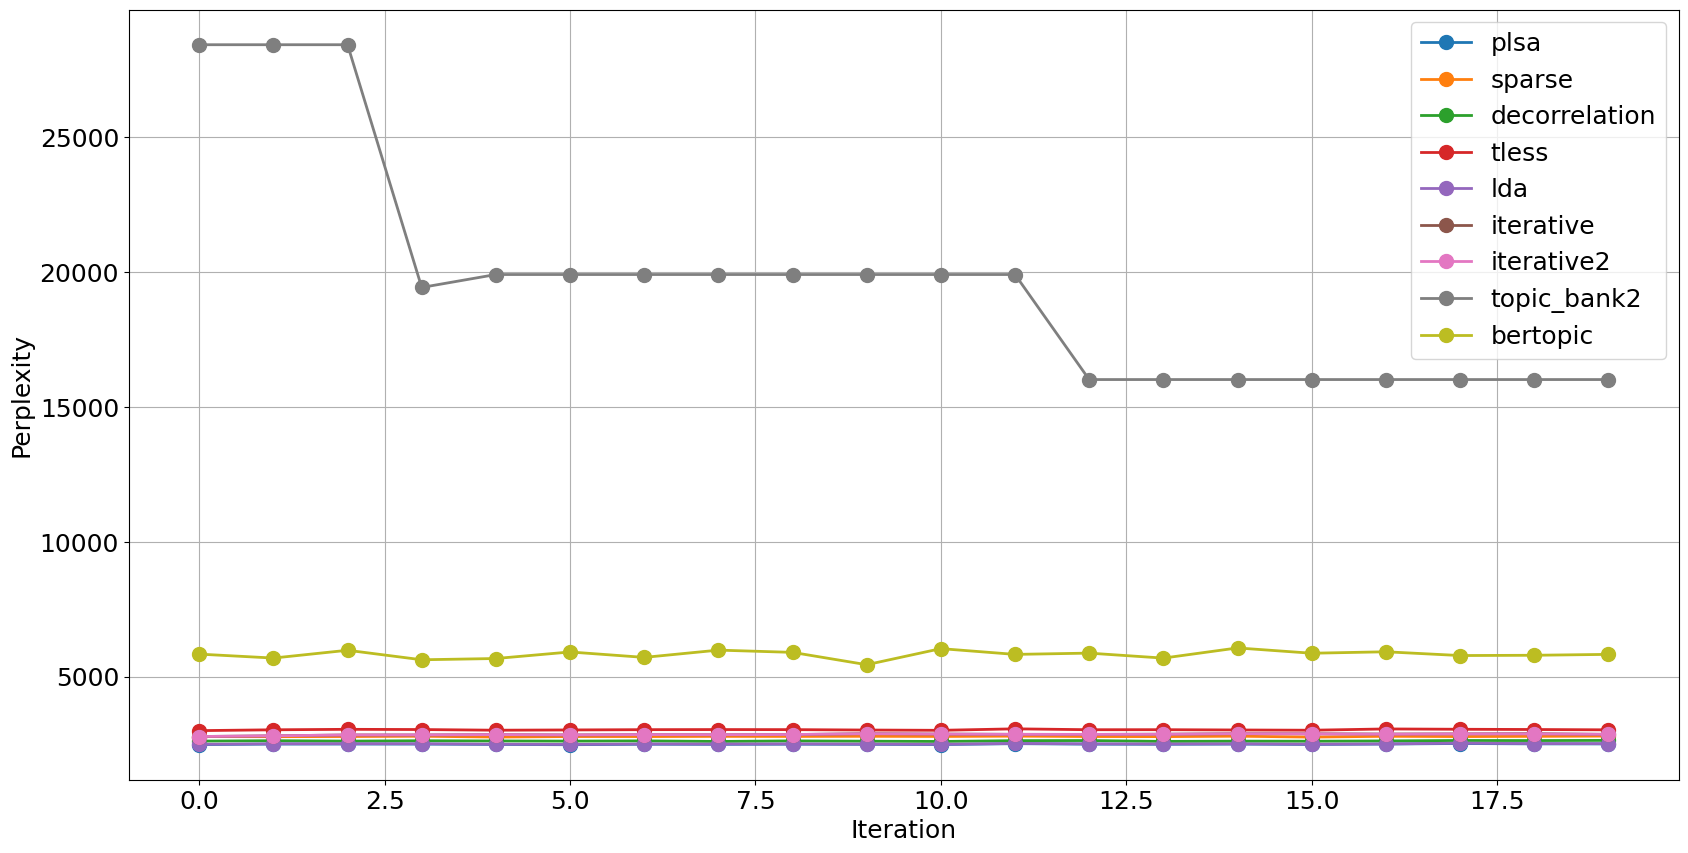

In [67]:
dataset = 'postnauka'
num_topics = 20
getter = get_perplexities


fig, ax = plt.subplots(figsize=FIGSIZE)


for model in MODELS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=LINEWIDTH, marker='.', ms=MARKERSIZE, label=model)

plt.xlabel('Iteration')
plt.ylabel('Perplexity')

plt.grid()
plt.legend()

plt.show()

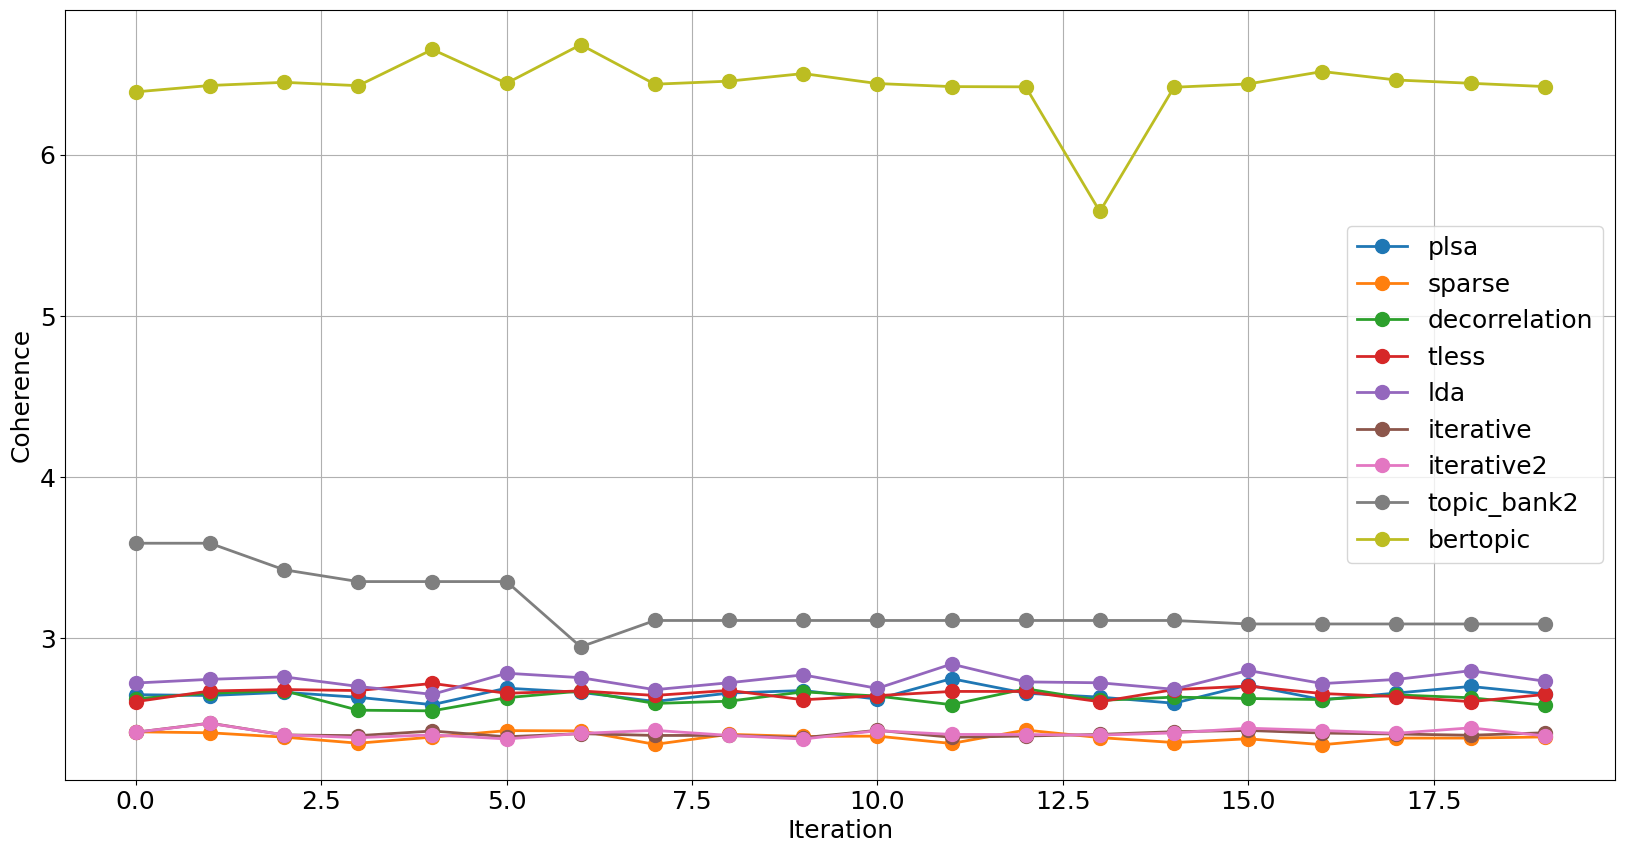

In [68]:
dataset = '20newsgroups'
num_topics = 20
getter = get_coherences
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=FIGSIZE)


for model in MODELS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=LINEWIDTH, marker='.', ms=MARKERSIZE, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

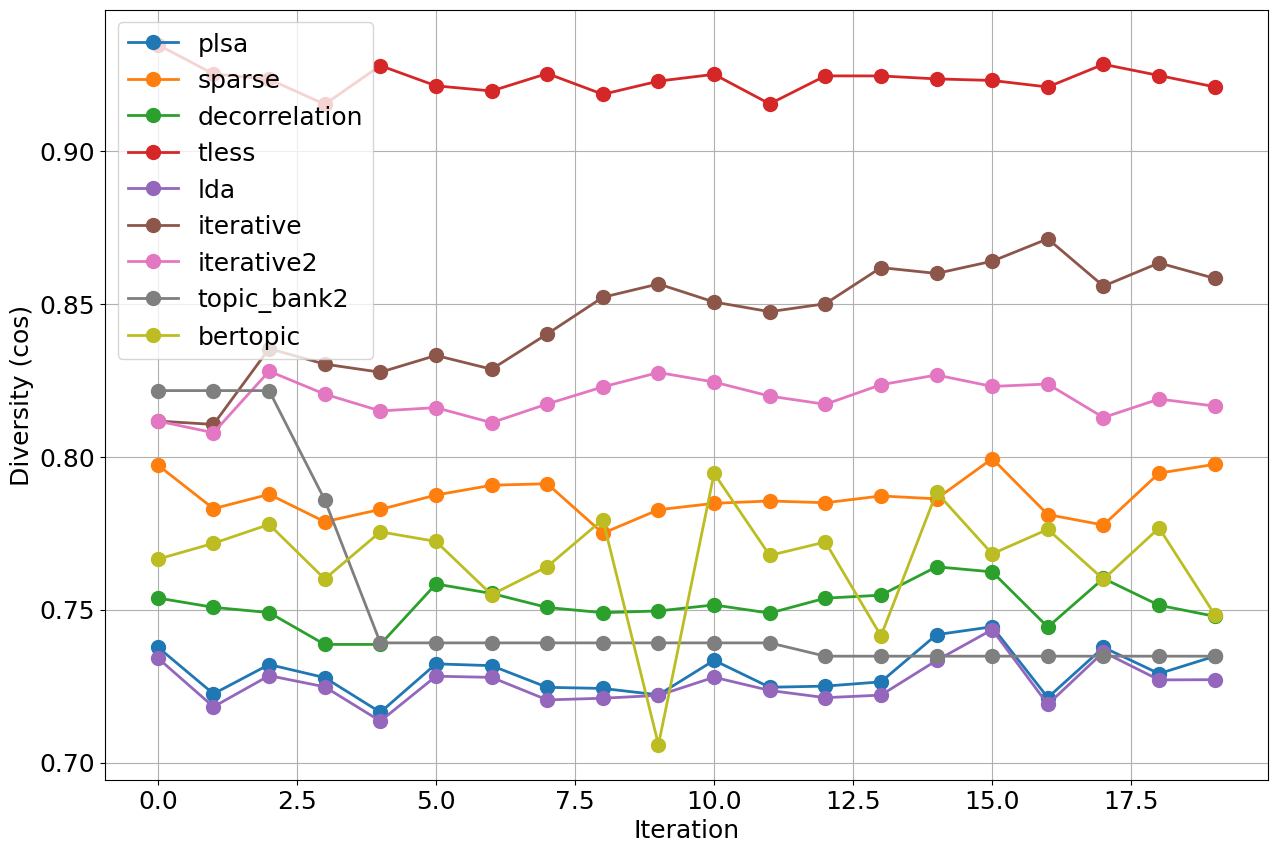

In [290]:
dataset = 'postnauka'
num_topics = 20
getter = get_diversities_cos
ylabel = 'Diversity (cos)'

fig, ax = plt.subplots(figsize=FIGSIZE)


for model in MODELS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=LINEWIDTH, marker='.', ms=MARKERSIZE, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

In [244]:
MODELS_FOR_PLOTS = [
    'decorrelation', 'tless', 'lda', 'bertopic',
    # 'topic_bank',
    'topic_bank2', 'iterative', 'iterative2',
]
MODELS_FOR_PLOTS2 = [
    'decorrelation', 'tless', 'lda', 'bertopic', 'topic_bank2', 'iterative2',
]

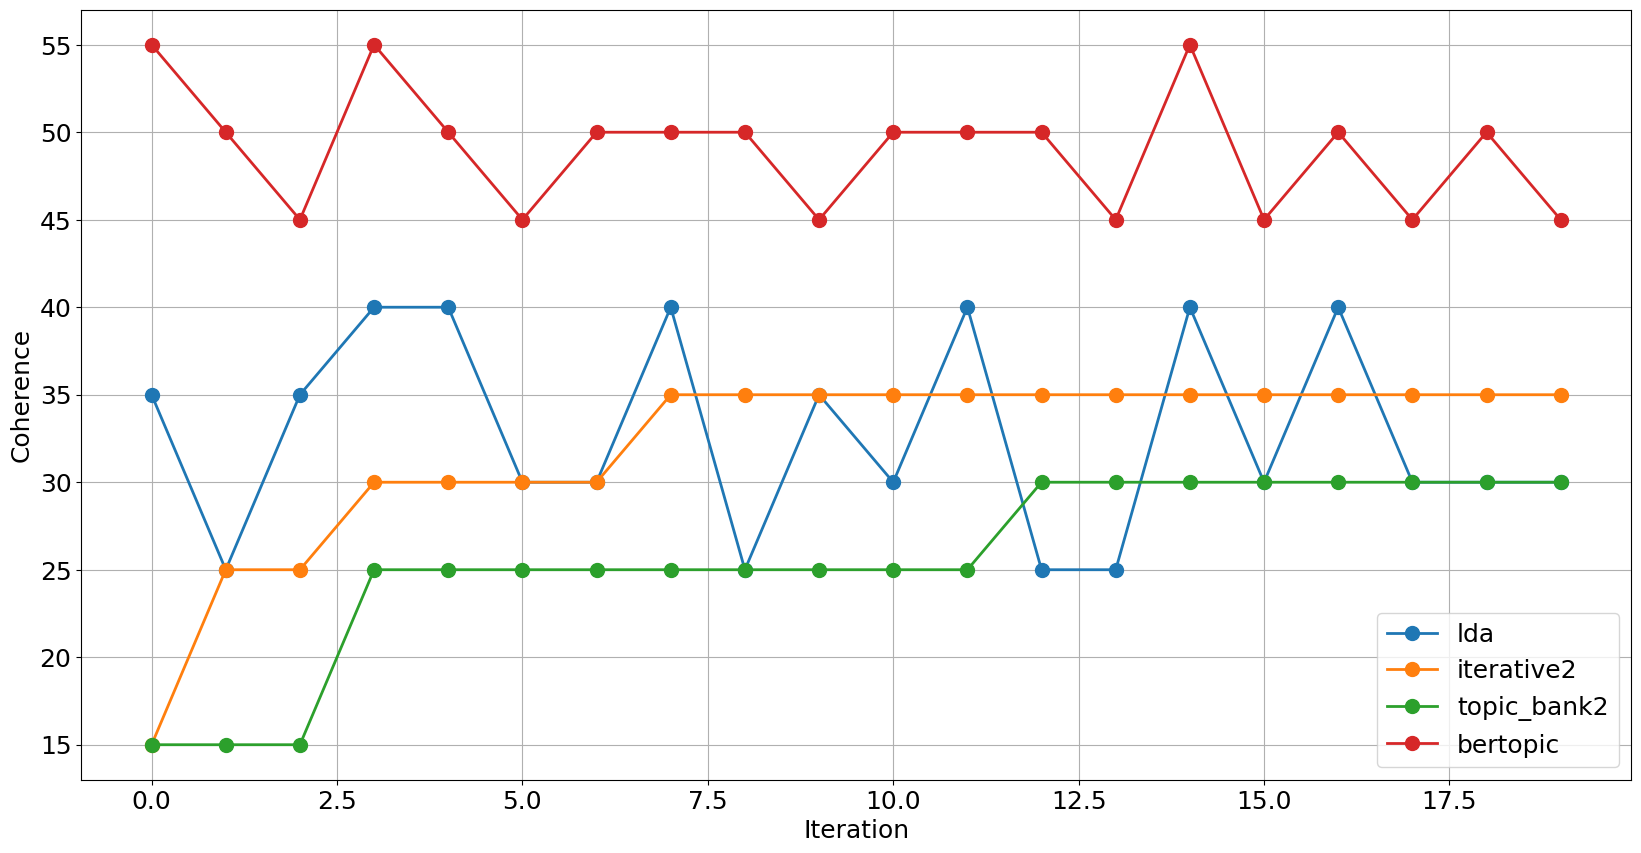

In [291]:
dataset = 'postnauka'
num_topics = 20
getter = get_num_good_topics_percents
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=(20, 10))


for model in ['lda', 'iterative2', 'topic_bank2', 'bertopic']:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

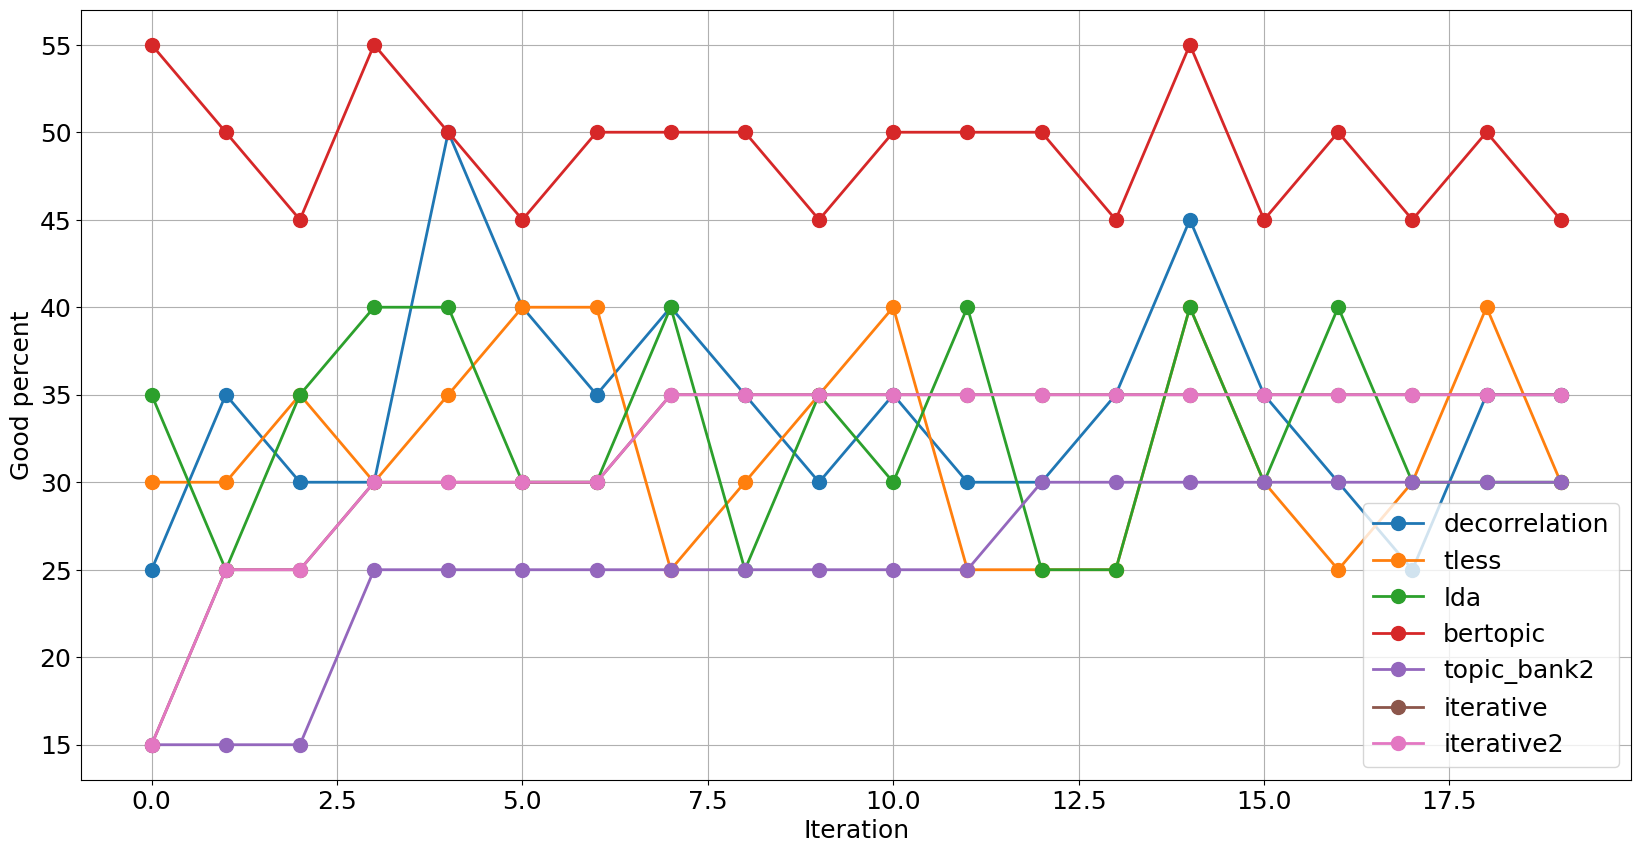

In [293]:
# Bad (iter)

dataset = 'postnauka'
num_topics = 20
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

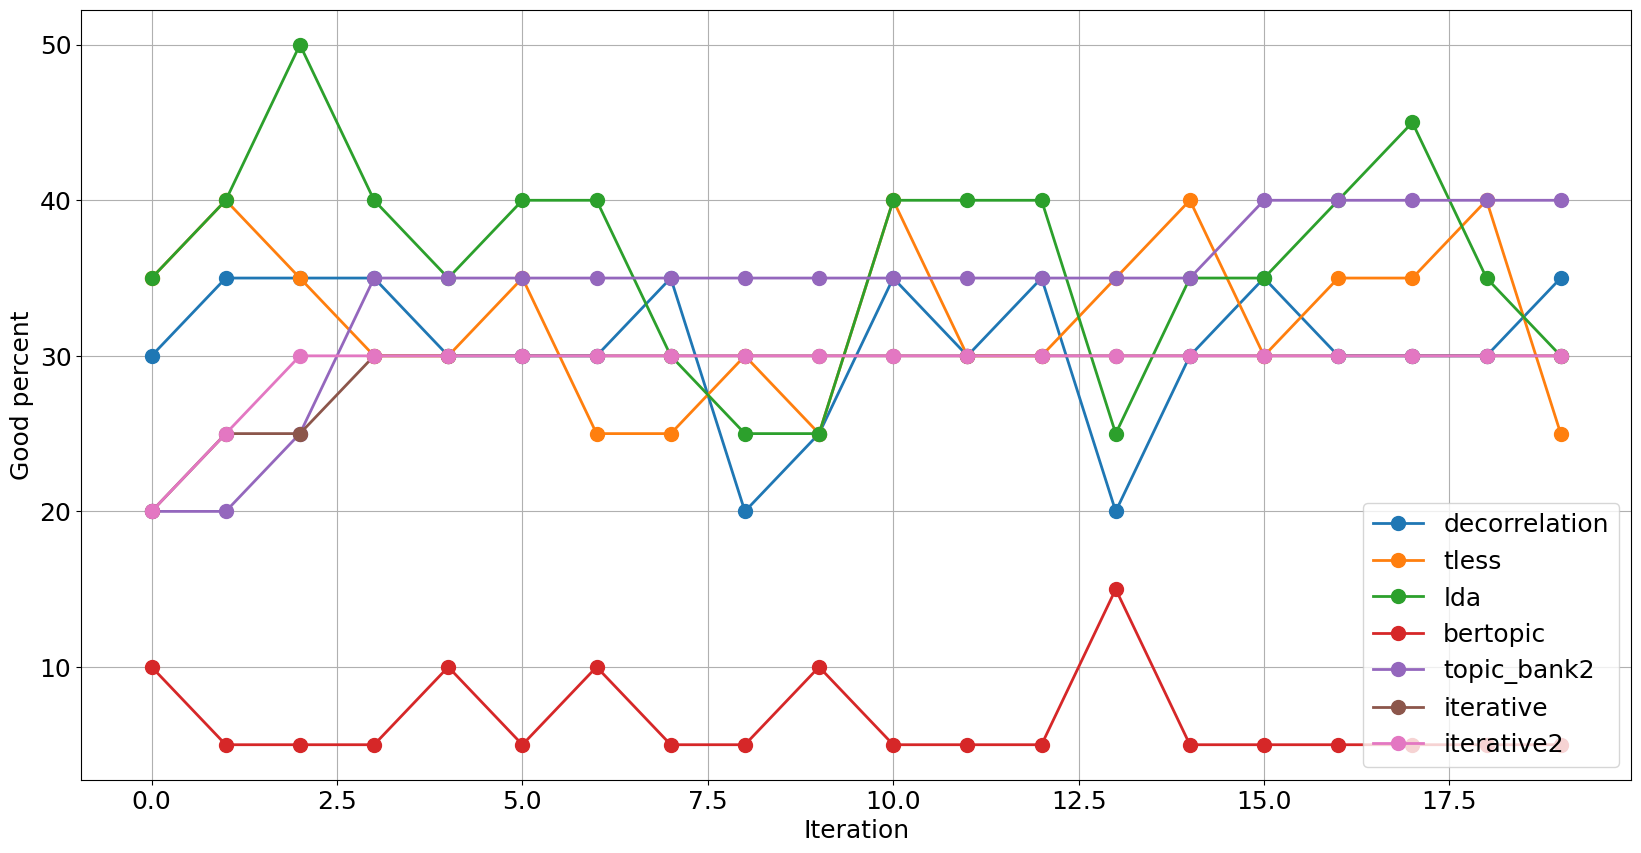

In [294]:
dataset = '20newsgroups'
num_topics = 20
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

In [295]:
DATASETS

['postnauka', '20newsgroups', 'mkb10']

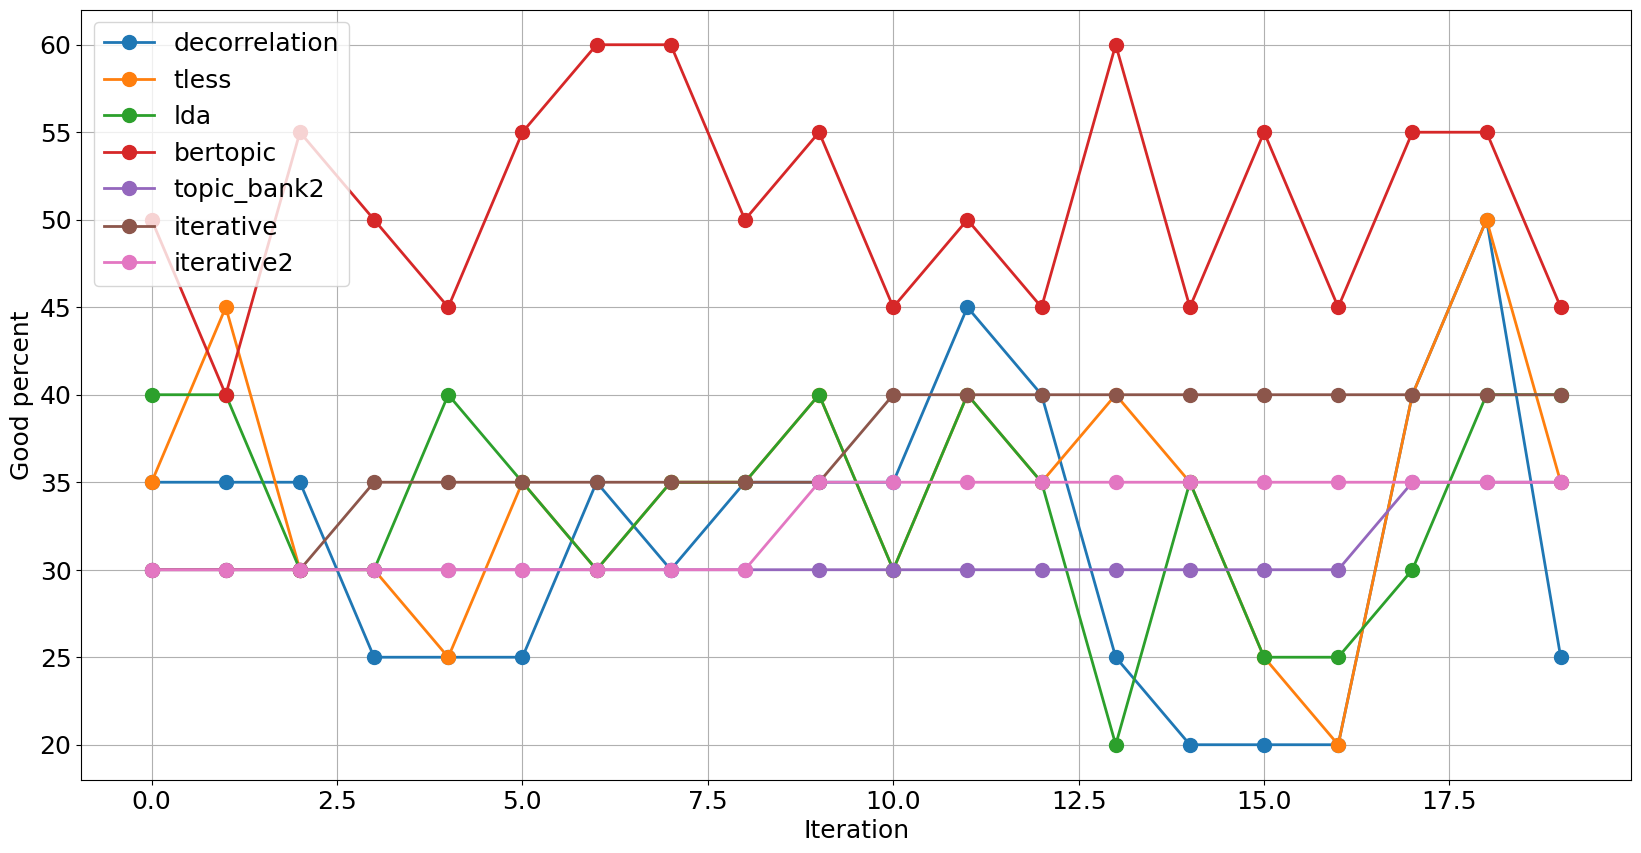

In [296]:
dataset = 'mkb10'
num_topics = 20
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

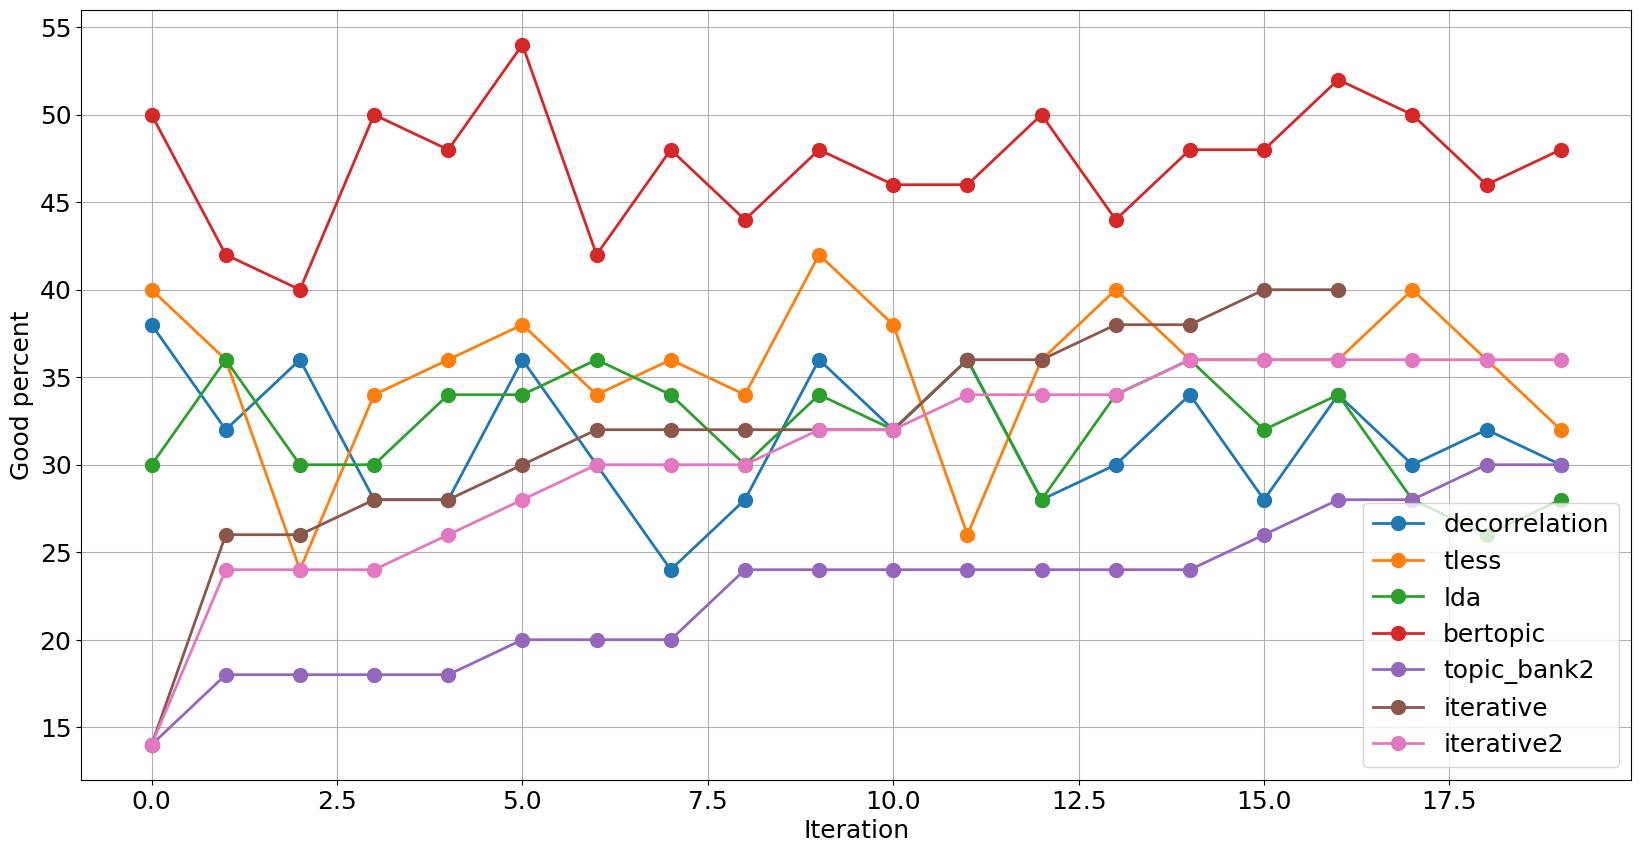

In [298]:
# Bad (iter)

dataset = 'postnauka'
num_topics = 50
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:  # ['iterative'] +  MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

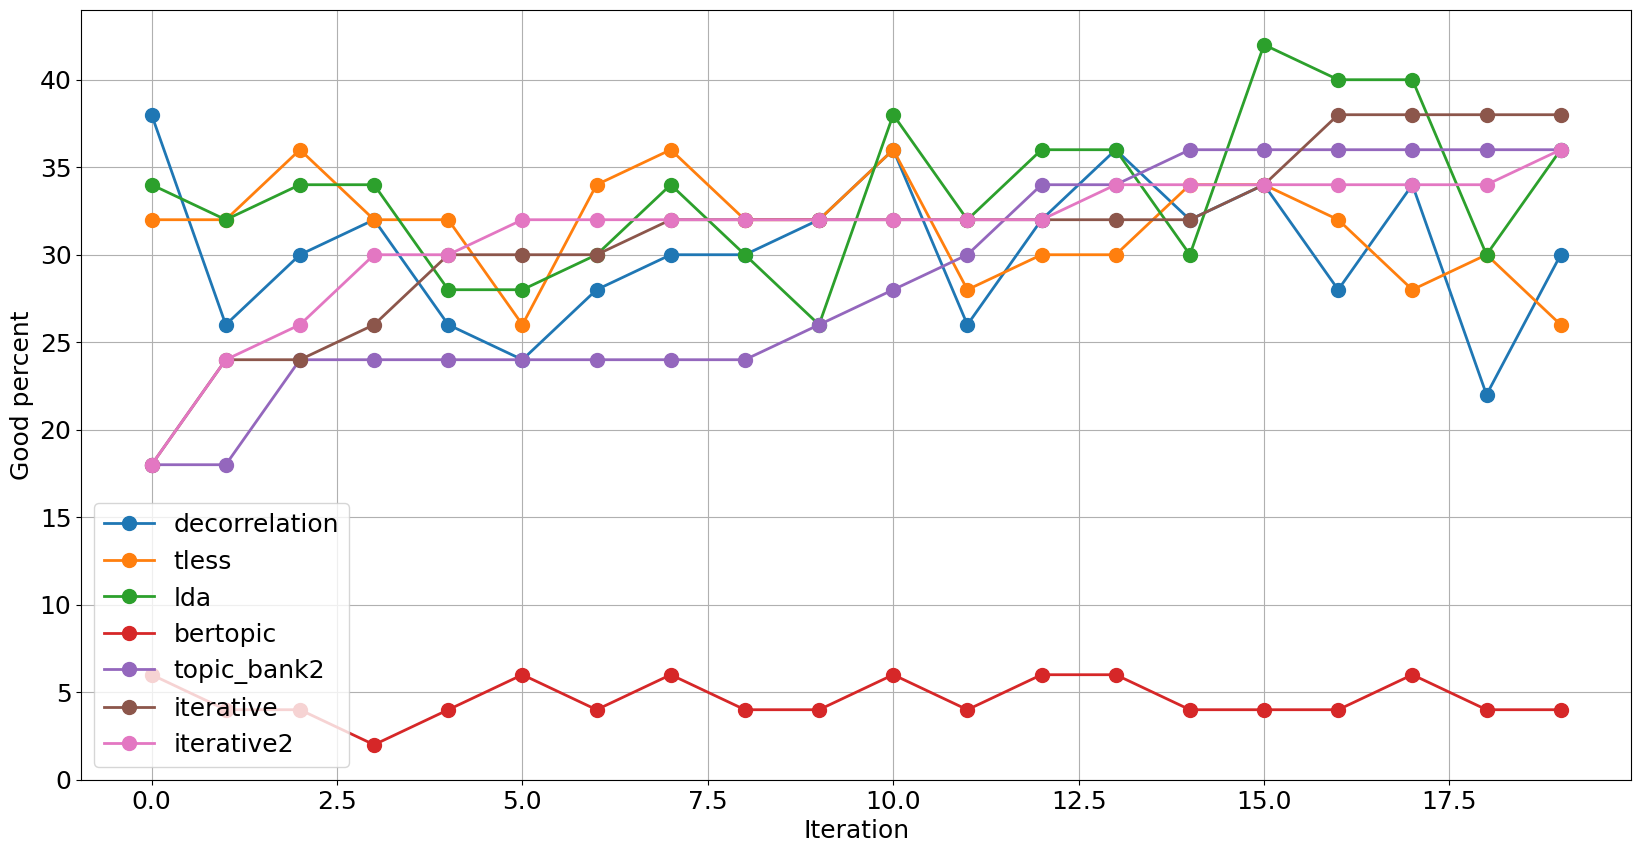

In [300]:
# Not so good plot (iter)

dataset = '20newsgroups'
num_topics = 50
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:  #['iterative'] +  MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

In [301]:
DATASETS

['postnauka', '20newsgroups', 'mkb10']

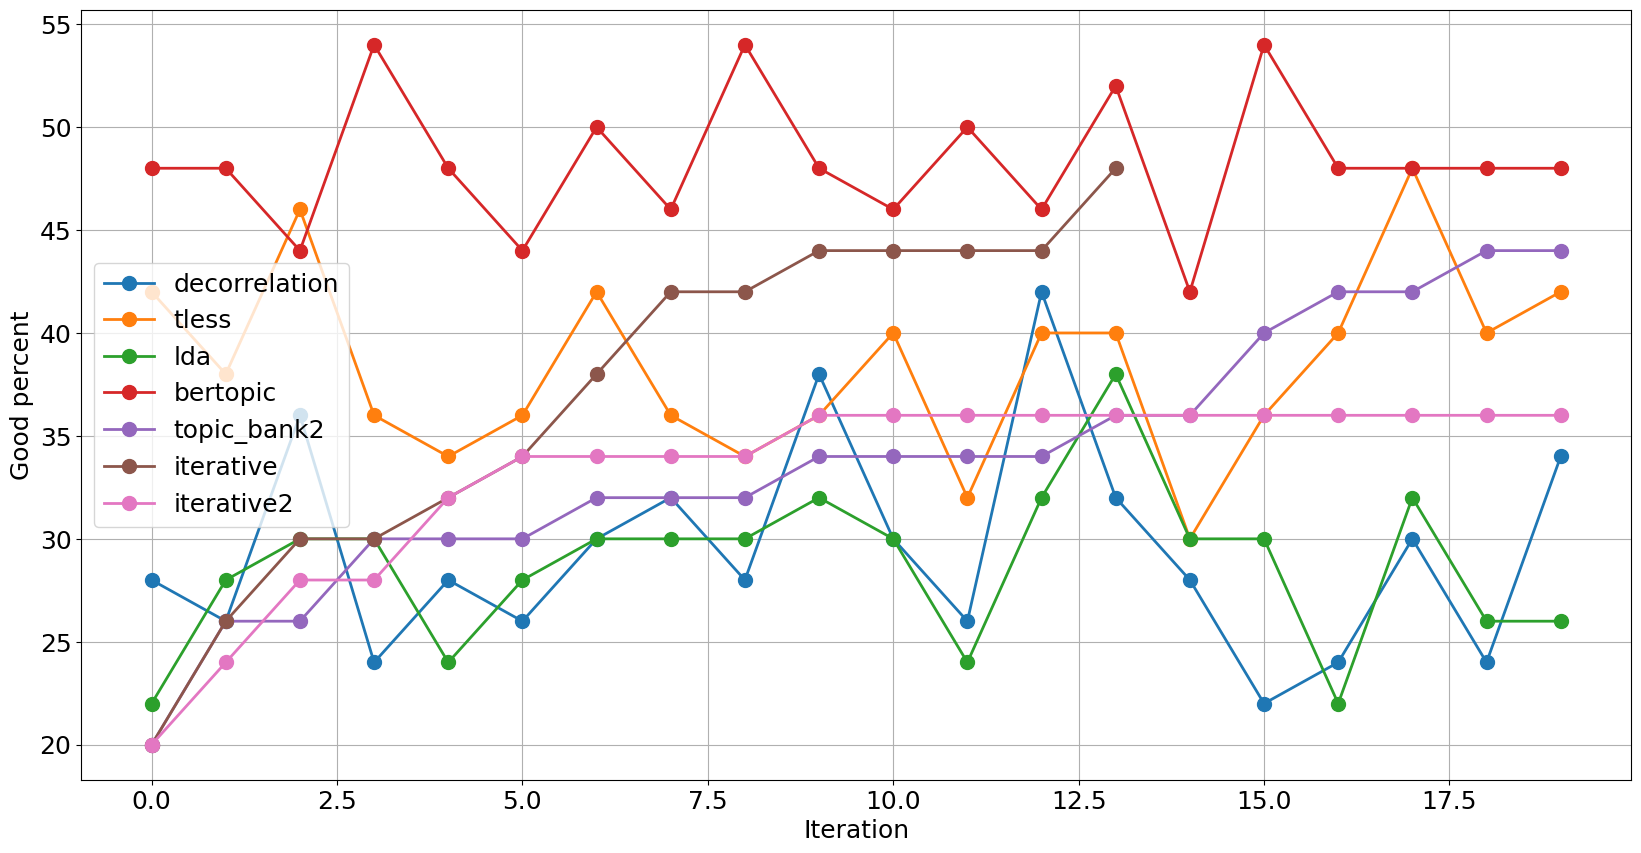

In [302]:
dataset = 'mkb10'
num_topics = 50
getter = get_num_good_topics_percents
ylabel = 'Good percent'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

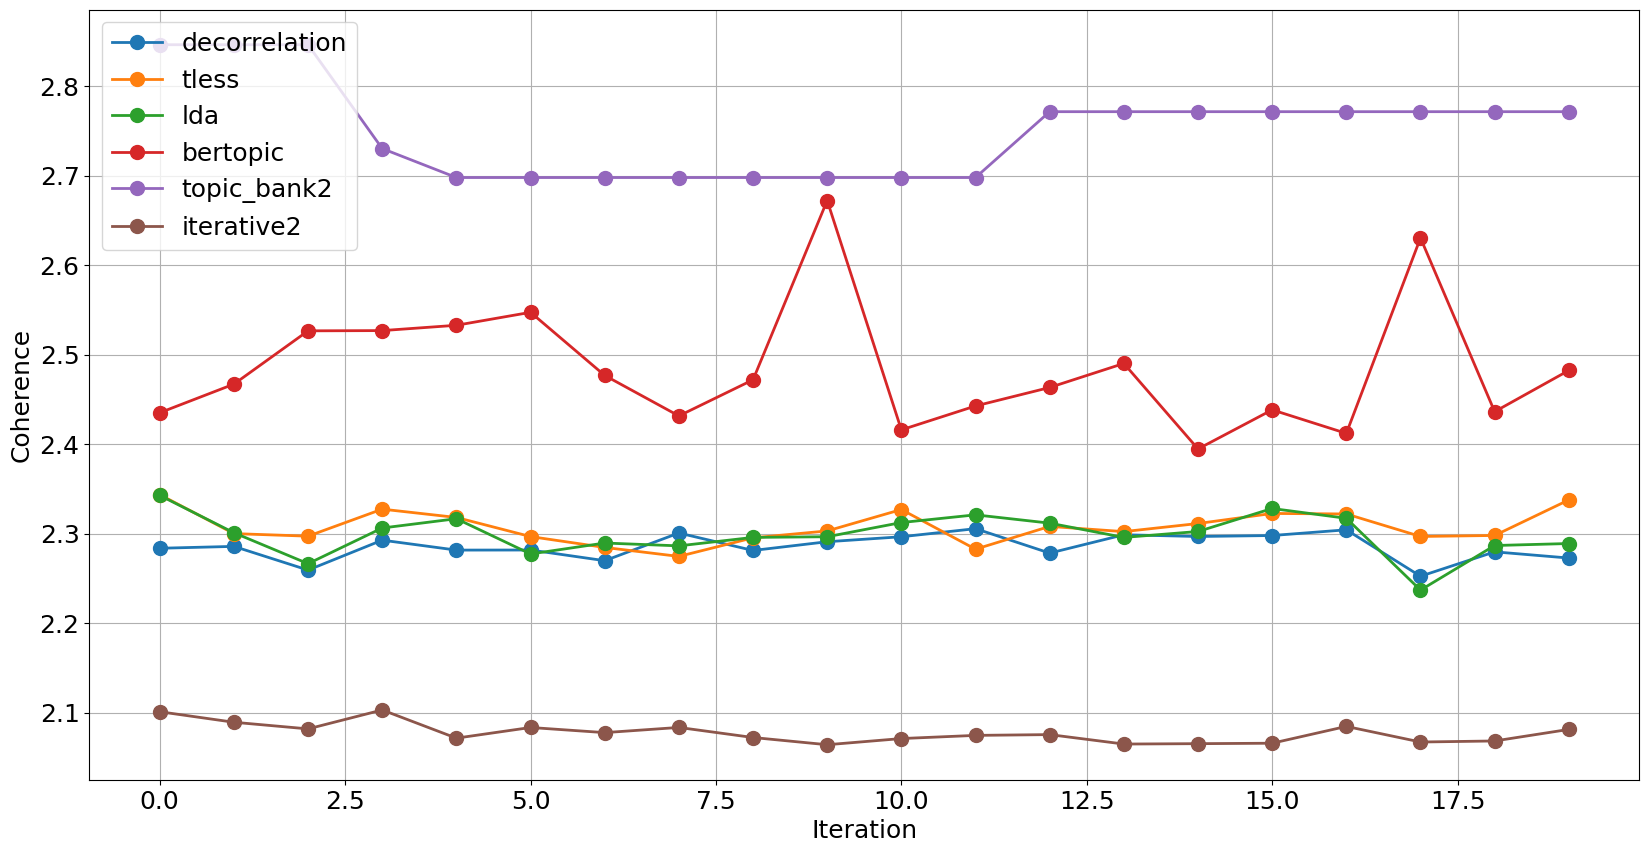

In [304]:
# Bad (iter)

dataset = 'postnauka'
num_topics = 20
getter = get_coherences
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

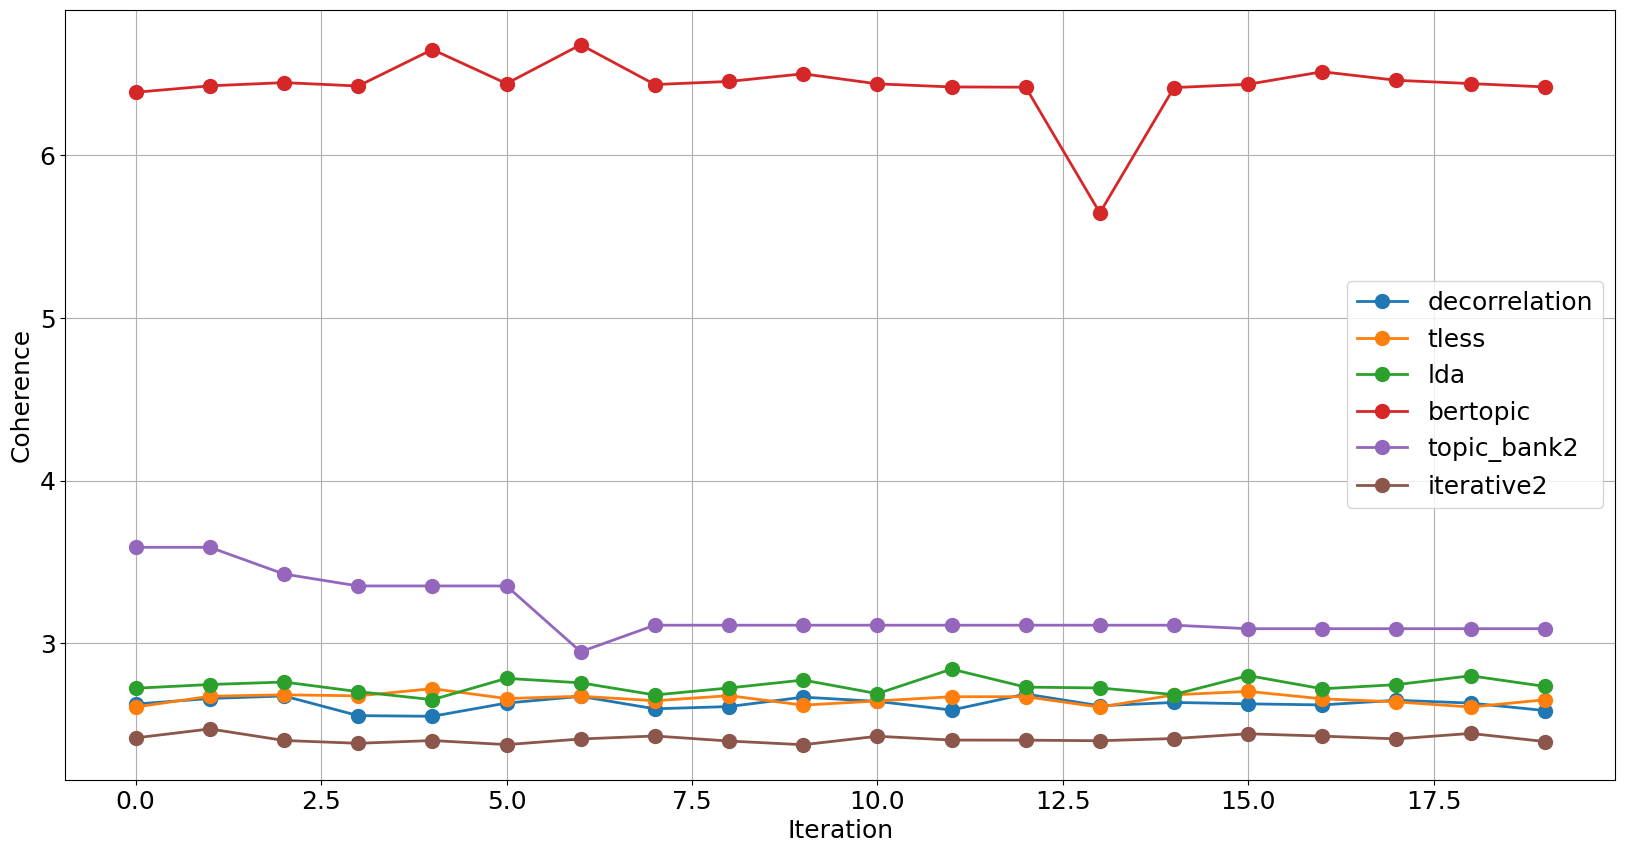

In [305]:
dataset = '20newsgroups'
num_topics = 20
getter = get_coherences
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

In [306]:
DATASETS

['postnauka', '20newsgroups', 'mkb10']

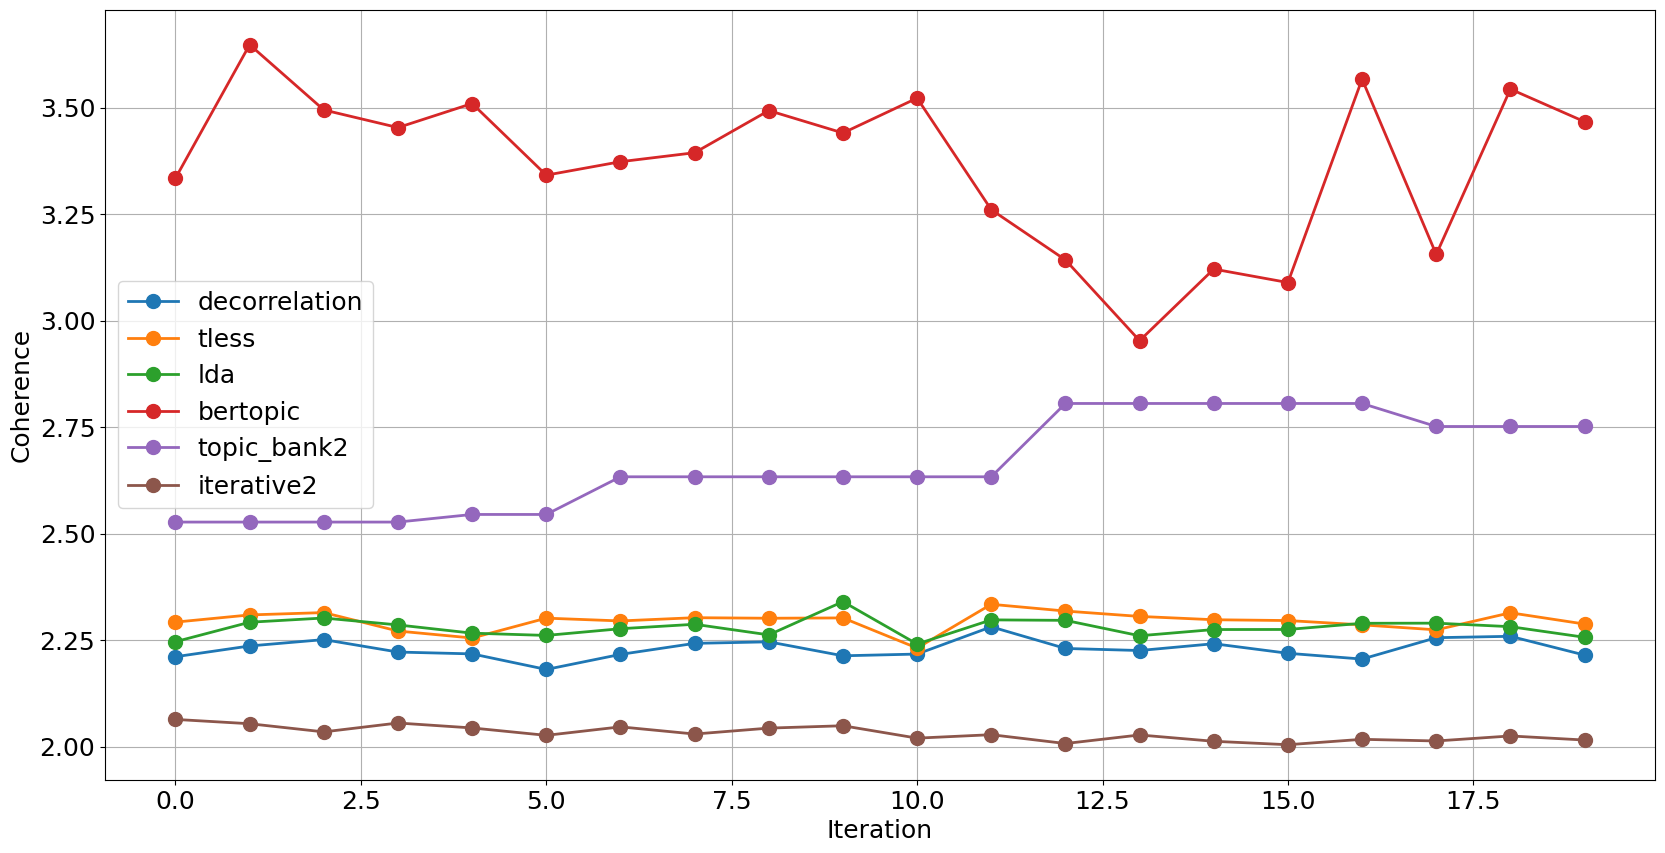

In [307]:
dataset = 'mkb10'
num_topics = 20
getter = get_coherences
ylabel = 'Coherence'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

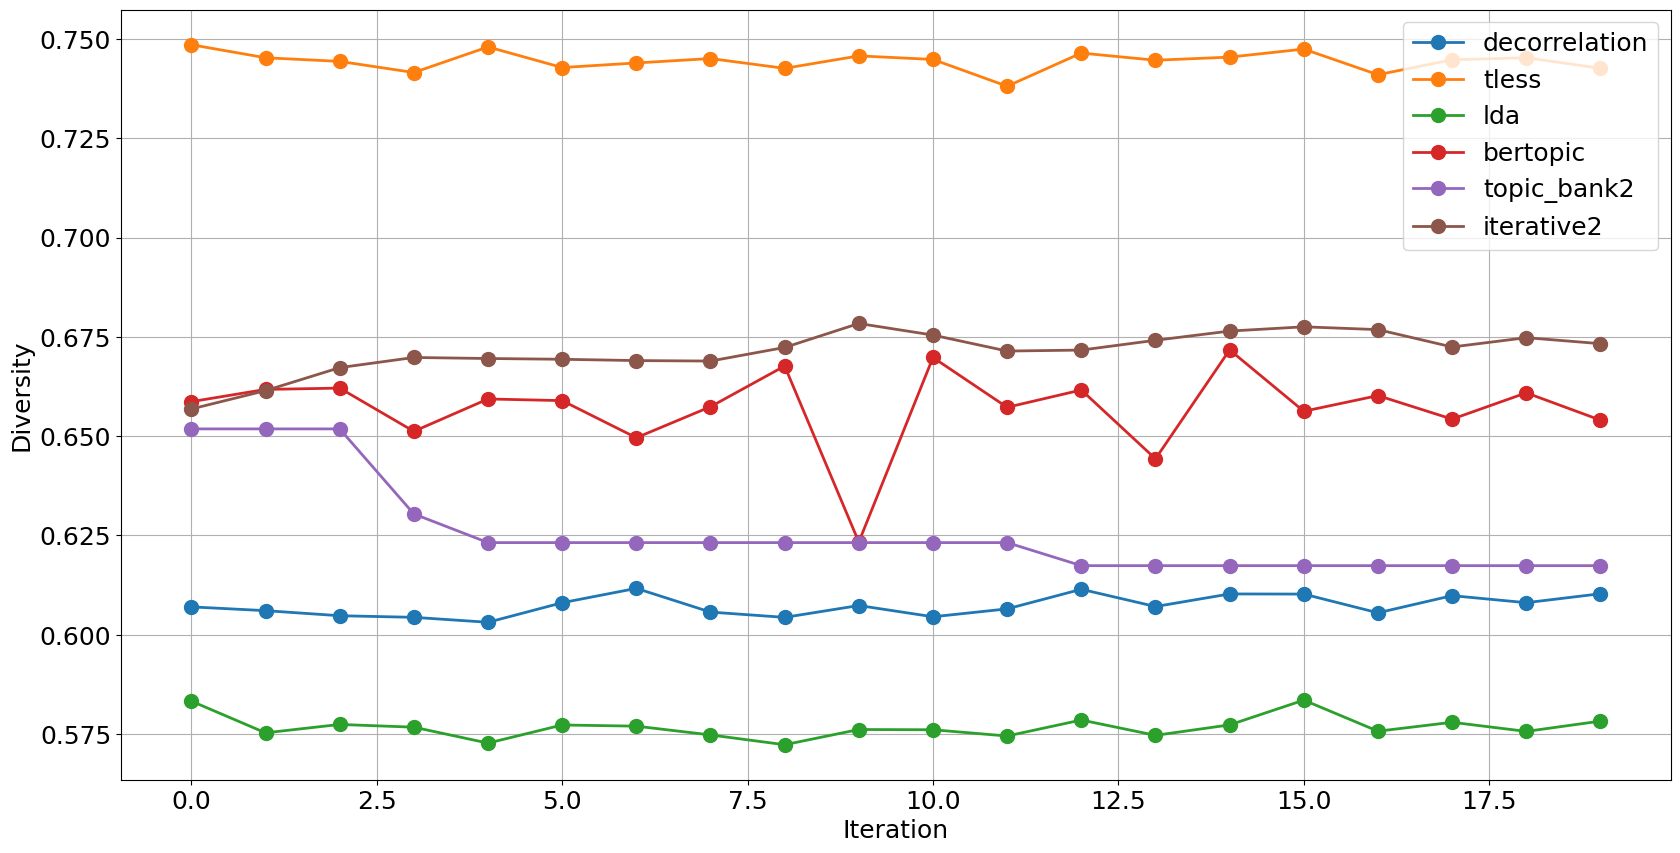

In [308]:
dataset = 'postnauka'
num_topics = 20
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

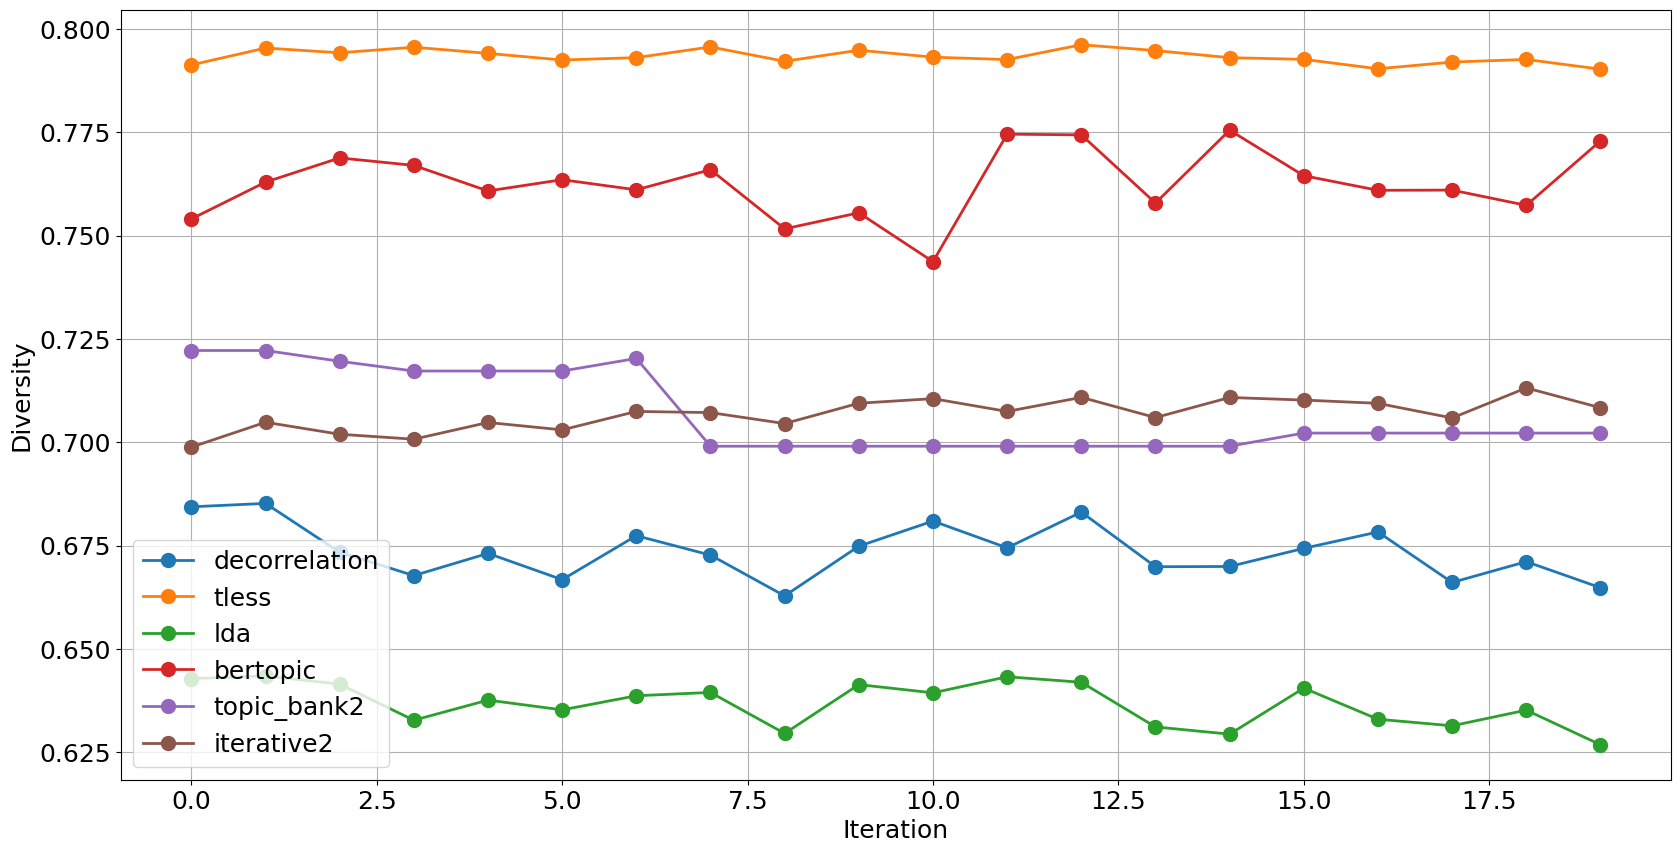

In [309]:
dataset = '20newsgroups'
num_topics = 20
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

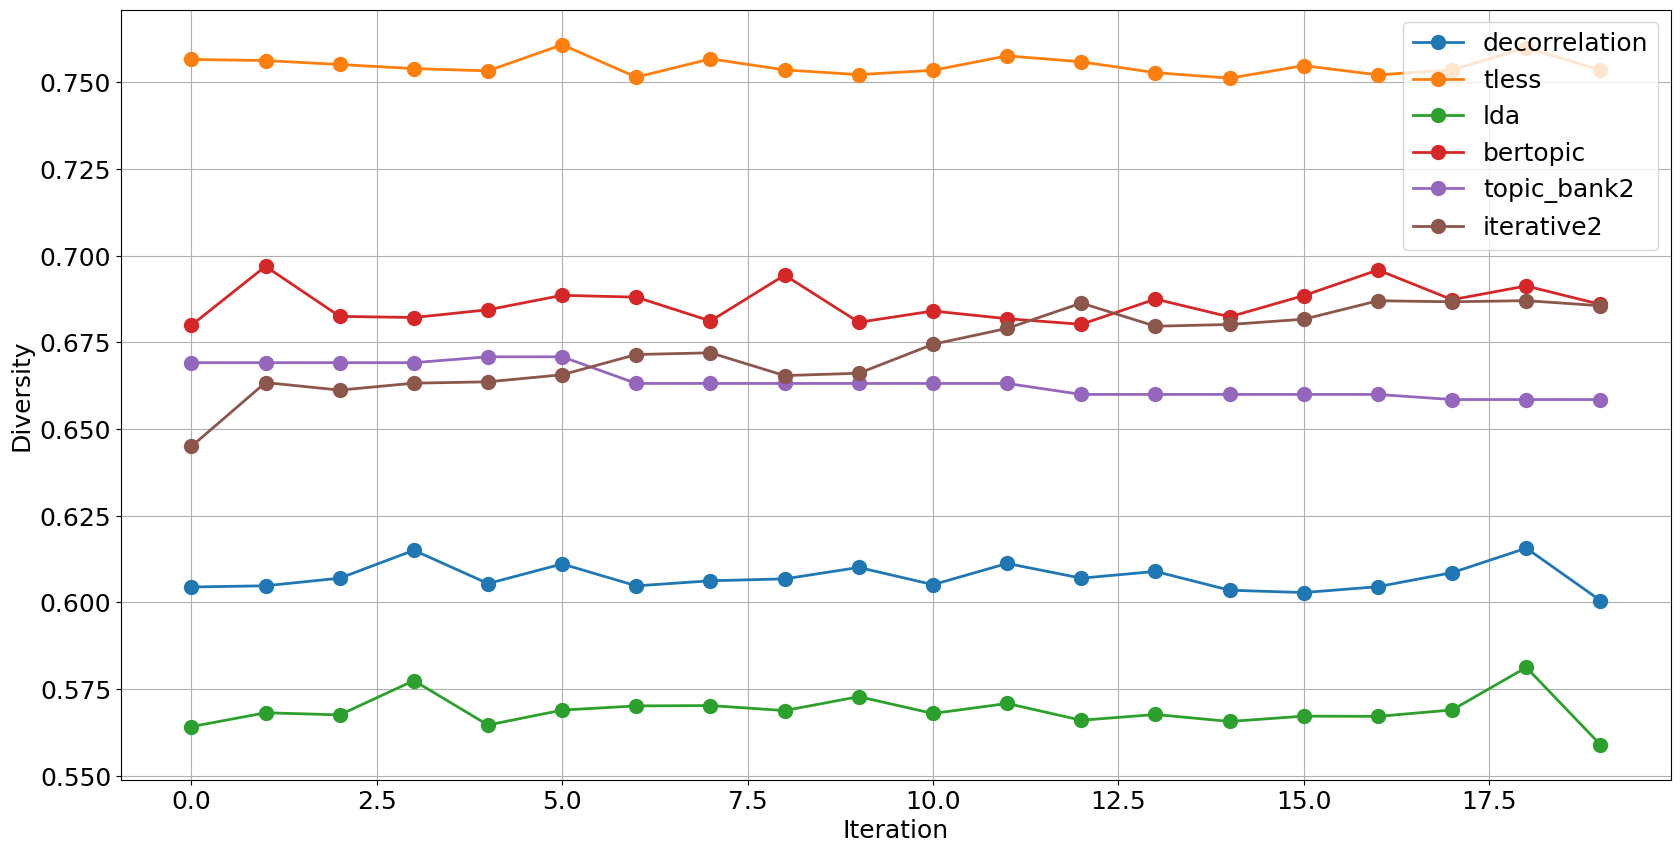

In [310]:
dataset = 'mkb10'
num_topics = 20
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

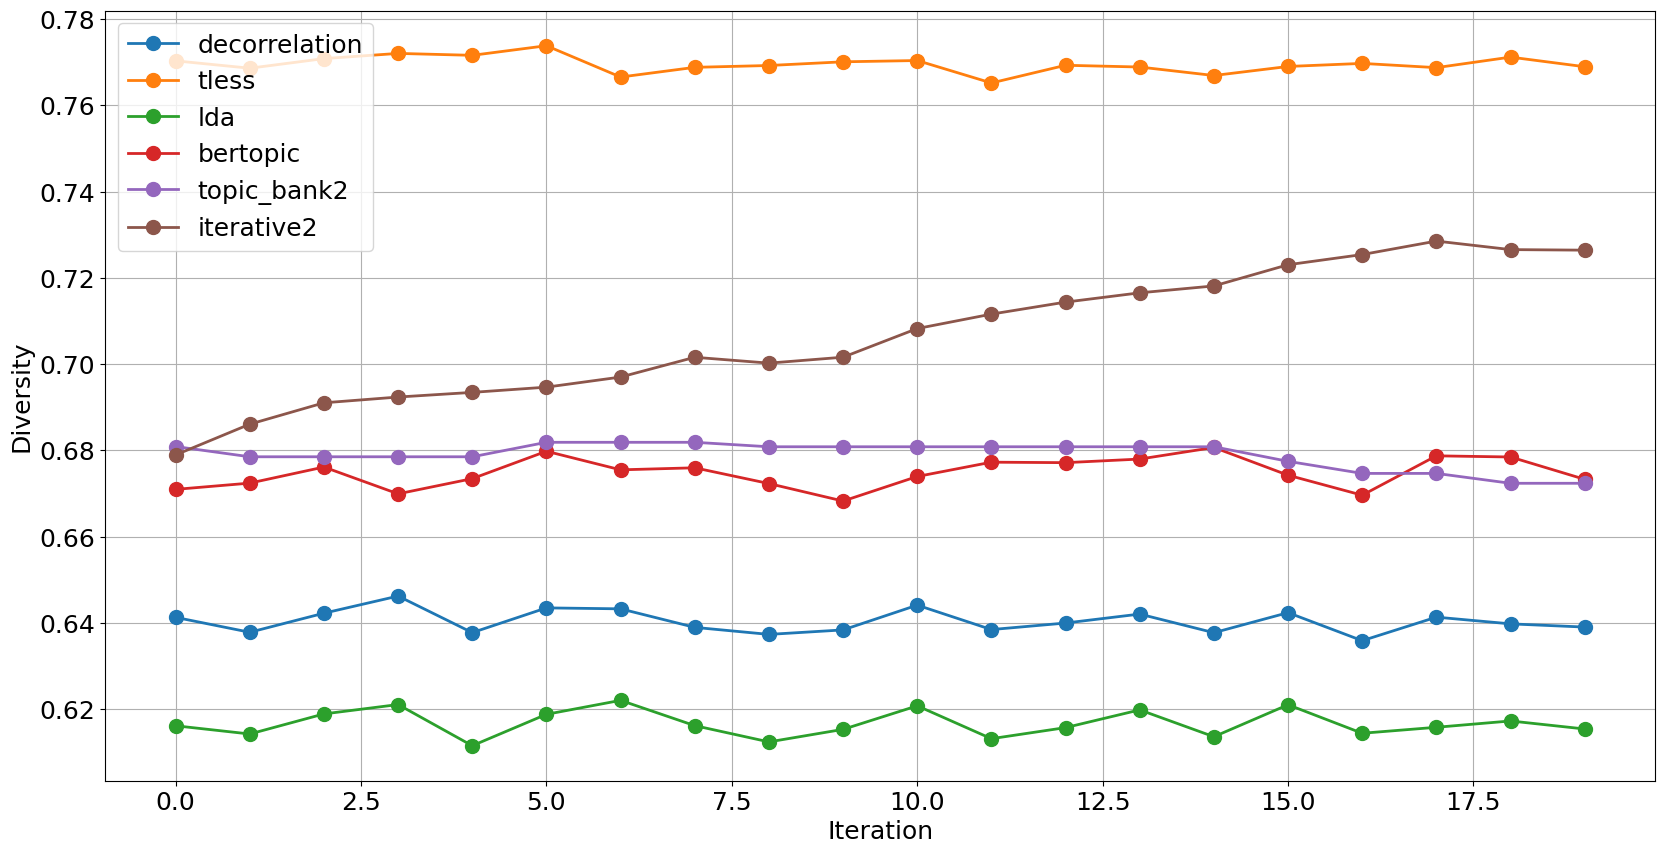

In [311]:
# Good (iter)

dataset = 'postnauka'
num_topics = 50
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

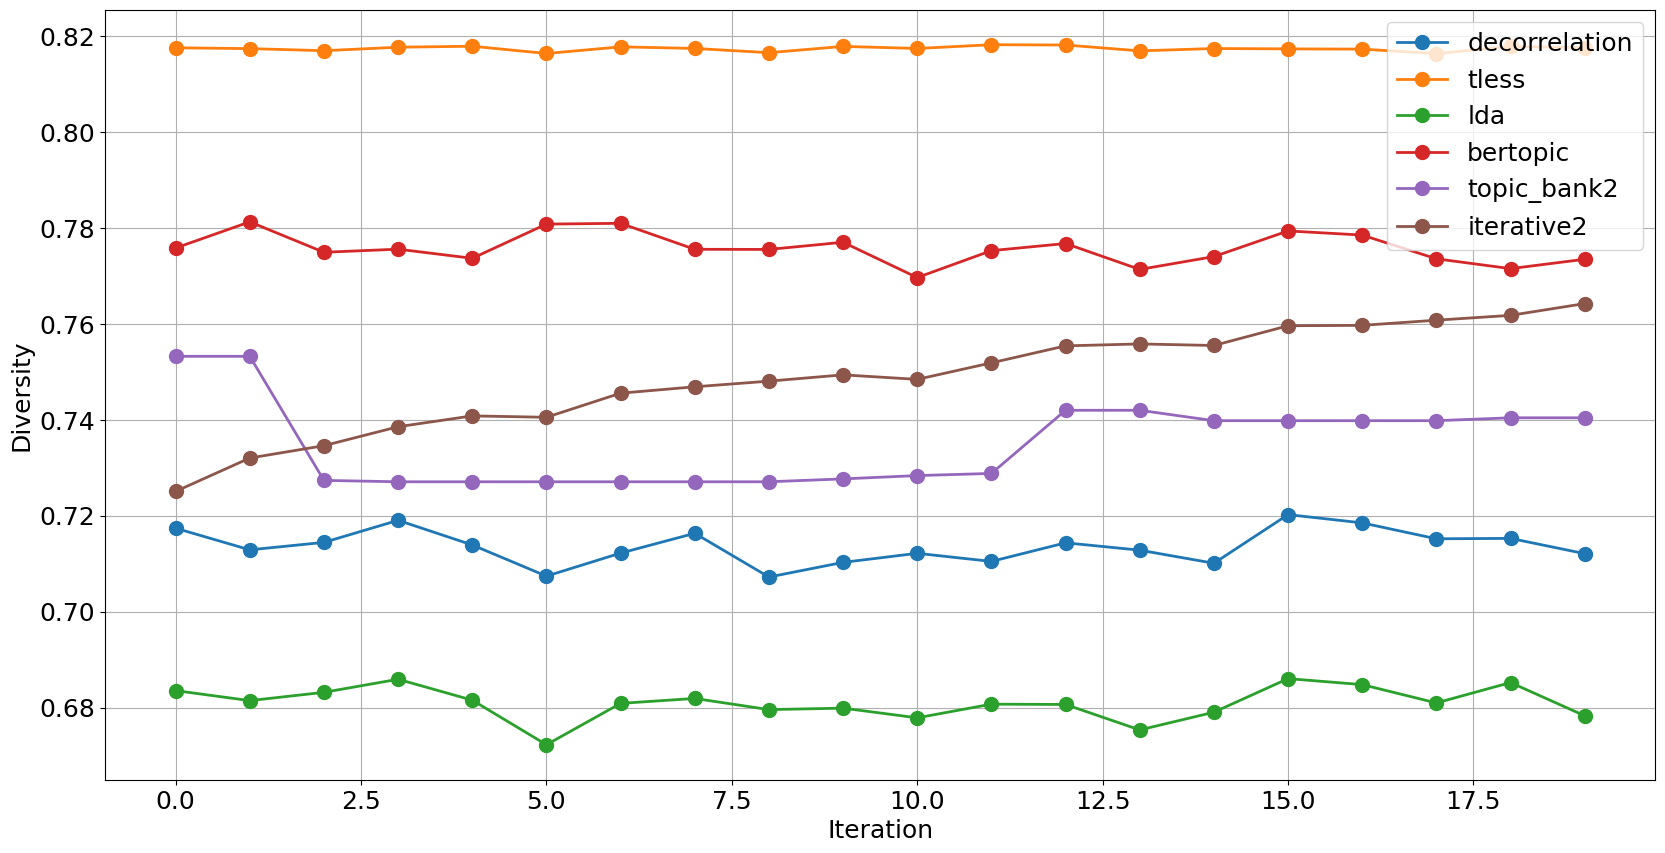

In [312]:
dataset = '20newsgroups'
num_topics = 50
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

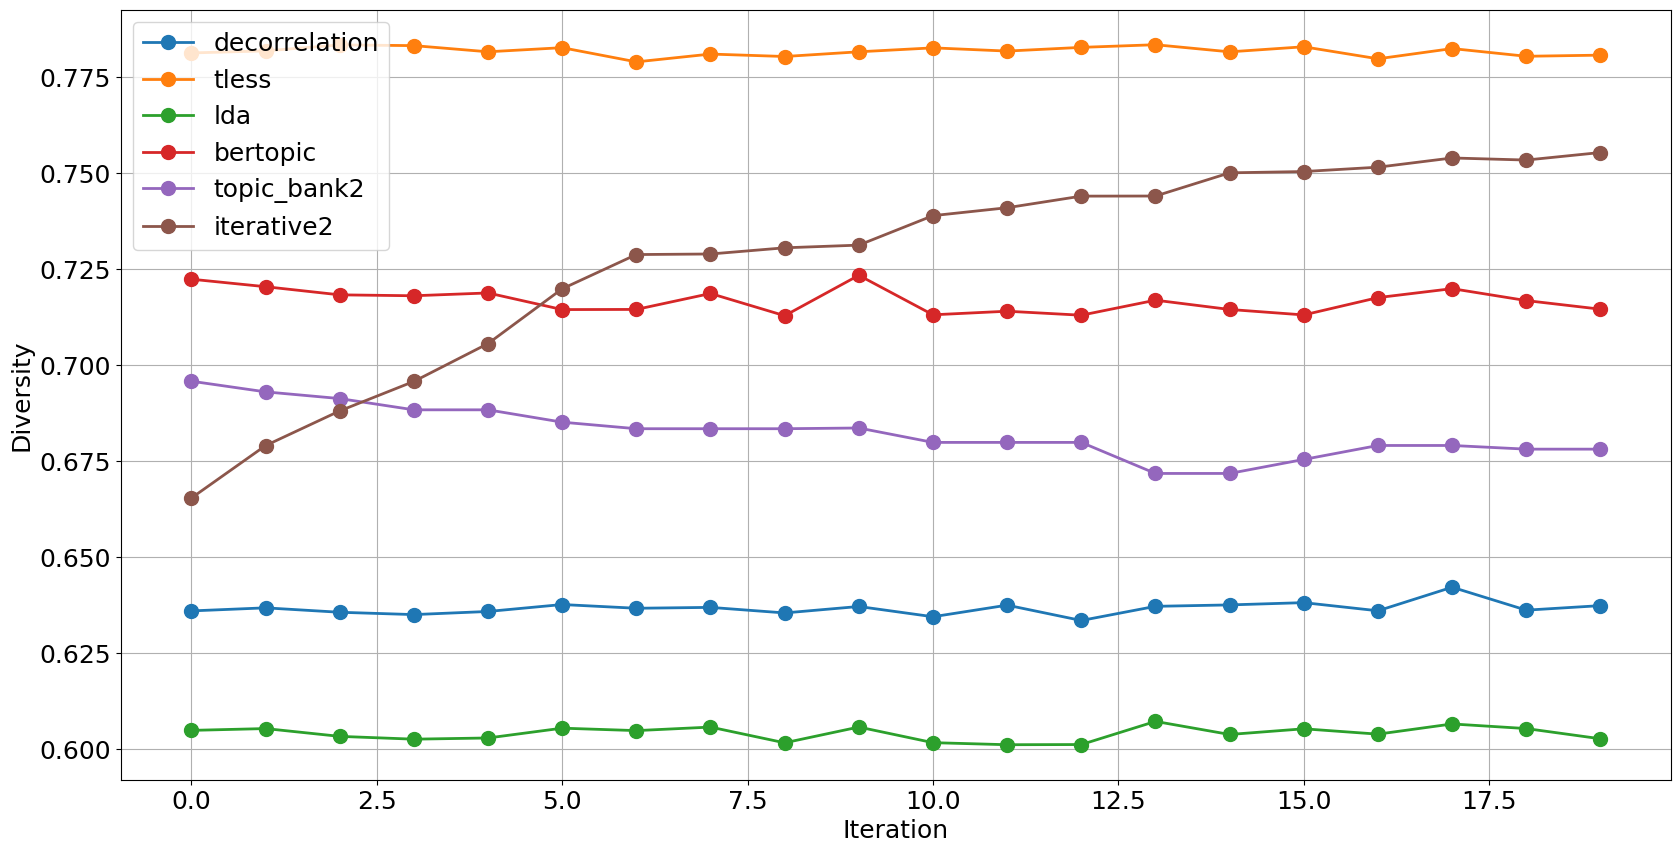

In [313]:
# Good (iter)

dataset = 'mkb10'
num_topics = 50
getter = get_diversities_js
ylabel = 'Diversity'

fig, ax = plt.subplots(figsize=(20, 10))


for model in MODELS_FOR_PLOTS2:
    # if 'topic_bank' in model:
    #     continue

    x, y = getter(num_topics, dataset, model)

    plt.plot(x, y, lw=2, marker='.', ms=20, label=model)

plt.xlabel('Iteration')
plt.ylabel(ylabel)

plt.grid()
plt.legend()

plt.show()

In [69]:
MAX_NUM_ITERS = 20


def plot_one(
        num_topics, dataset, model, ax,
        getter=get_num_good_topics_percents,
        ylabel='Percentage of good topics',
        xlabel='Iteration',
        label=None,
        color=None,
        dx=None
        ):
    x, y = getter(num_topics, dataset, model)

    if label is None:
        label = model

    if 'iterative' in model or 'topic_bank' in model:
        ax.plot(x, y, lw=LINEWIDTH, marker='.', ms=MARKERSIZE, color=color, label=label)
    else:
        assert dx is not None

        x = [xi + dx for xi in x]

        for i, (xi, yi) in enumerate(zip(x, y)):
            if i == 0:
                cur_label = label
            else:
                cur_label = None

            ax.vlines(xi, ymin=0, ymax=yi, lw=LINEWIDTH, color=color, label=cur_label)
            ax.plot([xi], [yi], marker='.', ms=MARKERSIZE, color=color)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    xticks = [xi for xi in range(MAX_NUM_ITERS) if xi % 2 == 0]
    ax.set_xticks(xticks)

    # ax.grid()
    # ax.legend()

In [70]:
MODELS

['plsa',
 'sparse',
 'decorrelation',
 'tless',
 'lda',
 'iterative',
 'iterative2',
 'topic_bank2',
 'bertopic']

In [71]:
# Iterative additive regularization
# itera
# itaru
# itade
# itaddive
# itadive
# itadive
# itarla
# iterla
# itadiz
# itadra
# itaila
# itera
# itadra

# iterative -> iteradive
# additive -> itaddive

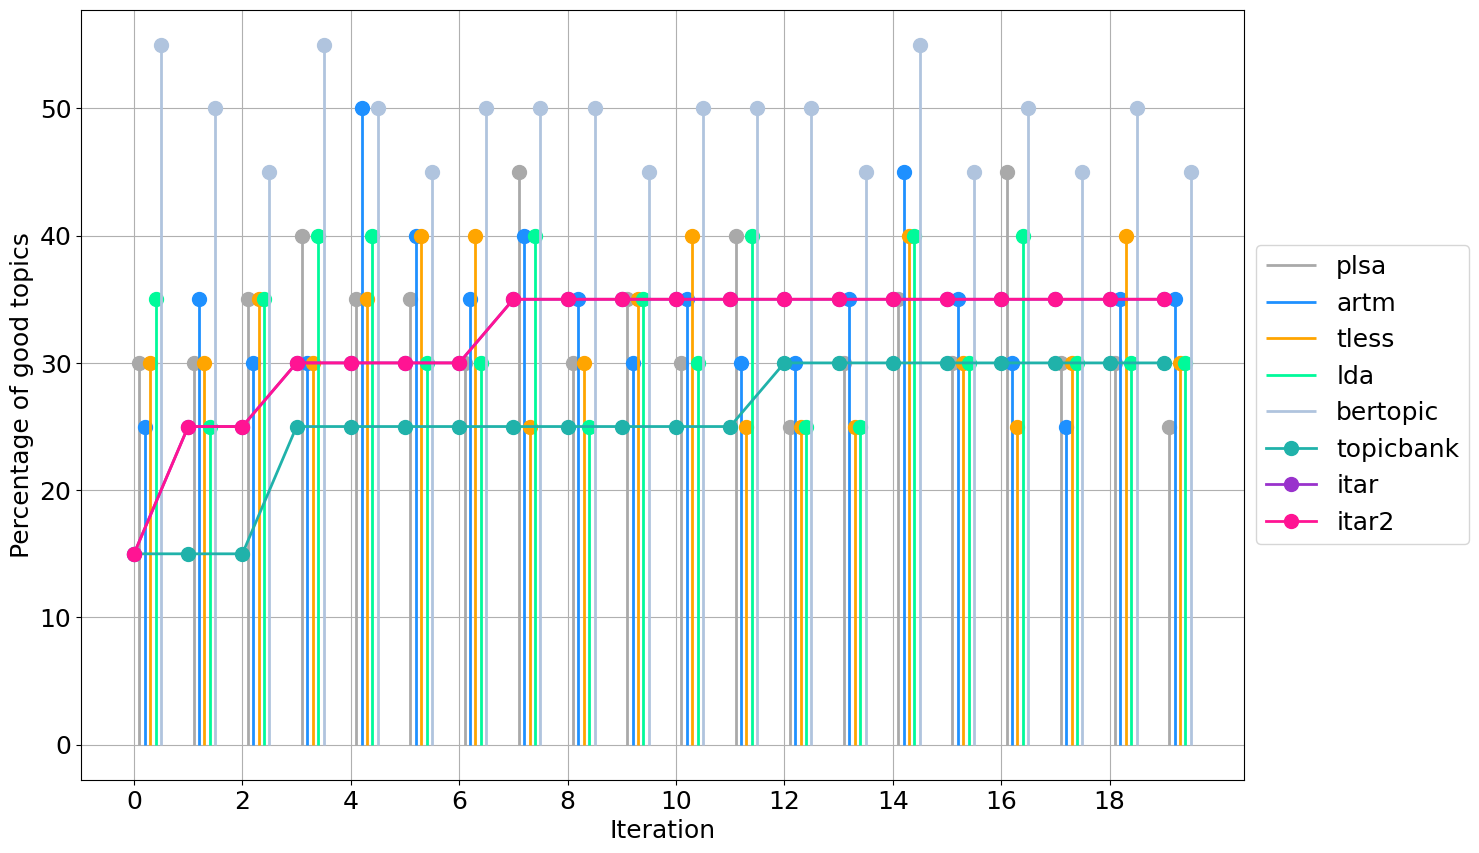

In [72]:
fig, ax = plt.subplots(figsize=(15, 10))

num_topics = 20
dataset = 'postnauka'

plot_one(num_topics, dataset, 'plsa', ax, dx=0.1, color='darkgrey')
plot_one(num_topics, dataset, 'decorrelation', ax, dx=0.2, color='dodgerblue', label='artm')
plot_one(num_topics, dataset, 'tless', ax, color='orange', dx=0.3)
plot_one(num_topics, dataset, 'lda', ax, color='mediumspringgreen', dx=0.4)
plot_one(num_topics, dataset, 'bertopic', ax, dx=0.5, color='lightsteelblue')

plot_one(num_topics, dataset, 'topic_bank2', ax, color='lightseagreen', label='topicbank')

plot_one(num_topics, dataset, 'iterative', ax, color='darkorchid', label='itar')
plot_one(num_topics, dataset, 'iterative2', ax, color='deeppink', label='itar2')

ax.grid()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # https://stackoverflow.com/questions/4700614/how-to-put-the-legend-outside-the-plot

plt.show()

In [85]:
def plot_many(num_topics, dataset, ax):
    plot_one(num_topics, dataset, 'plsa',
             ax, dx=0.1, color='darkgrey')
    plot_one(num_topics, dataset, 'decorrelation',
             ax, dx=0.2, color='dodgerblue', label='decorr')  # label='artm')  # TODO: this is fuck-up
    # plot_one(num_topics, dataset, 'sparse',
    #          ax, dx=0.6, color='lightcoral', label='sparse')  # label='artm')
    plot_one(num_topics, dataset, 'tless',
             ax, dx=0.3, color='orange')
    plot_one(num_topics, dataset, 'lda',
             ax, dx=0.4, color='mediumspringgreen')
    plot_one(num_topics, dataset, 'bertopic', 
             ax, dx=0.5, color='lightsteelblue')

    # plot_one(num_topics, dataset, 'topic_bank',
    #          ax, color='lightseagreen', label='topicbank1')
    plot_one(num_topics, dataset, 'topic_bank2',
             ax, color='lightseagreen', label='topicbank2')
    
    plot_one(num_topics, dataset, 'iterative',
             ax, color='darkorchid', label='itar')  # 'irea')
    plot_one(num_topics, dataset, 'iterative2',
             ax, color='deeppink', label='itar2')

    ax.grid()
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # https://stackoverflow.com/questions/4700614/how-to-put-the-legend-outside-the-plot

In [101]:
# With sparse
def plot_many(num_topics, dataset, ax):
    plot_one(num_topics, dataset, 'plsa',
             ax, dx=0.0, color='darkgrey')
    
    # plot_one(num_topics, dataset, 'decorrelation',  # pink lightcoral aquamarine mintcream mistyrose lightsalmon
    #          ax, dx=0.1, color='plum', label='decorr')  # label='artm')  # TODO: this is fuck-up
    # plot_one(num_topics, dataset, 'sparse',
    #          ax, dx=0.2, color='dodgerblue', label='sparse')  # label='artm')

    plot_one(num_topics, dataset, 'sparse',  # pink lightcoral aquamarine mintcream mistyrose lightsalmon
             ax, dx=0.1, color='plum', label='sparse')  # label='artm')  # TODO: this is fuck-up
    plot_one(num_topics, dataset, 'decorrelation',
             ax, dx=0.2, color='dodgerblue', label='decorr')  # label='artm')

    plot_one(num_topics, dataset, 'tless',
             ax, dx=0.3, color='orange')
    plot_one(num_topics, dataset, 'lda',
             ax, dx=0.4, color='mediumspringgreen')
    plot_one(num_topics, dataset, 'bertopic', 
             ax, dx=0.5, color='lightsteelblue')

    # plot_one(num_topics, dataset, 'topic_bank',
    #          ax, color='lightseagreen', label='topicbank1')
    plot_one(num_topics, dataset, 'topic_bank2',
             ax, color='lightseagreen', label='topicbank2')
    
    plot_one(num_topics, dataset, 'iterative',
             ax, color='darkorchid', label='itar')  # 'irea')
    plot_one(num_topics, dataset, 'iterative2',
             ax, color='deeppink', label='itar2')

    ax.grid()
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # https://stackoverflow.com/questions/4700614/how-to-put-the-legend-outside-the-plot

In [74]:
FIGSIZE = (15, 10)

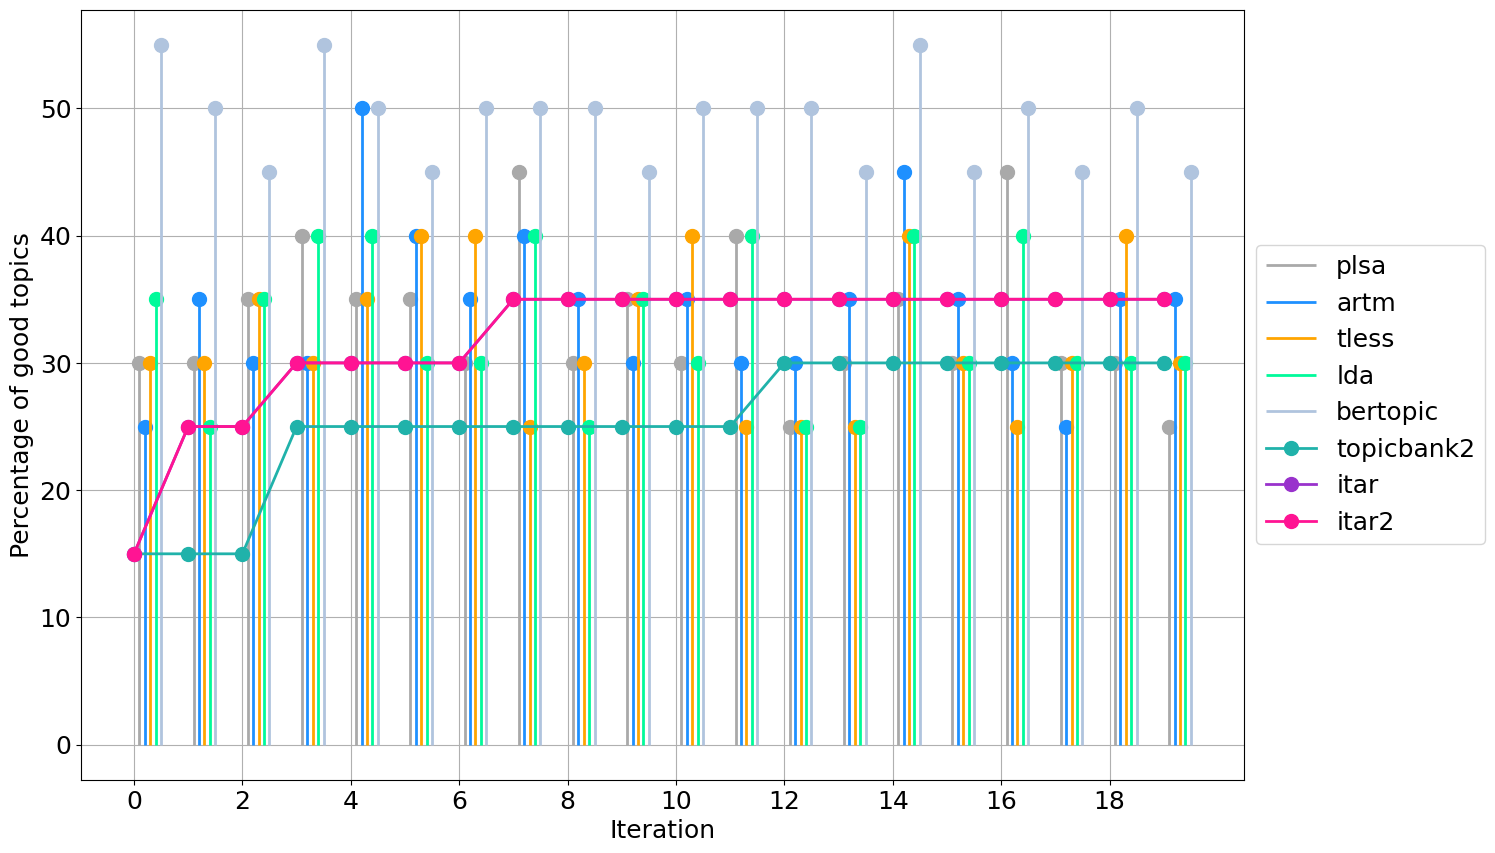

In [76]:
# Not so good (iter)

fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 20
dataset = 'postnauka'

plot_many(num_topics, dataset, ax)

plt.show()

In [322]:
get_nums_good_topics(20, 'postnauka', 'topic_bank2')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6])

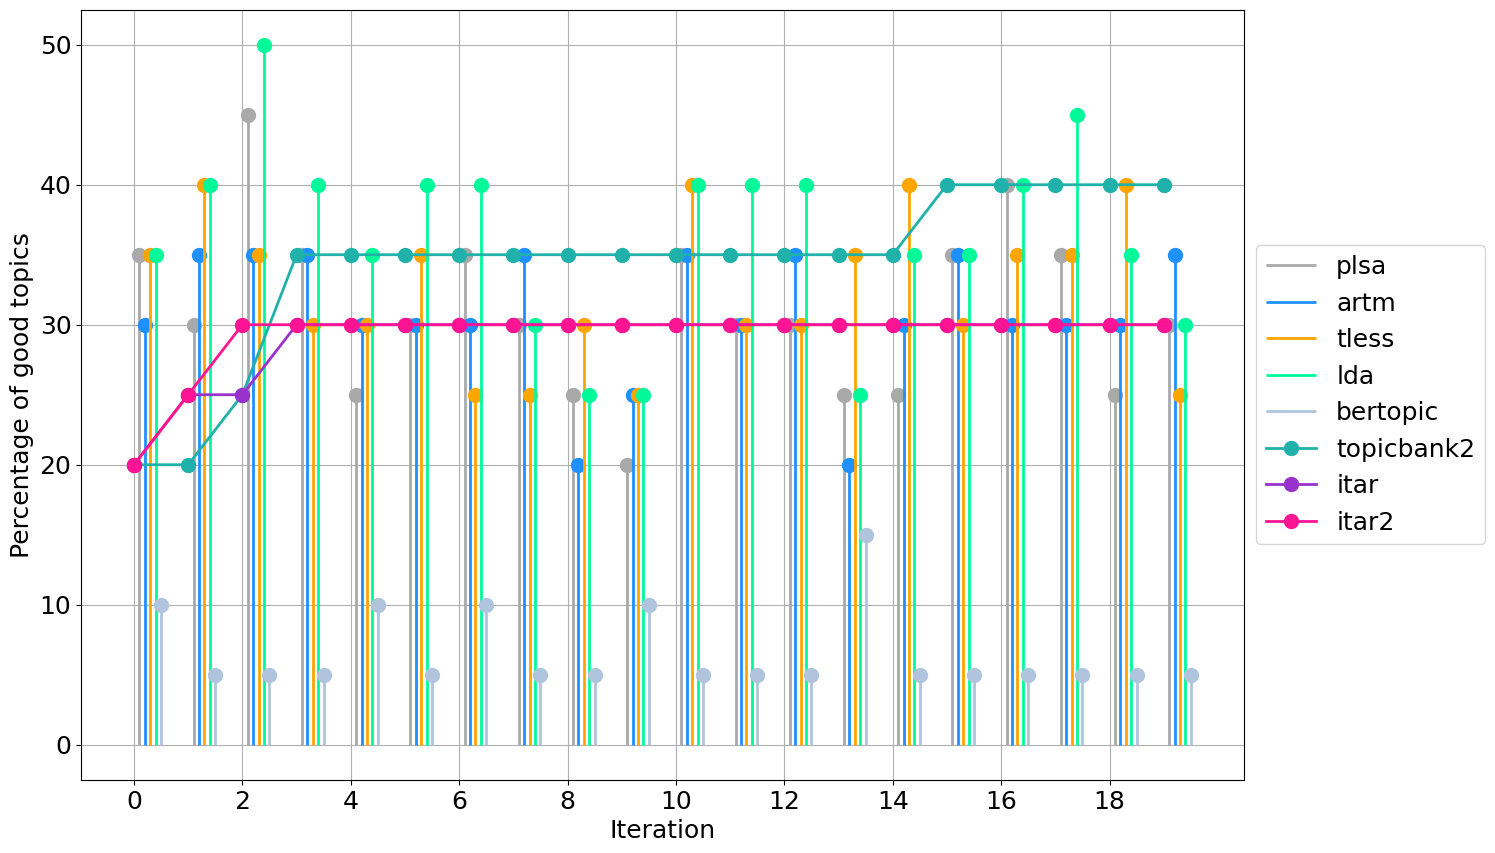

In [324]:
# Not so good (iter)

fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 20
dataset = '20newsgroups'

plot_many(num_topics, dataset, ax)

plt.show()

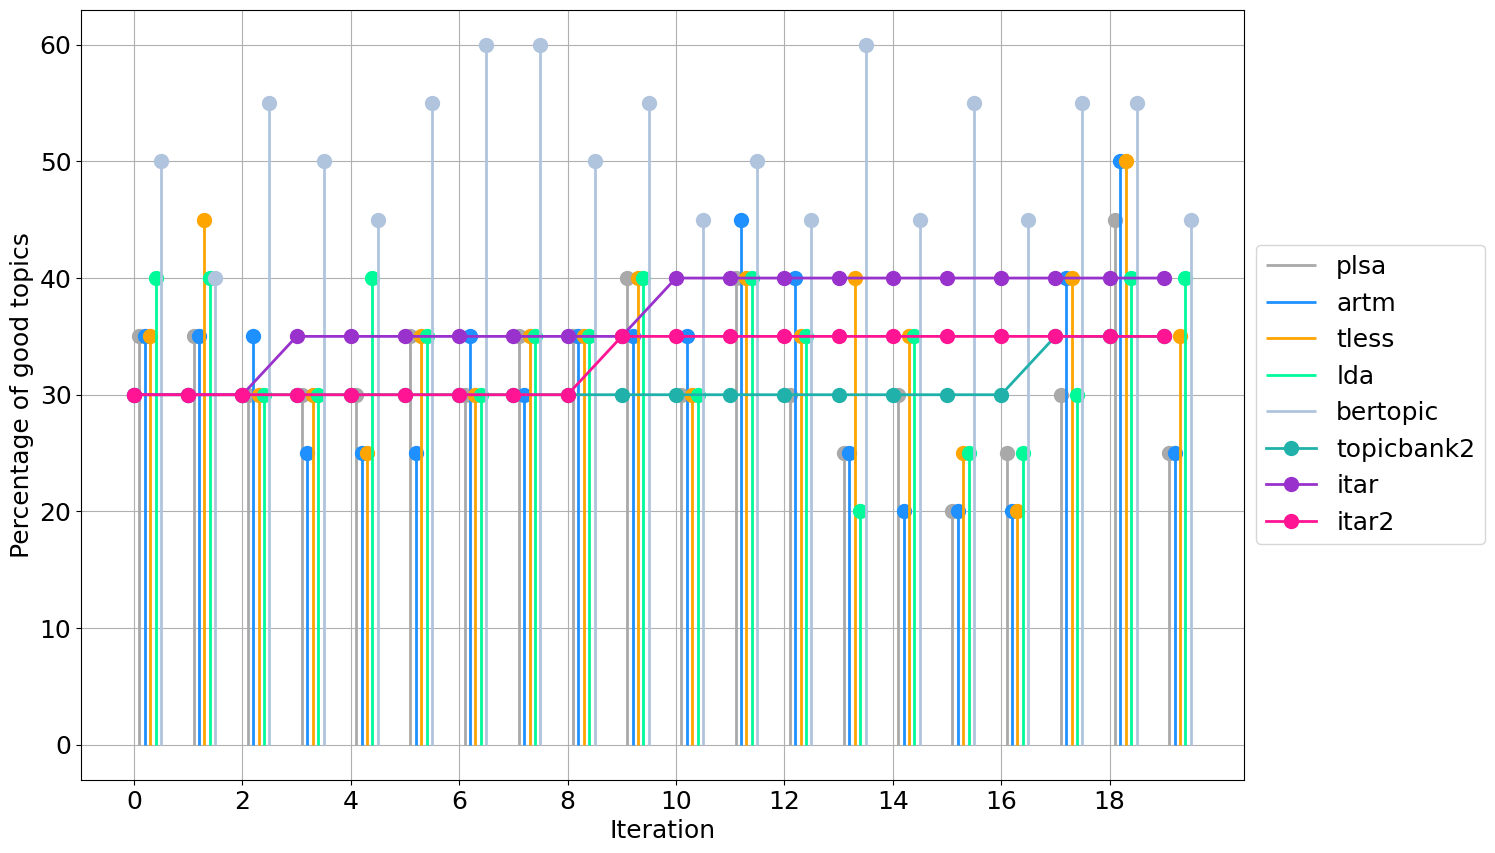

In [325]:
fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 20
dataset = 'mkb10'

plot_many(num_topics, dataset, ax)

plt.show()

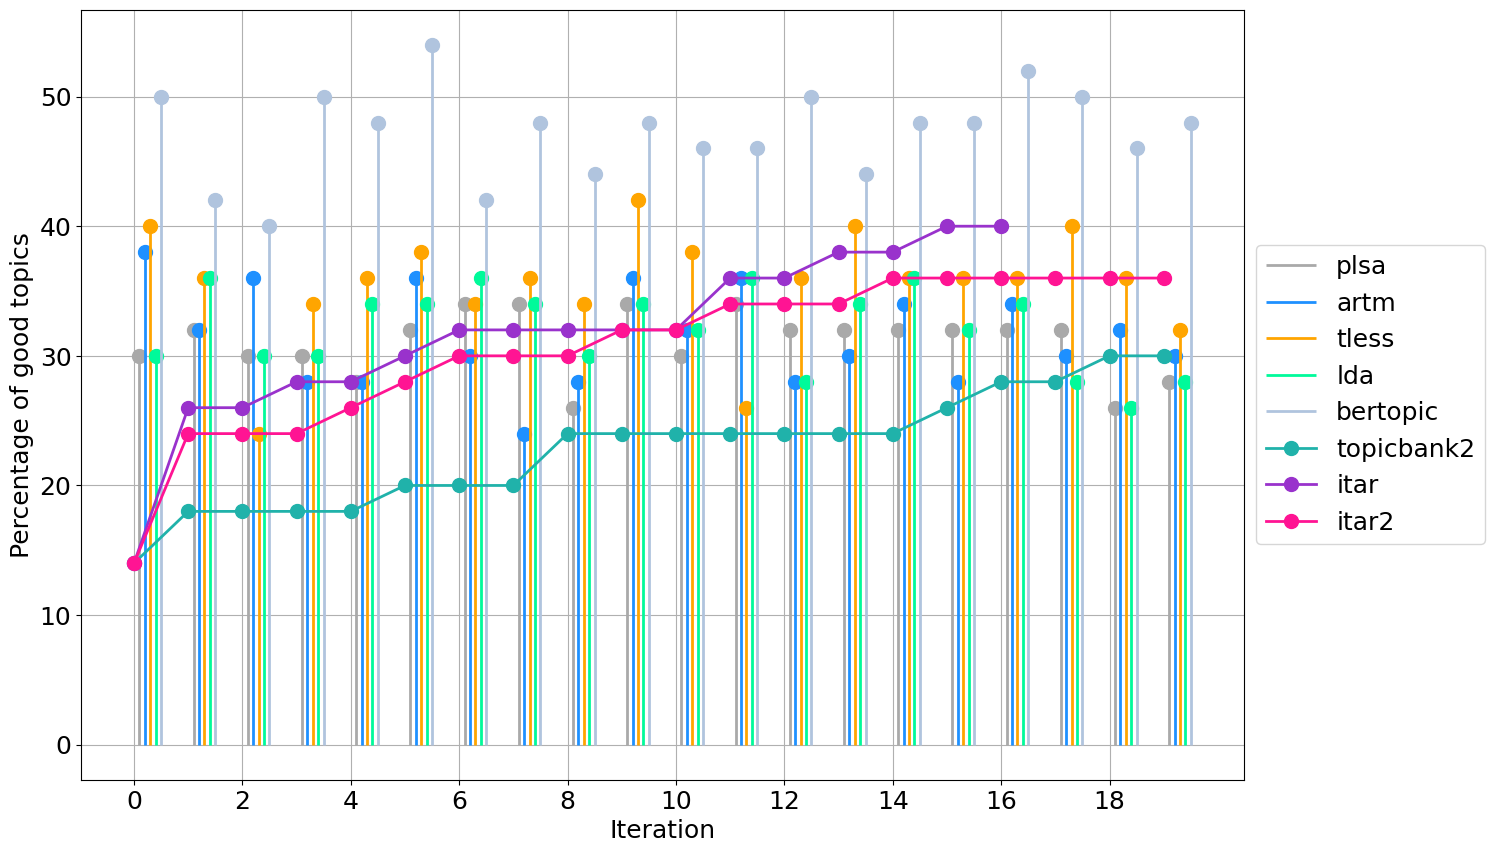

In [326]:
# Not so good, but (iter)

fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = 'postnauka'

plot_many(num_topics, dataset, ax)

plt.show()

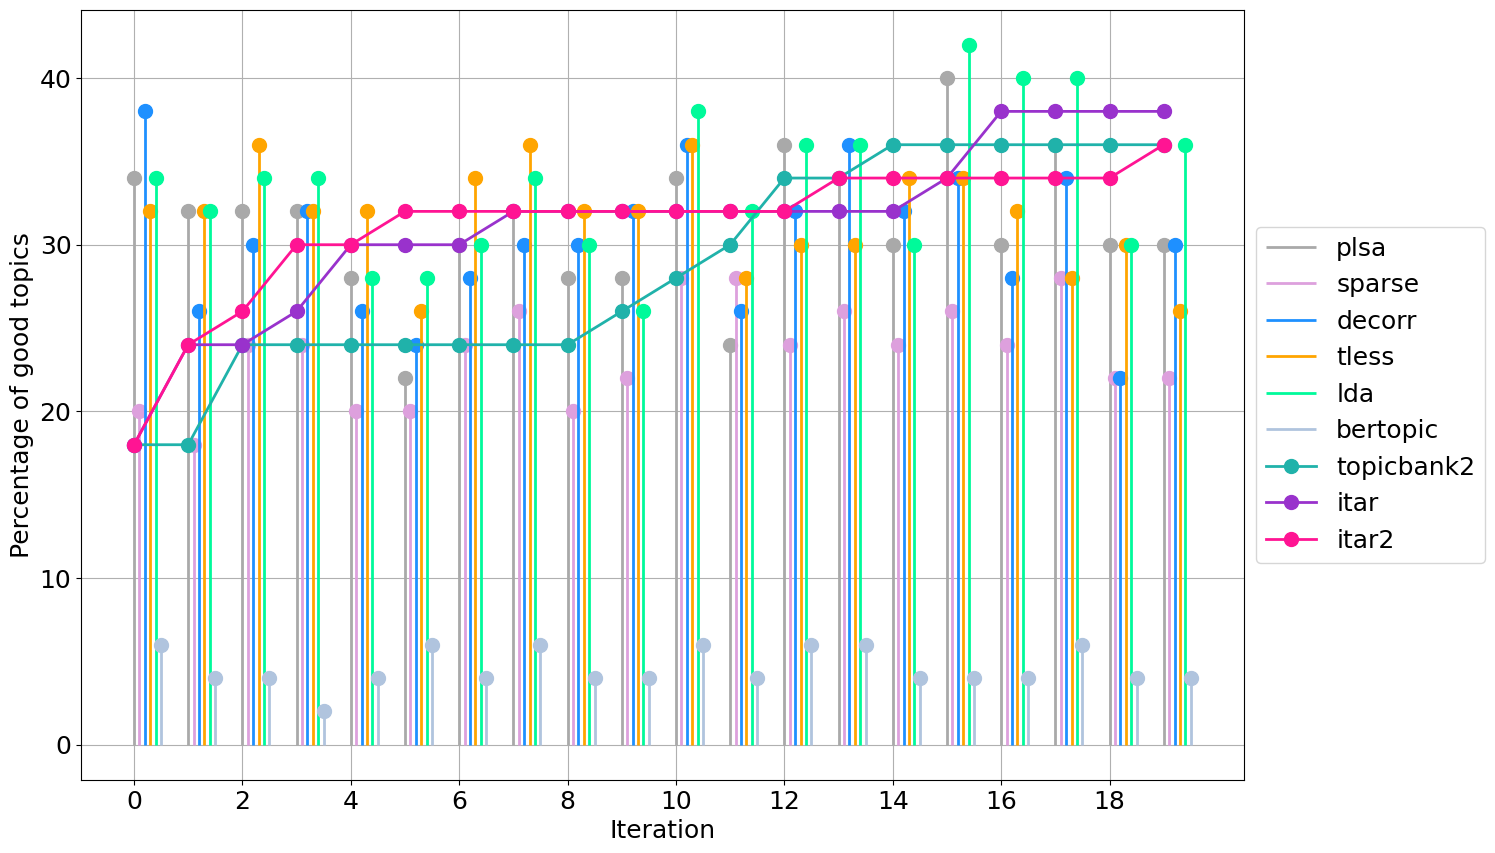

In [102]:
# Good (iter)

fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = '20newsgroups'

plot_many(num_topics, dataset, ax)

plt.savefig('20newsgroups-it-t50.svg', bbox_inches='tight', pad_inches=0)

plt.show()

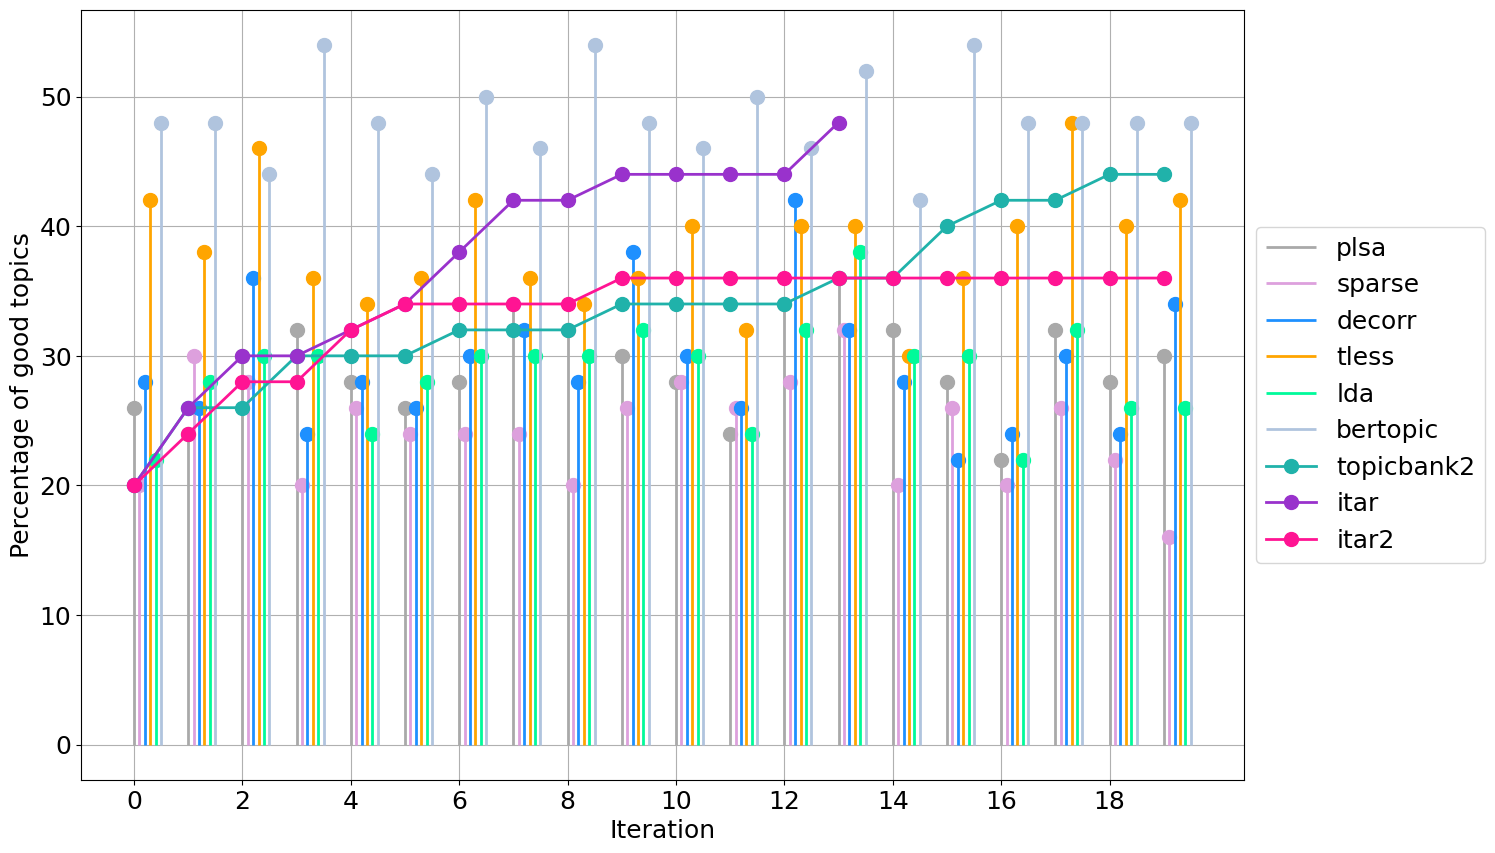

In [103]:
# Not so good (iter)

fig, ax = plt.subplots(figsize=FIGSIZE)

num_topics = 50
dataset = 'mkb10'

plot_many(num_topics, dataset, ax)

plt.savefig('mkb10-it-t50.svg', bbox_inches='tight', pad_inches=0)

plt.show()

In [106]:
def get_nums_good_topics_toptok(num_topics, dataset, model):
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    good_coherence_threshold = DATASET_GOOD_COHERENCE_THRESHOLDS_TOPTOK[num_topics][dataset]
    good_coherence_threshold_intra = DATASET_GOOD_COHERENCE_THRESHOLDS[num_topics][dataset]

    iters = []
    nums_good_topics = []
    nums_good_topics_intra = []
    nums_good_topics_in_good_intra = []
    nums_good_topics_not_in_good_intra = []

    for i, iter in enumerate(model_iters):
        cur_num_good_topics = sum([
            1 if c >= good_coherence_threshold else 0
            for _, c in iter['topic_coherences'].items()
        ])

        if 'iterative' in model:
            cur_num_good_topics_intra = len(iter['good_topic_indices'])
            cur_num_good_topics_in_good_intra = sum([
                1 if c >= good_coherence_threshold and int(j) in iter['good_topic_indices'] else 0
                for (_, c), (j, c_i) in zip(iter['topic_coherences'].items(),
                                            iter['topic_coherences_toplen_ptw'].items())
            ])
        elif 'topic_bank' in model:
            cur_num_good_topics_intra = len(iter['topic_coherences'])
            cur_num_good_topics_in_good_intra = sum([
                1 if c >= good_coherence_threshold else 0
                for _, c in iter['topic_coherences'].items()
            ])
        else:
            cur_num_good_topics_intra = sum([
                1 if c_i >= good_coherence_threshold_intra else 0
                for (_, c), (_, c_i) in zip(iter['topic_coherences'].items(),
                                            iter['topic_coherences_toplen_ptw'].items())
            ])
            cur_num_good_topics_in_good_intra = sum([
                1 if c >= good_coherence_threshold and c_i >= good_coherence_threshold_intra else 0
                for (_, c), (_, c_i) in zip(iter['topic_coherences'].items(),
                                            iter['topic_coherences_toplen_ptw'].items())
            ])

        if 'iterative' in model:
            cur_num_good_topics_not_in_good_intra = sum([
                1 if c >= good_coherence_threshold and int(j) not in iter['good_topic_indices'] else 0
                for (_, c), (j, c_i) in zip(iter['topic_coherences'].items(),
                                            iter['topic_coherences_toplen_ptw'].items())
            ])
        elif 'topic_bank' in model:
            cur_num_good_topics_not_in_good_intra = 0
        else:
            cur_num_good_topics_not_in_good_intra = sum([
                1 if c >= good_coherence_threshold and c_i < good_coherence_threshold_intra else 0
                for (_, c), (_, c_i) in zip(iter['topic_coherences'].items(),
                                            iter['topic_coherences_toplen_ptw'].items())
            ])

        assert cur_num_good_topics_in_good_intra + cur_num_good_topics_not_in_good_intra == cur_num_good_topics

        # if 'iterative' in model:
        #     assert cur_num_good_topics == iter['num_topics']['good']

        nums_good_topics.append(cur_num_good_topics)
        nums_good_topics_intra.append(cur_num_good_topics_intra)
        nums_good_topics_in_good_intra.append(cur_num_good_topics_in_good_intra)
        nums_good_topics_not_in_good_intra.append(cur_num_good_topics_not_in_good_intra)
        
        iters.append(i)

    return (
        iters,
        nums_good_topics, nums_good_topics_intra,
        nums_good_topics_in_good_intra, nums_good_topics_not_in_good_intra,
    )


def get_num_good_topics_percents_toptok(num_topics, dataset, model):
    (iters,
     nums_good_topics, nums_good_topics_intra,
     nums_good_topics_in_good_intra, nums_good_topics_not_in_good_intra) = get_nums_good_topics_toptok(num_topics, dataset, model)

    return iters, [
        n / num_topics * 100 for n in nums_good_topics
    ], [
        # n / num_topics * 100 for n in nums_good_topics_in_good_intra
        n / n_i * 100 for n, n_i in zip(nums_good_topics_in_good_intra, nums_good_topics_intra)
    ], [
        # n / num_topics * 100 for n in nums_good_topics_not_in_good_intra
        n / (num_topics - n_i) * 100 for n, n_i in zip(nums_good_topics_not_in_good_intra, nums_good_topics_intra)
    ]

In [107]:
MAX_NUM_ITERS = 20


def plot_corr_one(
        num_topics, dataset, model, ax,
        getter=get_num_good_topics_percents,
        ylabel='Percentage of good topics',
        xlabel='Iteration',
        label=None,
        color=None,
        dx=None
        ):
    x, y = getter(num_topics, dataset, model)

    if label is None:
        label = model

    if 'iterative' in model or 'topic_bank' in model:
        ax.plot(x, y, lw=LINEWIDTH, marker='.', ms=MARKERSIZE, color=color, label=label)
    else:
        assert dx is not None

        x = [xi + dx for xi in x]

        for i, (xi, yi) in enumerate(zip(x, y)):
            if i == 0:
                cur_label = label
            else:
                cur_label = None

            ax.vlines(xi, ymin=0, ymax=yi, lw=LINEWIDTH, color=color, label=cur_label)
            ax.plot([xi], [yi], marker='.', ms=MARKERSIZE, color=color)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    xticks = [xi for xi in range(MAX_NUM_ITERS) if xi % 2 == 0]
    ax.set_xticks(xticks)

    # ax.grid()
    # ax.legend()

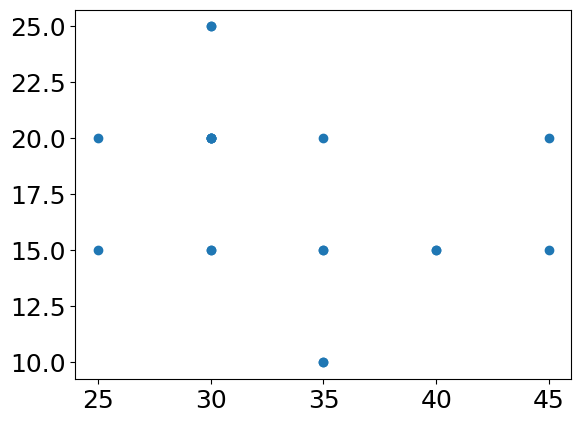

In [108]:
num_topics = 20
dataset = 'postnauka'
model = 'plsa'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, _, _ = get_num_good_topics_percents_toptok(num_topics, dataset, model)

plt.scatter(y, y1)

[15.0, 25.0, 25.0, 30.0, 30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0]
[30.0, 20.0, 25.0, 25.0, 30.0, 40.0, 30.0, 30.0, 45.0, 30.0, 40.0, 45.0, 40.0, 50.0, 50.0, 60.0, 55.00000000000001, 45.0, 50.0, 55.00000000000001]


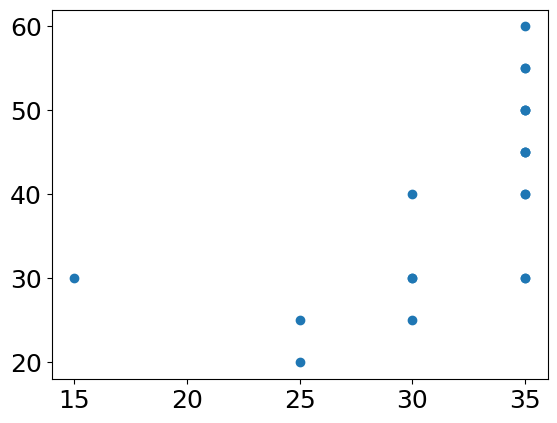

In [533]:
num_topics = 20
dataset = 'postnauka'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[15.0, 25.0, 25.0, 30.0, 30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0]
[30.0, 20.0, 25.0, 25.0, 20.0, 35.0, 25.0, 25.0, 35.0, 25.0, 25.0, 45.0, 35.0, 45.0, 35.0, 40.0, 55.00000000000001, 30.0, 45.0, 50.0]


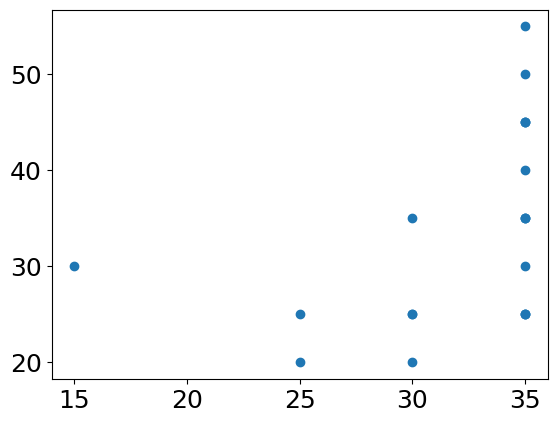

In [534]:
num_topics = 20
dataset = 'postnauka'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[15.0, 15.0, 15.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0]
[10.0, 10.0, 10.0, 15.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]


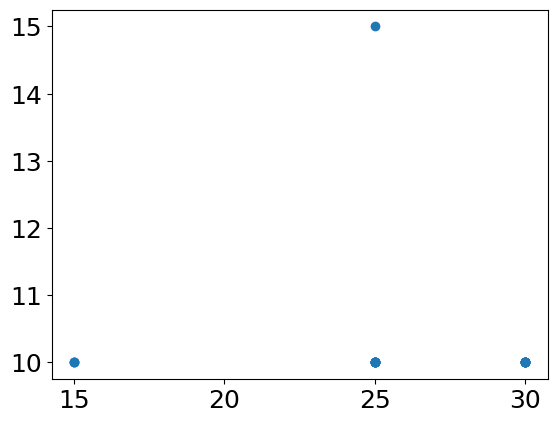

In [535]:
num_topics = 20
dataset = 'postnauka'
model = 'topic_bank2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[20.0, 25.0, 25.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0]
[30.0, 25.0, 25.0, 45.0, 35.0, 45.0, 45.0, 45.0, 60.0, 60.0, 50.0, 50.0, 40.0, 40.0, 50.0, 45.0, 45.0, 55.00000000000001, 45.0, 40.0]


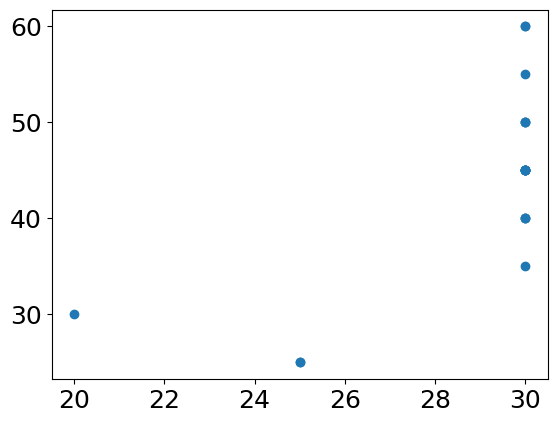

In [517]:
num_topics = 20
dataset = '20newsgroups'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

In [389]:
print(y2)
print(y3)

[10.0, 10.0, 5.0, 10.0, 5.0, 10.0, 5.0, 10.0, 5.0, 5.0, 5.0, 10.0, 5.0, 10.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]
[20.0, 15.0, 20.0, 35.0, 30.0, 35.0, 40.0, 35.0, 55.00000000000001, 55.00000000000001, 45.0, 40.0, 35.0, 30.0, 45.0, 40.0, 40.0, 50.0, 40.0, 35.0]


[30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0]
[35.0, 50.0, 60.0, 40.0, 55.00000000000001, 55.00000000000001, 55.00000000000001, 50.0, 65.0, 65.0, 55.00000000000001, 65.0, 75.0, 55.00000000000001, 70.0, 70.0, 60.0, 60.0, 60.0, 60.0]


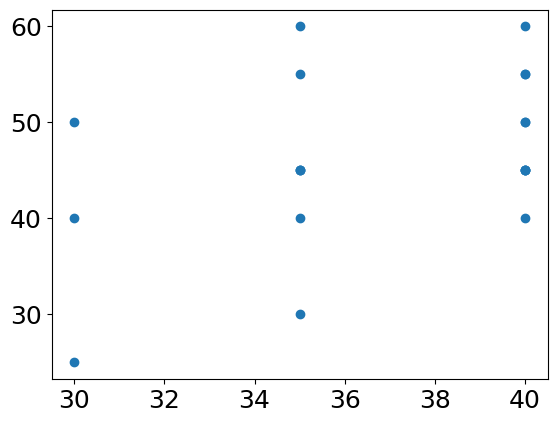

In [394]:
num_topics = 20
dataset = 'mkb10'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[14.000000000000002, 24.0, 24.0, 24.0, 26.0, 28.000000000000004, 30.0, 30.0, 30.0, 32.0, 32.0, 34.0, 34.0, 34.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0]
[26.0, 28.000000000000004, 22.0, 28.000000000000004, 32.0, 22.0, 30.0, 30.0, 36.0, 26.0, 34.0, 44.0, 42.0, 40.0, 42.0, 36.0, 38.0, 32.0, 32.0, 38.0]


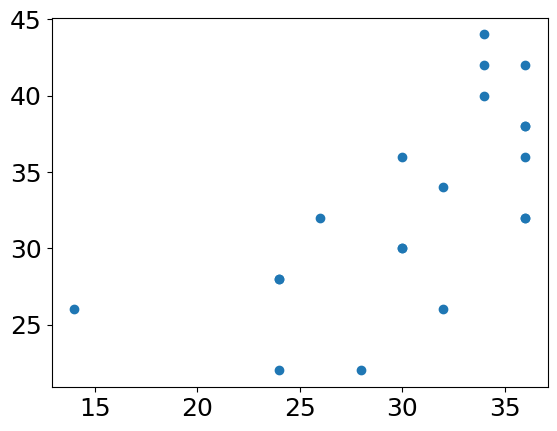

In [401]:
num_topics = 50
dataset = 'postnauka'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[18.0, 24.0, 26.0, 30.0, 30.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 34.0, 34.0, 34.0, 34.0, 34.0, 34.0, 36.0]
[20.0, 28.000000000000004, 36.0, 34.0, 26.0, 30.0, 32.0, 36.0, 44.0, 36.0, 36.0, 30.0, 46.0, 38.0, 42.0, 44.0, 32.0, 32.0, 44.0, 28.000000000000004]


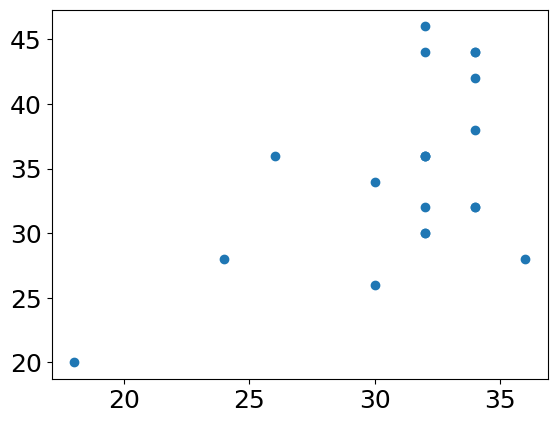

In [402]:
num_topics = 50
dataset = '20newsgroups'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[20.0, 24.0, 28.000000000000004, 28.000000000000004, 32.0, 34.0, 34.0, 34.0, 34.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0]
[22.0, 36.0, 46.0, 42.0, 52.0, 60.0, 64.0, 62.0, 70.0, 66.0, 60.0, 62.0, 54.0, 54.0, 60.0, 48.0, 52.0, 50.0, 48.0, 56.00000000000001]


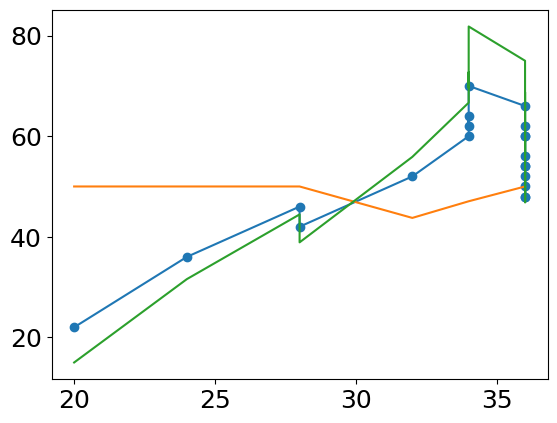

In [536]:
num_topics = 50
dataset = 'mkb10'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

In [520]:
x, y

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [20.0,
  24.0,
  28.000000000000004,
  28.000000000000004,
  32.0,
  34.0,
  34.0,
  34.0,
  34.0,
  36.0,
  36.0,
  36.0,
  36.0,
  36.0,
  36.0,
  36.0,
  36.0,
  36.0,
  36.0,
  36.0])

In [521]:
x1, y1, y2, y3

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [22.0,
  36.0,
  46.0,
  42.0,
  52.0,
  60.0,
  64.0,
  62.0,
  70.0,
  66.0,
  60.0,
  62.0,
  54.0,
  54.0,
  60.0,
  48.0,
  52.0,
  50.0,
  48.0,
  56.00000000000001],
 [45.45454545454545,
  33.33333333333333,
  30.434782608695656,
  33.33333333333333,
  26.923076923076923,
  26.666666666666668,
  25.0,
  25.806451612903224,
  22.857142857142858,
  27.27272727272727,
  30.0,
  29.03225806451613,
  33.33333333333333,
  33.33333333333333,
  30.0,
  37.5,
  34.61538461538461,
  36.0,
  37.5,
  32.142857142857146],
 [15.384615384615385,
  37.5,
  59.25925925925925,
  48.275862068965516,
  79.16666666666666,
  110.00000000000001,
  133.33333333333331,
  121.05263157894737,
  180.0,
  141.1764705882353,
  105.0,
  115.78947368421053,
  78.26086956521739,
  78.26086956521739,
  105.0,
  57.692307692307686,
  70.83333333333334,
  64.0,
  57.692307692307686,
  86.36363636363636])

[20.0, 26.0, 30.0, 30.0, 32.0, 34.0, 38.0, 42.0, 42.0, 44.0, 44.0, 44.0, 44.0, 48.0]
[22.0, 54.0, 70.0, 68.0, 72.0, 76.0, 60.0, 60.0, 60.0, 50.0, 44.0, 38.0, 50.0, 40.0]


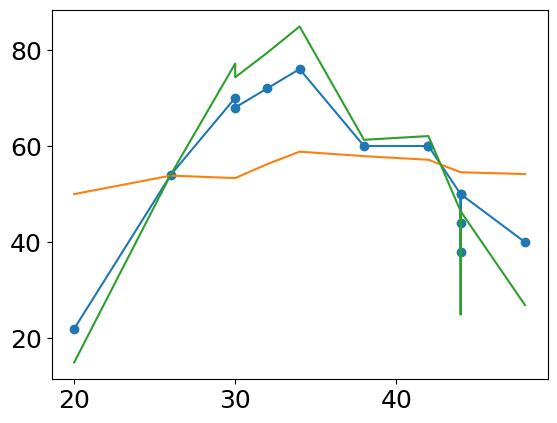

In [537]:
num_topics = 50
dataset = 'mkb10'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[15.0, 25.0, 25.0, 30.0, 30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0]
[30.0, 20.0, 25.0, 25.0, 30.0, 40.0, 30.0, 30.0, 45.0, 30.0, 40.0, 45.0, 40.0, 50.0, 50.0, 60.0, 55.00000000000001, 45.0, 50.0, 55.00000000000001]


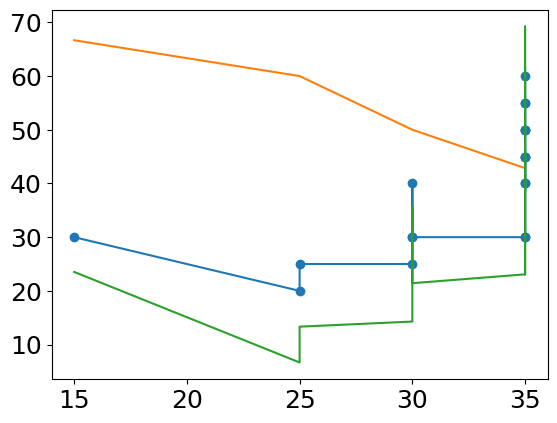

In [538]:
num_topics = 20
dataset = 'postnauka'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[15.0, 25.0, 25.0, 30.0, 30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0]
[30.0, 20.0, 25.0, 25.0, 20.0, 35.0, 25.0, 25.0, 35.0, 25.0, 25.0, 45.0, 35.0, 45.0, 35.0, 40.0, 55.00000000000001, 30.0, 45.0, 50.0]


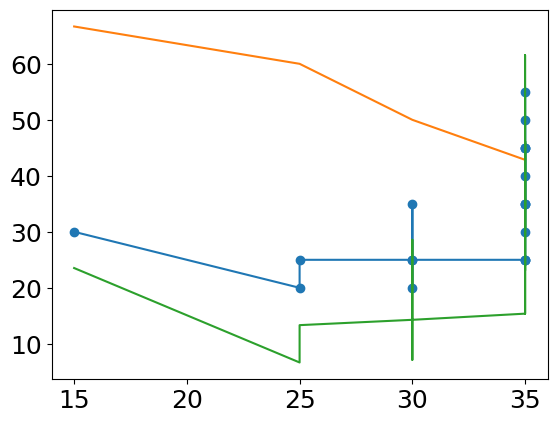

In [539]:
num_topics = 20
dataset = 'postnauka'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[20.0, 25.0, 25.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0]
[30.0, 25.0, 25.0, 45.0, 35.0, 45.0, 45.0, 45.0, 60.0, 60.0, 50.0, 50.0, 40.0, 40.0, 50.0, 45.0, 45.0, 55.00000000000001, 45.0, 40.0]


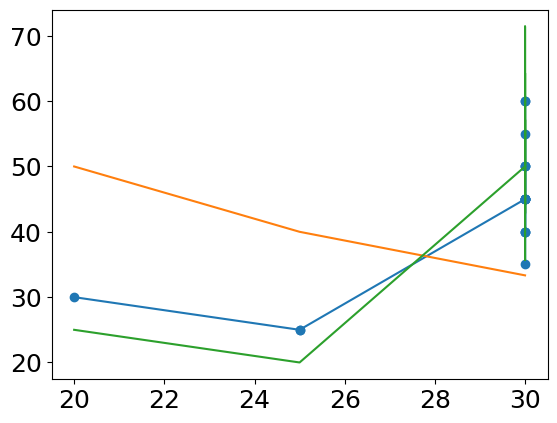

In [540]:
num_topics = 20
dataset = '20newsgroups'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[20.0, 25.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0]
[30.0, 30.0, 25.0, 35.0, 25.0, 40.0, 45.0, 25.0, 40.0, 25.0, 45.0, 30.0, 40.0, 35.0, 30.0, 35.0, 45.0, 50.0, 60.0, 45.0]


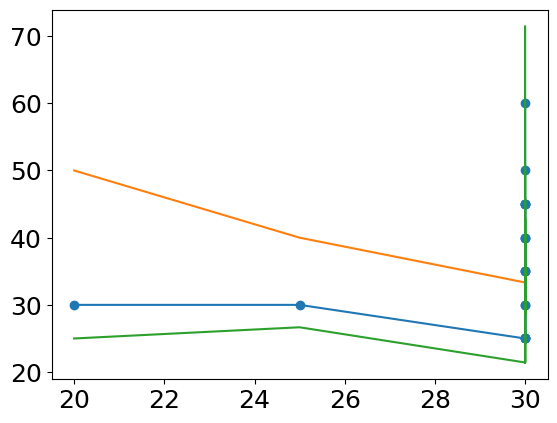

In [541]:
num_topics = 20
dataset = '20newsgroups'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0]
[35.0, 50.0, 60.0, 40.0, 55.00000000000001, 55.00000000000001, 55.00000000000001, 50.0, 65.0, 65.0, 55.00000000000001, 65.0, 75.0, 55.00000000000001, 70.0, 70.0, 60.0, 60.0, 60.0, 60.0]


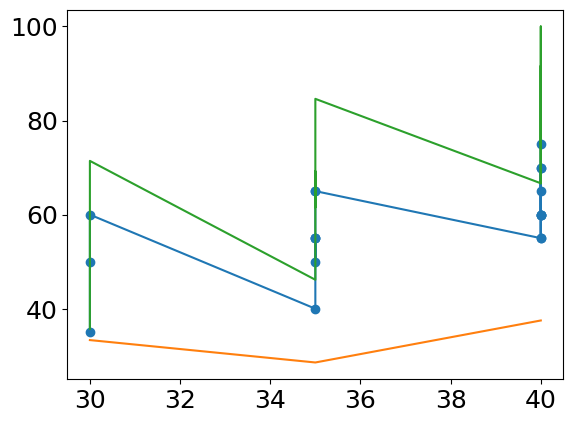

In [542]:
num_topics = 20
dataset = 'mkb10'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0]
[35.0, 45.0, 50.0, 40.0, 55.00000000000001, 50.0, 50.0, 55.00000000000001, 60.0, 50.0, 60.0, 60.0, 65.0, 70.0, 65.0, 65.0, 60.0, 65.0, 55.00000000000001, 60.0]


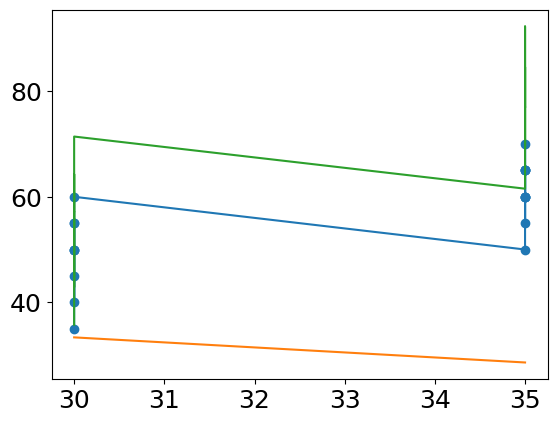

In [543]:
num_topics = 20
dataset = 'mkb10'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[14.000000000000002, 26.0, 26.0, 28.000000000000004, 28.000000000000004, 30.0, 32.0, 32.0, 32.0, 32.0, 32.0, 36.0, 36.0, 38.0, 38.0, 40.0, 40.0]
[26.0, 34.0, 36.0, 46.0, 42.0, 48.0, 46.0, 50.0, 54.0, 46.0, 56.00000000000001, 34.0, 42.0, 50.0, 40.0, 38.0, 42.0]


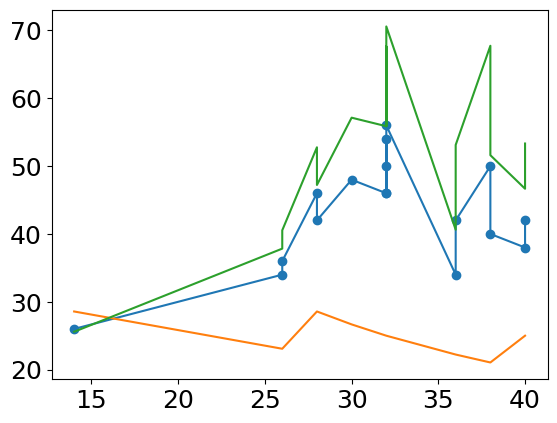

In [544]:
num_topics = 50
dataset = 'postnauka'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[14.000000000000002, 24.0, 24.0, 24.0, 26.0, 28.000000000000004, 30.0, 30.0, 30.0, 32.0, 32.0, 34.0, 34.0, 34.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0]
[26.0, 28.000000000000004, 22.0, 28.000000000000004, 32.0, 22.0, 30.0, 30.0, 36.0, 26.0, 34.0, 44.0, 42.0, 40.0, 42.0, 36.0, 38.0, 32.0, 32.0, 38.0]


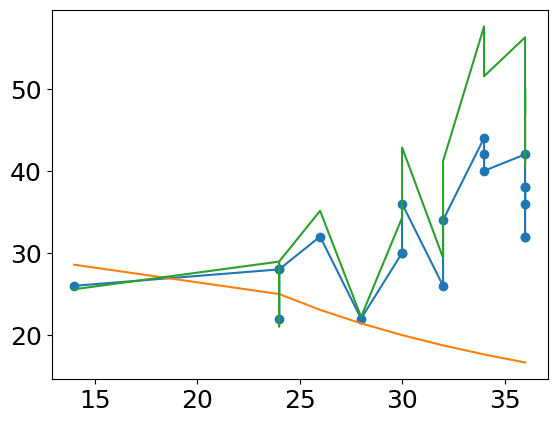

In [545]:
num_topics = 50
dataset = 'postnauka'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[18.0, 24.0, 24.0, 26.0, 30.0, 30.0, 30.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 34.0, 38.0, 38.0, 38.0, 38.0]
[20.0, 34.0, 38.0, 32.0, 36.0, 46.0, 52.0, 44.0, 52.0, 54.0, 42.0, 40.0, 42.0, 42.0, 34.0, 42.0, 32.0, 34.0, 34.0, 34.0]


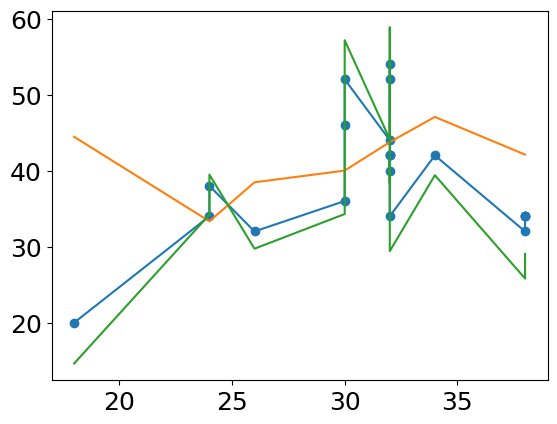

In [546]:
num_topics = 50
dataset = '20newsgroups'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[18.0, 24.0, 26.0, 30.0, 30.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 34.0, 34.0, 34.0, 34.0, 34.0, 34.0, 36.0]
[20.0, 28.000000000000004, 36.0, 34.0, 26.0, 30.0, 32.0, 36.0, 44.0, 36.0, 36.0, 30.0, 46.0, 38.0, 42.0, 44.0, 32.0, 32.0, 44.0, 28.000000000000004]


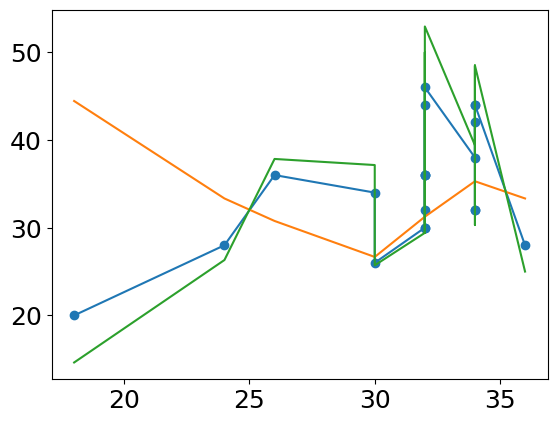

In [547]:
num_topics = 50
dataset = '20newsgroups'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[20.0, 26.0, 30.0, 30.0, 32.0, 34.0, 38.0, 42.0, 42.0, 44.0, 44.0, 44.0, 44.0, 48.0]
[22.0, 54.0, 70.0, 68.0, 72.0, 76.0, 60.0, 60.0, 60.0, 50.0, 44.0, 38.0, 50.0, 40.0]


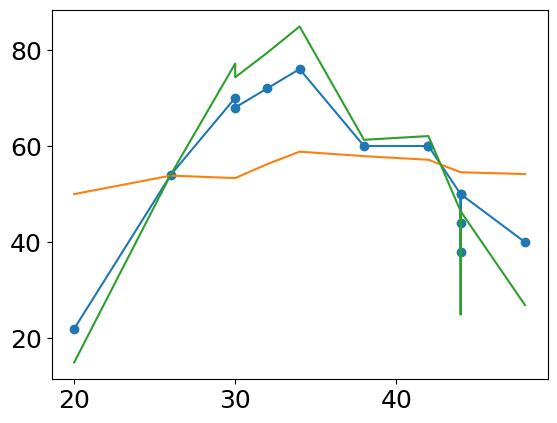

In [548]:
num_topics = 50
dataset = 'mkb10'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[20.0, 24.0, 28.000000000000004, 28.000000000000004, 32.0, 34.0, 34.0, 34.0, 34.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0]
[22.0, 36.0, 46.0, 42.0, 52.0, 60.0, 64.0, 62.0, 70.0, 66.0, 60.0, 62.0, 54.0, 54.0, 60.0, 48.0, 52.0, 50.0, 48.0, 56.00000000000001]


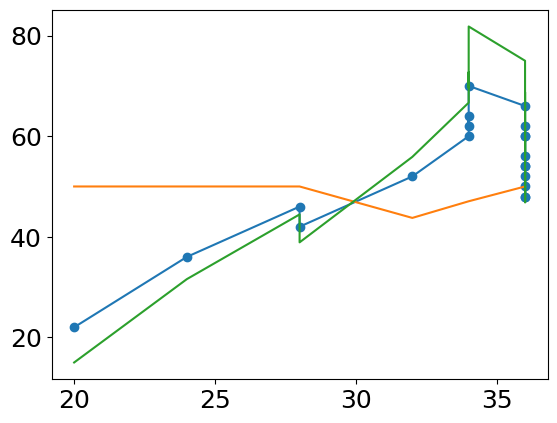

In [549]:
num_topics = 50
dataset = 'mkb10'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2)
plt.plot(y, y3)
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

In [424]:
## After computation logic change (n - n_i, n / (T - n_i))

[15.0, 25.0, 25.0, 30.0, 30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0]
[30.0, 20.0, 25.0, 25.0, 30.0, 40.0, 30.0, 30.0, 45.0, 30.0, 40.0, 45.0, 40.0, 50.0, 50.0, 60.0, 55.00000000000001, 45.0, 50.0, 55.00000000000001]


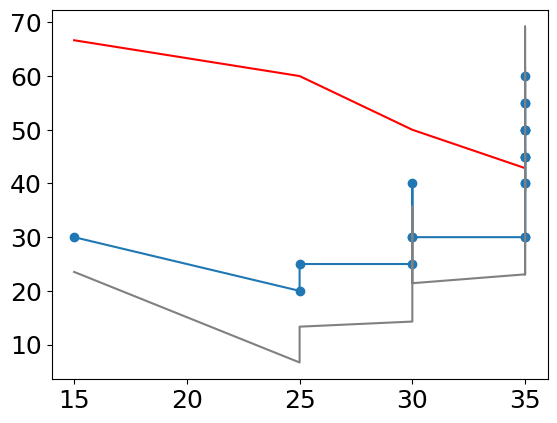

In [550]:
num_topics = 20
dataset = 'postnauka'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[15.0, 25.0, 25.0, 30.0, 30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0]
[30.0, 20.0, 25.0, 25.0, 20.0, 35.0, 25.0, 25.0, 35.0, 25.0, 25.0, 45.0, 35.0, 45.0, 35.0, 40.0, 55.00000000000001, 30.0, 45.0, 50.0]


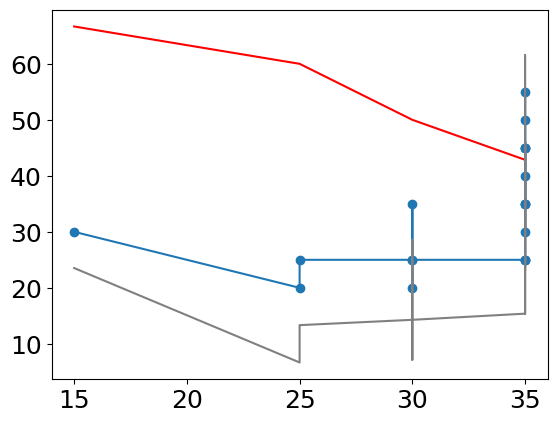

In [551]:
num_topics = 20
dataset = 'postnauka'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[20.0, 25.0, 25.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0]
[30.0, 25.0, 25.0, 45.0, 35.0, 45.0, 45.0, 45.0, 60.0, 60.0, 50.0, 50.0, 40.0, 40.0, 50.0, 45.0, 45.0, 55.00000000000001, 45.0, 40.0]


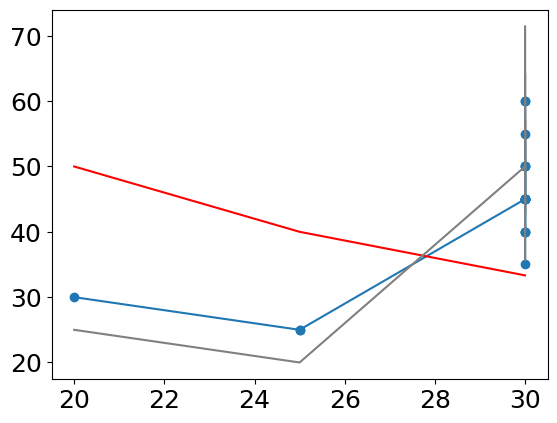

In [552]:
num_topics = 20
dataset = '20newsgroups'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[20.0, 25.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0]
[30.0, 30.0, 25.0, 35.0, 25.0, 40.0, 45.0, 25.0, 40.0, 25.0, 45.0, 30.0, 40.0, 35.0, 30.0, 35.0, 45.0, 50.0, 60.0, 45.0]


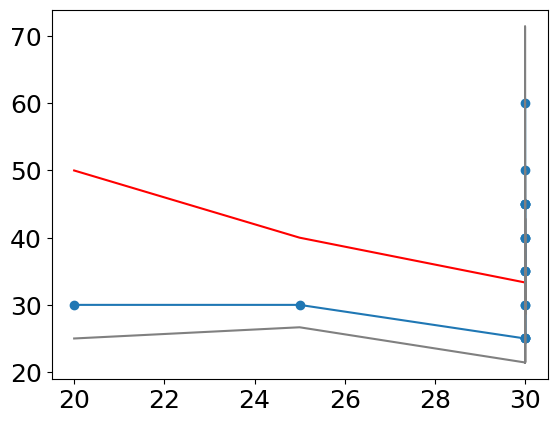

In [553]:
num_topics = 20
dataset = '20newsgroups'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0]
[35.0, 50.0, 60.0, 40.0, 55.00000000000001, 55.00000000000001, 55.00000000000001, 50.0, 65.0, 65.0, 55.00000000000001, 65.0, 75.0, 55.00000000000001, 70.0, 70.0, 60.0, 60.0, 60.0, 60.0]


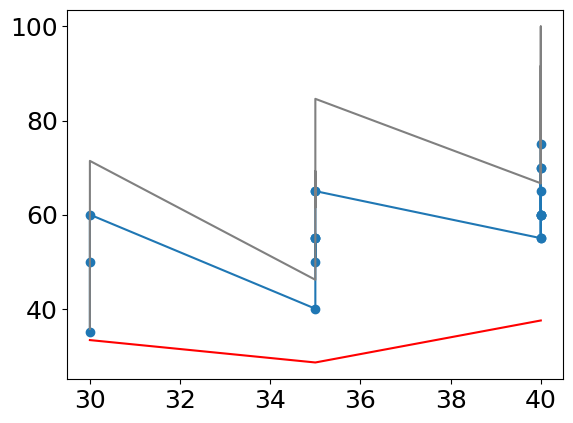

In [554]:
num_topics = 20
dataset = 'mkb10'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0, 35.0]
[35.0, 45.0, 50.0, 40.0, 55.00000000000001, 50.0, 50.0, 55.00000000000001, 60.0, 50.0, 60.0, 60.0, 65.0, 70.0, 65.0, 65.0, 60.0, 65.0, 55.00000000000001, 60.0]


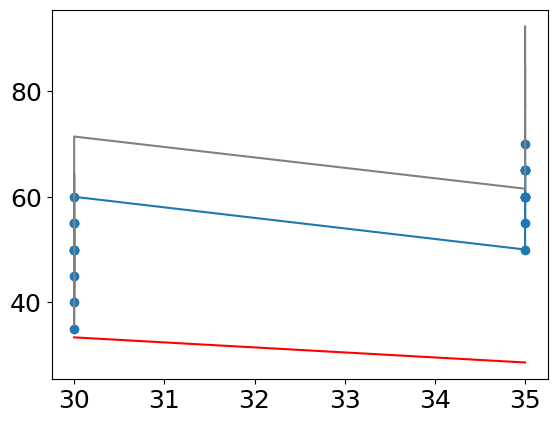

In [555]:
num_topics = 20
dataset = 'mkb10'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[14.000000000000002, 26.0, 26.0, 28.000000000000004, 28.000000000000004, 30.0, 32.0, 32.0, 32.0, 32.0, 32.0, 36.0, 36.0, 38.0, 38.0, 40.0, 40.0]
[26.0, 34.0, 36.0, 46.0, 42.0, 48.0, 46.0, 50.0, 54.0, 46.0, 56.00000000000001, 34.0, 42.0, 50.0, 40.0, 38.0, 42.0]


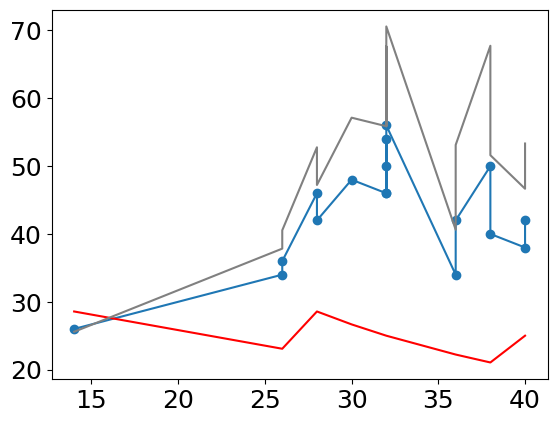

In [556]:
num_topics = 50
dataset = 'postnauka'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[14.000000000000002, 24.0, 24.0, 24.0, 26.0, 28.000000000000004, 30.0, 30.0, 30.0, 32.0, 32.0, 34.0, 34.0, 34.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0]
[26.0, 28.000000000000004, 22.0, 28.000000000000004, 32.0, 22.0, 30.0, 30.0, 36.0, 26.0, 34.0, 44.0, 42.0, 40.0, 42.0, 36.0, 38.0, 32.0, 32.0, 38.0]


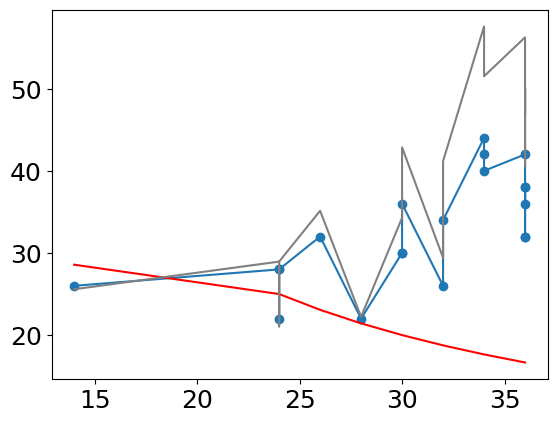

In [557]:
num_topics = 50
dataset = 'postnauka'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[18.0, 24.0, 24.0, 26.0, 30.0, 30.0, 30.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 34.0, 38.0, 38.0, 38.0, 38.0]
[20.0, 34.0, 38.0, 32.0, 36.0, 46.0, 52.0, 44.0, 52.0, 54.0, 42.0, 40.0, 42.0, 42.0, 34.0, 42.0, 32.0, 34.0, 34.0, 34.0]


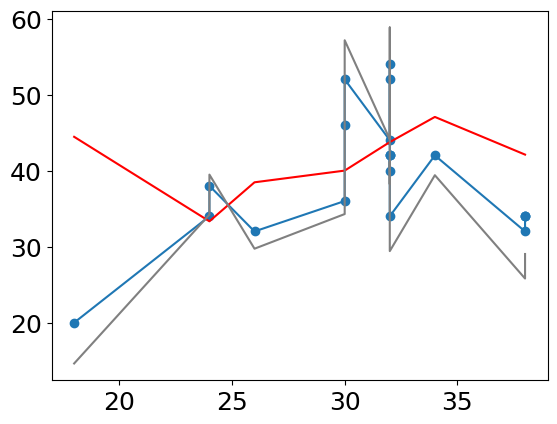

In [558]:
num_topics = 50
dataset = '20newsgroups'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[18.0, 24.0, 26.0, 30.0, 30.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 32.0, 34.0, 34.0, 34.0, 34.0, 34.0, 34.0, 36.0]
[20.0, 28.000000000000004, 36.0, 34.0, 26.0, 30.0, 32.0, 36.0, 44.0, 36.0, 36.0, 30.0, 46.0, 38.0, 42.0, 44.0, 32.0, 32.0, 44.0, 28.000000000000004]


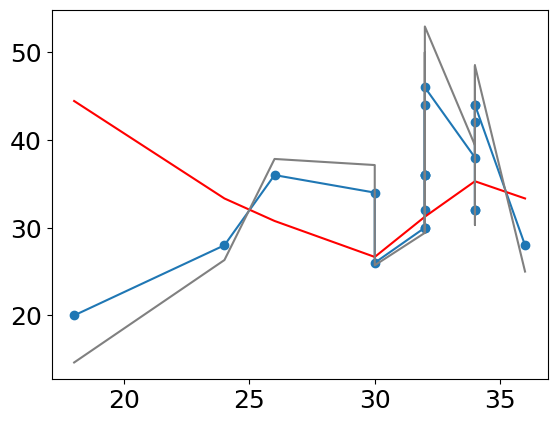

In [559]:
num_topics = 50
dataset = '20newsgroups'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[20.0, 26.0, 30.0, 30.0, 32.0, 34.0, 38.0, 42.0, 42.0, 44.0, 44.0, 44.0, 44.0, 48.0]
[22.0, 54.0, 70.0, 68.0, 72.0, 76.0, 60.0, 60.0, 60.0, 50.0, 44.0, 38.0, 50.0, 40.0]


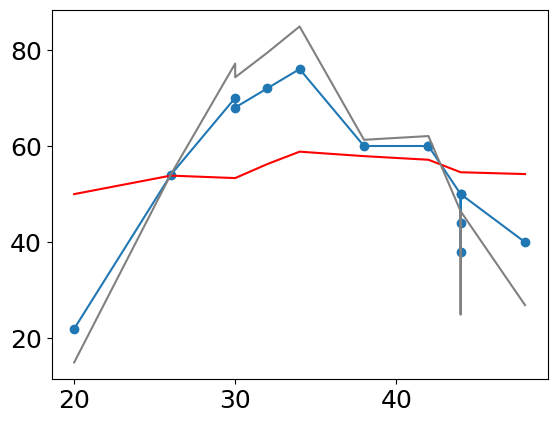

In [560]:
num_topics = 50
dataset = 'mkb10'
model = 'iterative'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

[20.0, 24.0, 28.000000000000004, 28.000000000000004, 32.0, 34.0, 34.0, 34.0, 34.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0, 36.0]
[22.0, 36.0, 46.0, 42.0, 52.0, 60.0, 64.0, 62.0, 70.0, 66.0, 60.0, 62.0, 54.0, 54.0, 60.0, 48.0, 52.0, 50.0, 48.0, 56.00000000000001]


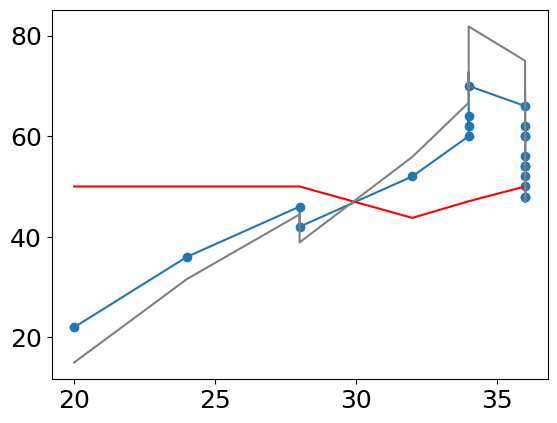

In [561]:
num_topics = 50
dataset = 'mkb10'
model = 'iterative2'

x, y = get_num_good_topics_percents(num_topics, dataset, model)
x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

print(y)
print(y1)

plt.scatter(y, y1)
plt.plot(y, y1)
plt.plot(y, y2, color='red')
plt.plot(y, y3, color='grey')
# plt.scatter(y, y2, color='red')
# plt.scatter(y, y3, color='grey')

In [112]:
COHERENCES = {
    'postnauka': {
        20: list(),
        50: list(),
    },
    '20newsgroups': {
        20: list(),
        50: list(),
    },
    'mkb10': {
        20: list(),
        50: list(),
    }
}

In [113]:
RESULTS[20]['postnauka'].keys()

dict_keys(['plsa', 'sparse', 'decorrelation', 'tless', 'lda', 'iterative', 'iterative2', 'topic_bank2', 'bertopic'])

In [114]:
len(RESULTS[20]['postnauka']['plsa']['iters'])

20

In [115]:
RESULTS[20]['postnauka']['plsa']['iters'][0]

{'scores': {'perplexity': 2474.488525390625,
  'coherence_20': 0.7306223409796534,
  'toplen_ptw': 2.2222272562846417,
  'topden_ptw': 0.4862072599670759,
  'diversity_euclidean': 0.05432938184650551,
  'diversity_jensenshannon': 0.6000053797380491,
  'diversity_hellinger': 0.6857673609277269,
  'diversity_cosine': 0.7377318746693401},
 'topic_coherences': {'0': 0.4682133200037822,
  '1': 0.5525499039748306,
  '2': 0.3662412591097539,
  '3': 0.7660746688638103,
  '4': 0.6599584504901529,
  '5': 1.2151843412918593,
  '6': 0.784374938331295,
  '7': 0.6583524284174844,
  '8': 0.7558873960285204,
  '9': 0.8872288724338003,
  '10': 0.5060579830596448,
  '11': 1.1643195534386466,
  '12': 1.0551562205101295,
  '13': 0.6667121824386473,
  '14': 0.34910355580365166,
  '15': 0.7823822821267535,
  '16': 1.0022462210267367,
  '17': 0.8400496475709041,
  '18': 0.706545516531718,
  '19': 0.425808078140945},
 'topic_coherences_toplen_ptw': {'0': 2.0956432149414908,
  '1': 2.1535240947120737,
  '2': 2

In [116]:
for dataset in ['postnauka', '20newsgroups', 'mkb10']:
    for num_topics in [20, 50]:
        for model in ['plsa', 'sparse', 'decorrelation', 'tless', 'lda']:
            for iter in RESULTS[num_topics][dataset][model]['iters']:
                COHERENCES[dataset][num_topics].extend(
                    list(iter['topic_coherences'].values())
                )

In [117]:
len(COHERENCES['postnauka'][20]), len(COHERENCES['postnauka'][50])

(2000, 5000)

In [118]:
5 * 20 * 20, 5 * 20 * 50

(2000, 5000)

In [119]:
COHERENCE_THRESHOLDS = dict()

for dataset in COHERENCES:
    COHERENCE_THRESHOLDS[dataset] = dict()

    for num_topics in COHERENCES[dataset]:
        COHERENCE_THRESHOLDS[dataset][num_topics] = float(np.percentile(
            COHERENCES[dataset][num_topics], 80
        ))

In [120]:
COHERENCE_THRESHOLDS

{'postnauka': {20: 0.8825231364747546, 50: 1.0264533769087847},
 '20newsgroups': {20: 1.6095355359760972, 50: 1.813393592491583},
 'mkb10': {20: 0.7372573006249383, 50: 0.8997333820973618}}

In [127]:
AVEGARE_PERCENTS_GOOD = dict()
DIFF_PERCENTS_GOOD = dict()

for dataset in ['postnauka', '20newsgroups', 'mkb10']:
    AVEGARE_PERCENTS_GOOD[dataset] = dict()
    DIFF_PERCENTS_GOOD[dataset] = dict()
    
    for num_topics in [20, 50]:
        x = 0.0
        num_models = 0
        percents = []
        
        for model in ['plsa', 'sparse', 'decorrelation', 'tless', 'lda']:
            for iter in RESULTS[num_topics][dataset][model]['iters']:
                n = sum([
                    1 if v >= COHERENCE_THRESHOLDS[dataset][num_topics] else 0
                    for v in iter['topic_coherences'].values()
                ])
                f = n / num_topics * 100
                x += f
                percents.append(f)

                num_models += 1

        AVEGARE_PERCENTS_GOOD[dataset][num_topics] = x / num_models
        DIFF_PERCENTS_GOOD[dataset][num_topics] = float(np.std(percents))

In [128]:
AVEGARE_PERCENTS_GOOD

{'postnauka': {20: 20.0, 50: 20.0},
 '20newsgroups': {20: 20.0, 50: 20.0},
 'mkb10': {20: 20.0, 50: 20.0}}

In [129]:
DIFF_PERCENTS_GOOD

{'postnauka': {20: 5.196152422706632, 50: 3.7202150475476548},
 '20newsgroups': {20: 6.782329983125268, 50: 5.678027826631356},
 'mkb10': {20: 7.713624310270756, 50: 10.87382177525455}}

In [133]:
rel_diffs = []

for dataset in ['postnauka', '20newsgroups', 'mkb10']:
    for num_topics in [20, 50]:
        av = AVEGARE_PERCENTS_GOOD[dataset][num_topics]
        diff = DIFF_PERCENTS_GOOD[dataset][num_topics]

        rel_diffs.append(diff / av)
        
        print(dataset, num_topics)
        print((- diff) / av, av / av, (+ diff) / av)
        print()

postnauka 20
-0.2598076211353316 1.0 0.2598076211353316

postnauka 50
-0.18601075237738274 1.0 0.18601075237738274

20newsgroups 20
-0.3391164991562634 1.0 0.3391164991562634

20newsgroups 50
-0.28390139133156783 1.0 0.28390139133156783

mkb10 20
-0.3856812155135378 1.0 0.3856812155135378

mkb10 50
-0.5436910887627275 1.0 0.5436910887627275



In [134]:
np.mean(rel_diffs), np.median(rel_diffs)

(0.33303476137946847, 0.3115089452439156)

In [169]:
# AVEGARE_IN_PERCENTS_GOOD = dict()
# DIFF_IN_PERCENTS_GOOD = dict()

INDICES_TOPTOK_GOOD = dict()
INDICES_INTRA_GOOD = dict()

for dataset in ['postnauka', '20newsgroups', 'mkb10']:
    # AVEGARE_IN_PERCENTS_GOOD[dataset] = dict()

    INDICES_TOPTOK_GOOD[dataset] = dict()
    INDICES_INTRA_GOOD[dataset] = dict()
    # DIFF_IN_PERCENTS_GOOD[dataset] = dict()
    
    for num_topics in [20, 50]:
        if num_topics == 20:
            COHERENCE_THRESHOLDS_TOPTOK = DATASET_GOOD_COHERENCE_THRESHOLDS_20_TOPTOK
            COHERENCE_THRESHOLDS_INTRA = DATASET_GOOD_COHERENCE_THRESHOLDS_20
        else:
            COHERENCE_THRESHOLDS_TOPTOK = DATASET_GOOD_COHERENCE_THRESHOLDS_50_TOPTOK
            COHERENCE_THRESHOLDS_INTRA = DATASET_GOOD_COHERENCE_THRESHOLDS_50

        indices_toptok = []
        indices_intra = []

        for model in ['plsa', 'sparse', 'decorrelation', 'tless', 'lda']:
            x, y = get_num_good_topics_percents(num_topics, dataset, model)
            # good, good toptok in intra, good toptok out intra
            x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

            assert len(y) == len(y1) == len(y2) == len(y3)

            for i, iter in enumerate(RESULTS[num_topics][dataset][model]['iters']):
                cur_indices_toptok = [
                    True if v >= COHERENCE_THRESHOLDS_TOPTOK[dataset] else False
                    for v in iter['topic_coherences'].values()
                ]
                cur_indices_intra = [
                    True if v >= COHERENCE_THRESHOLDS_INTRA[dataset] else False
                    for v in iter['topic_coherences_toplen_ptw'].values()
                ]

                assert abs(
                    sum(cur_indices_toptok) - y1[i] / 100 * num_topics
                ) <= 1e-5
                assert abs(
                    sum(cur_indices_intra) - y[i] / 100 * num_topics
                ) <= 1e-5
                assert abs(
                    y2[i] / 100 * sum(cur_indices_intra) + y3[i] / 100 * (
                        num_topics - sum(cur_indices_intra))
                    - sum(cur_indices_toptok)
                ) <= 1e-5

                indices_toptok.extend(cur_indices_toptok)
                indices_intra.extend(cur_indices_intra)

        INDICES_TOPTOK_GOOD[dataset][num_topics] = indices_toptok
        INDICES_INTRA_GOOD[dataset][num_topics] = indices_intra

        # AVEGARE_IN_PERCENTS_GOOD[dataset][num_topics] = x / num_models
        # DIFF_IN_PERCENTS_GOOD[dataset][num_topics] = float(np.std(percents))

In [170]:
INDICES_TOPTOK_GOOD.keys()

dict_keys(['postnauka', '20newsgroups', 'mkb10'])

In [171]:
INDICES_TOPTOK_GOOD['postnauka'].keys()

dict_keys([20, 50])

In [172]:
len(INDICES_TOPTOK_GOOD['postnauka'][20]), len(INDICES_TOPTOK_GOOD['postnauka'][50])

(2000, 5000)

In [173]:
for dataset in ['postnauka', '20newsgroups', 'mkb10']:
    for num_topics in [20, 50]:
        print(dataset, num_topics)
        print(len(INDICES_TOPTOK_GOOD[dataset][num_topics]), len(INDICES_INTRA_GOOD[dataset][num_topics]))
        print(sum(INDICES_TOPTOK_GOOD[dataset][num_topics]) / len(INDICES_TOPTOK_GOOD[dataset][num_topics]),
              sum(INDICES_INTRA_GOOD[dataset][num_topics]) / len(INDICES_INTRA_GOOD[dataset][num_topics]))
        print()

postnauka 20
2000 2000
0.2 0.3

postnauka 50
5000 5000
0.2 0.3

20newsgroups 20
2000 2000
0.2 0.3

20newsgroups 50
5000 5000
0.2 0.3

mkb10 20
2000 2000
0.2 0.3

mkb10 50
5000 5000
0.2 0.3



In [182]:
indices_intra

array([False,  True, False, ..., False,  True, False])

In [185]:
~indices_intra

array([ True, False,  True, ...,  True, False,  True])

In [193]:
AVEGARE_IN_PERCENTS_GOOD = dict()
AVEGARE_OUT_PERCENTS_GOOD = dict()

for dataset in ['postnauka', '20newsgroups', 'mkb10']:
    AVEGARE_IN_PERCENTS_GOOD[dataset] = dict()
    AVEGARE_OUT_PERCENTS_GOOD[dataset] = dict()

    for num_topics in [20, 50]:
        assert len(INDICES_TOPTOK_GOOD[dataset][num_topics]) == len(INDICES_INTRA_GOOD[dataset][num_topics])

        indices_toptok = np.array(INDICES_TOPTOK_GOOD[dataset][num_topics])
        indices_intra = np.array(INDICES_INTRA_GOOD[dataset][num_topics])
        
        AVEGARE_IN_PERCENTS_GOOD[dataset][num_topics] = (
            sum(indices_toptok[indices_intra]) / sum(indices_intra)
        )
        AVEGARE_OUT_PERCENTS_GOOD[dataset][num_topics] = (
            sum(indices_toptok[~indices_intra]) / sum(~indices_intra)
        )

In [194]:
AVEGARE_IN_PERCENTS_GOOD  # TODO (note): Higher than average

{'postnauka': {20: 0.4216666666666667, 50: 0.3466666666666667},
 '20newsgroups': {20: 0.23666666666666666, 50: 0.342},
 'mkb10': {20: 0.30666666666666664, 50: 0.37066666666666664}}

In [195]:
AVEGARE_OUT_PERCENTS_GOOD  # TODO (note): Lower than average

{'postnauka': {20: 0.105, 50: 0.13714285714285715},
 '20newsgroups': {20: 0.18428571428571427, 50: 0.13914285714285715},
 'mkb10': {20: 0.15428571428571428, 50: 0.12685714285714286}}

In [260]:
MEAN_IN_PERCENTS_GOOD = dict()
DIFF_IN_PERCENTS_GOOD = dict()
N = 100000

random = np.random.RandomState(42)

for dataset in ['postnauka', '20newsgroups', 'mkb10']:
    MEAN_IN_PERCENTS_GOOD[dataset] = dict()
    DIFF_IN_PERCENTS_GOOD[dataset] = dict()

    for num_topics in [20, 50]:
        MEAN_IN_PERCENTS_GOOD[dataset][num_topics] = 0.0
        DIFF_IN_PERCENTS_GOOD[dataset][num_topics] = 0.0
        fractions = list()

        for i in range(N):
            n = i + 1

            assert len(INDICES_TOPTOK_GOOD[dataset][num_topics]) == len(INDICES_INTRA_GOOD[dataset][num_topics])
    
            indices_toptok = np.array(INDICES_TOPTOK_GOOD[dataset][num_topics])
            indices_intra = np.array(INDICES_INTRA_GOOD[dataset][num_topics])
            
            all_indices = np.array(list(range(0, len(indices_intra))))
            indices_in = random.choice(all_indices, size=sum(indices_intra), replace=False)

            assert len(indices_in) == sum(indices_intra)

            av = sum(indices_toptok[indices_in]) / sum(indices_intra)
            
            # DIFF_IN_PERCENTS_GOOD[dataset][num_topics] = (
            #     (DIFF_IN_PERCENTS_GOOD[dataset][num_topics] * (n - 1) + av) / n
            # )
            fractions.append(av)

        # DIFF_IN_PERCENTS_GOOD[dataset][num_topics] = np.std(fractions)  # TODO: we now "the real" mean
        # DIFF_IN_PERCENTS_GOOD[dataset][num_topics] = float(np.sqrt(
        #     np.sum(
        #         (np.array(fractions) - AVEGARE_IN_PERCENTS_GOOD[dataset][num_topics]) ** 2
        #     ) / len(fractions)
        # ))  # TODO: Nooo! This is not "the real" mean. We need "real std"!
        DIFF_IN_PERCENTS_GOOD[dataset][num_topics] = float(np.std(fractions))

        MEAN_IN_PERCENTS_GOOD[dataset][num_topics] = float(np.mean(fractions))

In [249]:
# N = 1

MEAN_IN_PERCENTS_GOOD, DIFF_IN_PERCENTS_GOOD

({'postnauka': {20: 0.19166666666666668, 50: 0.20333333333333334},
  '20newsgroups': {20: 0.21166666666666667, 50: 0.20333333333333334},
  'mkb10': {20: 0.18833333333333332, 50: 0.19133333333333333}},
 {'postnauka': {20: 0.0, 50: 0.0},
  '20newsgroups': {20: 0.0, 50: 0.0},
  'mkb10': {20: 0.0, 50: 0.0}})

In [251]:
# N = 10

MEAN_IN_PERCENTS_GOOD, DIFF_IN_PERCENTS_GOOD

({'postnauka': {20: 0.20033333333333334, 50: 0.20106666666666667},
  '20newsgroups': {20: 0.20099999999999998, 50: 0.20173333333333338},
  'mkb10': {20: 0.20583333333333337, 50: 0.19166666666666665}},
 {'postnauka': {20: 0.009854496999396323, 50: 0.007267584039952873},
  '20newsgroups': {20: 0.007788880963698617, 50: 0.00864715752911518},
  'mkb10': {20: 0.011528949070347507, 50: 0.004973261840415539}})

In [253]:
# N = 100

MEAN_IN_PERCENTS_GOOD, DIFF_IN_PERCENTS_GOOD

({'postnauka': {20: 0.19991666666666671, 50: 0.19985333333333336},
  '20newsgroups': {20: 0.20198333333333335, 50: 0.20167333333333334},
  'mkb10': {20: 0.20353333333333332, 50: 0.2007}},
 {'postnauka': {20: 0.012495276885465343, 50: 0.008752183219695023},
  '20newsgroups': {20: 0.014326926862845826, 50: 0.008575155327391388},
  'mkb10': {20: 0.013606126071246977, 50: 0.008020182874058004}})

In [255]:
# N = 1000

MEAN_IN_PERCENTS_GOOD, DIFF_IN_PERCENTS_GOOD

({'postnauka': {20: 0.200205, 50: 0.20009266666666667},
  '20newsgroups': {20: 0.19944333333333333, 50: 0.200356},
  'mkb10': {20: 0.200115, 50: 0.20007866666666665}},
 {'postnauka': {20: 0.013538409454420988, 50: 0.00900853124050259},
  '20newsgroups': {20: 0.013596204944354469, 50: 0.008655142183824724},
  'mkb10': {20: 0.013352095029120586, 50: 0.008543849665760224}})

In [257]:
# N = 5000

MEAN_IN_PERCENTS_GOOD, DIFF_IN_PERCENTS_GOOD

({'postnauka': {20: 0.20031433333333334, 50: 0.20004213333333332},
  '20newsgroups': {20: 0.19985833333333336, 50: 0.19999666666666666},
  'mkb10': {20: 0.19991133333333333, 50: 0.20008666666666666}},
 {'postnauka': {20: 0.013656971158431222, 50: 0.008622791653132606},
  '20newsgroups': {20: 0.013531298594985874, 50: 0.008689093419019297},
  'mkb10': {20: 0.013553758166812792, 50: 0.008794713058296886}})

In [259]:
# N = 10000

MEAN_IN_PERCENTS_GOOD, DIFF_IN_PERCENTS_GOOD

({'postnauka': {20: 0.20026133333333332, 50: 0.20018366666666665},
  '20newsgroups': {20: 0.20015850000000002, 50: 0.19992306666666665},
  'mkb10': {20: 0.1999475, 50: 0.19997566666666666}},
 {'postnauka': {20: 0.013589253695475702, 50: 0.00858748960212859},
  '20newsgroups': {20: 0.013697795442049143, 50: 0.008643381098723911},
  'mkb10': {20: 0.013767363556816374, 50: 0.008522747802857427}})

In [261]:
# N = 100000

MEAN_IN_PERCENTS_GOOD, DIFF_IN_PERCENTS_GOOD

({'postnauka': {20: 0.20006093333333333, 50: 0.20004973999999998},
  '20newsgroups': {20: 0.20000768333333332, 50: 0.19998623999999995},
  'mkb10': {20: 0.20004875, 50: 0.20002668}},
 {'postnauka': {20: 0.013690942196941745, 50: 0.008644604311949609},
  '20newsgroups': {20: 0.013673903444548425, 50: 0.008644931051467226},
  'mkb10': {20: 0.013689360673885478, 50: 0.008604632819323424}})

In [233]:
AVEGARE_IN_PERCENTS_GOOD

{'postnauka': {20: 0.4216666666666667, 50: 0.3466666666666667},
 '20newsgroups': {20: 0.23666666666666666, 50: 0.342},
 'mkb10': {20: 0.30666666666666664, 50: 0.37066666666666664}}

In [245]:
AVEGARE_OUT_PERCENTS_GOOD

{'postnauka': {20: 0.105, 50: 0.13714285714285715},
 '20newsgroups': {20: 0.18428571428571427, 50: 0.13914285714285715},
 'mkb10': {20: 0.15428571428571428, 50: 0.12685714285714286}}

In [271]:
AVEGARE_IN_PERCENTS_GOOD_NORMALIZED = dict()
AVEGARE_OUT_PERCENTS_GOOD_NORMALIZED = dict()
MEAN_IN_PERCENTS_GOOD_NORMALIZED = dict()
DIFF_IN_PERCENTS_GOOD_NORMALIZED = dict()

for d in AVEGARE_IN_PERCENTS_GOOD:
    AVEGARE_IN_PERCENTS_GOOD_NORMALIZED[d] = dict()
    AVEGARE_OUT_PERCENTS_GOOD_NORMALIZED[d] = dict()
    MEAN_IN_PERCENTS_GOOD_NORMALIZED[d] = dict()
    DIFF_IN_PERCENTS_GOOD_NORMALIZED[d] = dict()
    
    for nt in AVEGARE_IN_PERCENTS_GOOD[d]:
        AVEGARE_IN_PERCENTS_GOOD_NORMALIZED[d][nt] = AVEGARE_IN_PERCENTS_GOOD[d][nt] / 0.20
        AVEGARE_OUT_PERCENTS_GOOD_NORMALIZED[d][nt] = AVEGARE_OUT_PERCENTS_GOOD[d][nt] / 0.20
        MEAN_IN_PERCENTS_GOOD_NORMALIZED[d][nt] = MEAN_IN_PERCENTS_GOOD[d][nt] / 0.20
        DIFF_IN_PERCENTS_GOOD_NORMALIZED[d][nt] = DIFF_IN_PERCENTS_GOOD[d][nt] / 0.20

In [273]:
MEAN_IN_PERCENTS_GOOD_NORMALIZED, DIFF_IN_PERCENTS_GOOD_NORMALIZED

({'postnauka': {20: 1.0003046666666666, 50: 1.0002486999999998},
  '20newsgroups': {20: 1.0000384166666665, 50: 0.9999311999999997},
  'mkb10': {20: 1.0002437499999999, 50: 1.0001334}},
 {'postnauka': {20: 0.06845471098470872, 50: 0.04322302155974804},
  '20newsgroups': {20: 0.06836951722274212, 50: 0.043224655257336125},
  'mkb10': {20: 0.06844680336942739, 50: 0.04302316409661712}})

In [274]:
AVEGARE_IN_PERCENTS_GOOD_NORMALIZED

{'postnauka': {20: 2.1083333333333334, 50: 1.7333333333333334},
 '20newsgroups': {20: 1.1833333333333333, 50: 1.71},
 'mkb10': {20: 1.5333333333333332, 50: 1.853333333333333}}

In [275]:
AVEGARE_OUT_PERCENTS_GOOD_NORMALIZED

{'postnauka': {20: 0.5249999999999999, 50: 0.6857142857142857},
 '20newsgroups': {20: 0.9214285714285714, 50: 0.6957142857142857},
 'mkb10': {20: 0.7714285714285714, 50: 0.6342857142857142}}

In [268]:
1

1

In [109]:
RESULTS_COHS_PERCENT_FIRST = {
    'postnauka': {
        20: dict(),
        50: dict(),
    },
    '20newsgroups': {
        20: dict(),
        50: dict(),
    },
    'mkb10': {
        20: dict(),
        50: dict(),
    } 
}

RESULTS_COHS_IN_PERCENT_FIRST = {
    'postnauka': {
        20: dict(),
        50: dict(),
    },
    '20newsgroups': {
        20: dict(),
        50: dict(),
    },
    'mkb10': {
        20: dict(),
        50: dict(),
    } 
}

RESULTS_COHS_OUT_PERCENT_FIRST = {
    'postnauka': {
        20: dict(),
        50: dict(),
    },
    '20newsgroups': {
        20: dict(),
        50: dict(),
    },
    'mkb10': {
        20: dict(),
        50: dict(),
    } 
}

###

RESULTS_COHS_PERCENT_LAST = {
    'postnauka': {
        20: dict(),
        50: dict(),
    },
    '20newsgroups': {
        20: dict(),
        50: dict(),
    },
    'mkb10': {
        20: dict(),
        50: dict(),
    } 
}

RESULTS_COHS_IN_PERCENT_LAST = {
    'postnauka': {
        20: dict(),
        50: dict(),
    },
    '20newsgroups': {
        20: dict(),
        50: dict(),
    },
    'mkb10': {
        20: dict(),
        50: dict(),
    } 
}

RESULTS_COHS_OUT_PERCENT_LAST = {
    'postnauka': {
        20: dict(),
        50: dict(),
    },
    '20newsgroups': {
        20: dict(),
        50: dict(),
    },
    'mkb10': {
        20: dict(),
        50: dict(),
    } 
}

for dataset in ['postnauka', '20newsgroups', 'mkb10']:
    for num_topics in [20, 50]:
        for model in ['topic_bank2', 'iterative', 'iterative2']:
            x, y = get_num_good_topics_percents(num_topics, dataset, model)
            x1, y1, y2, y3 = get_num_good_topics_percents_toptok(num_topics, dataset, model)

            assert len(y) == len(y1) == len(y2) == len(y3)

            RESULTS_COHS_PERCENT_FIRST[dataset][num_topics][model] = y1[0]#[0]
            RESULTS_COHS_IN_PERCENT_FIRST[dataset][num_topics][model] = y2[0]#[0]
            RESULTS_COHS_OUT_PERCENT_FIRST[dataset][num_topics][model] = y3[0]#[0]
            
            RESULTS_COHS_PERCENT_LAST[dataset][num_topics][model] = y1[-1]#[0]
            RESULTS_COHS_IN_PERCENT_LAST[dataset][num_topics][model] = y2[-1]#[0]
            RESULTS_COHS_OUT_PERCENT_LAST[dataset][num_topics][model] = y3[-1]#[0]

In [110]:
RESULTS_COHS_PERCENT_FIRST  # first iter

{'postnauka': {20: {'topic_bank2': 10.0,
   'iterative': 30.0,
   'iterative2': 30.0},
  50: {'topic_bank2': 4.0, 'iterative': 26.0, 'iterative2': 26.0}},
 '20newsgroups': {20: {'topic_bank2': 10.0,
   'iterative': 30.0,
   'iterative2': 30.0},
  50: {'topic_bank2': 8.0, 'iterative': 20.0, 'iterative2': 20.0}},
 'mkb10': {20: {'topic_bank2': 10.0, 'iterative': 35.0, 'iterative2': 35.0},
  50: {'topic_bank2': 10.0, 'iterative': 22.0, 'iterative2': 22.0}}}

In [601]:
RESULTS_COHS_IN_PERCENT_FIRST  # first iter

{'postnauka': {20: {'topic_bank2': 66.66666666666666,
   'iterative': 66.66666666666666,
   'iterative2': 66.66666666666666},
  50: {'topic_bank2': 28.57142857142857,
   'iterative': 28.57142857142857,
   'iterative2': 28.57142857142857}},
 '20newsgroups': {20: {'topic_bank2': 50.0,
   'iterative': 50.0,
   'iterative2': 50.0},
  50: {'topic_bank2': 44.44444444444444,
   'iterative': 44.44444444444444,
   'iterative2': 44.44444444444444}},
 'mkb10': {20: {'topic_bank2': 33.33333333333333,
   'iterative': 33.33333333333333,
   'iterative2': 33.33333333333333},
  50: {'topic_bank2': 50.0, 'iterative': 50.0, 'iterative2': 50.0}}}

In [602]:
RESULTS_COHS_OUT_PERCENT_FIRST  # first iter (TODO: interesting, low out of coh % good toptok)

{'postnauka': {20: {'topic_bank2': 0.0,
   'iterative': 23.52941176470588,
   'iterative2': 23.52941176470588},
  50: {'topic_bank2': 0.0,
   'iterative': 25.581395348837212,
   'iterative2': 25.581395348837212}},
 '20newsgroups': {20: {'topic_bank2': 0.0,
   'iterative': 25.0,
   'iterative2': 25.0},
  50: {'topic_bank2': 0.0,
   'iterative': 14.634146341463413,
   'iterative2': 14.634146341463413}},
 'mkb10': {20: {'topic_bank2': 0.0,
   'iterative': 35.714285714285715,
   'iterative2': 35.714285714285715},
  50: {'topic_bank2': 0.0, 'iterative': 15.0, 'iterative2': 15.0}}}

In [603]:
RESULTS_COHS_PERCENT_LAST  # last iter

{'postnauka': {20: {'topic_bank2': 10.0,
   'iterative': 55.00000000000001,
   'iterative2': 50.0},
  50: {'topic_bank2': 10.0, 'iterative': 42.0, 'iterative2': 38.0}},
 '20newsgroups': {20: {'topic_bank2': 15.0,
   'iterative': 40.0,
   'iterative2': 45.0},
  50: {'topic_bank2': 12.0,
   'iterative': 34.0,
   'iterative2': 28.000000000000004}},
 'mkb10': {20: {'topic_bank2': 10.0, 'iterative': 60.0, 'iterative2': 60.0},
  50: {'topic_bank2': 16.0,
   'iterative': 40.0,
   'iterative2': 56.00000000000001}}}

In [604]:
RESULTS_COHS_IN_PERCENT_LAST  # last iter

{'postnauka': {20: {'topic_bank2': 33.33333333333333,
   'iterative': 42.857142857142854,
   'iterative2': 42.857142857142854},
  50: {'topic_bank2': 33.33333333333333,
   'iterative': 25.0,
   'iterative2': 16.666666666666664}},
 '20newsgroups': {20: {'topic_bank2': 37.5,
   'iterative': 33.33333333333333,
   'iterative2': 33.33333333333333},
  50: {'topic_bank2': 33.33333333333333,
   'iterative': 42.10526315789473,
   'iterative2': 33.33333333333333}},
 'mkb10': {20: {'topic_bank2': 28.57142857142857,
   'iterative': 37.5,
   'iterative2': 28.57142857142857},
  50: {'topic_bank2': 36.36363636363637,
   'iterative': 54.166666666666664,
   'iterative2': 50.0}}}

In [605]:
RESULTS_COHS_OUT_PERCENT_LAST  # last iter (TODO: super interesting, high out of coh % good toptok!)

{'postnauka': {20: {'topic_bank2': 0.0,
   'iterative': 61.53846153846154,
   'iterative2': 53.84615384615385},
  50: {'topic_bank2': 0.0,
   'iterative': 53.333333333333336,
   'iterative2': 50.0}},
 '20newsgroups': {20: {'topic_bank2': 0.0,
   'iterative': 42.857142857142854,
   'iterative2': 50.0},
  50: {'topic_bank2': 0.0,
   'iterative': 29.03225806451613,
   'iterative2': 25.0}},
 'mkb10': {20: {'topic_bank2': 0.0,
   'iterative': 75.0,
   'iterative2': 76.92307692307693},
  50: {'topic_bank2': 0.0,
   'iterative': 26.923076923076923,
   'iterative2': 59.375}}}

In [607]:
for num_topics in [20, 50]:
    title_row = ['Model']
    post_title_row = ['Model']
    model_rows = dict()
    
    for dataset in RESULTS_COHS_IN_PERCENT_LAST:
        for i, model in enumerate(RESULTS_COHS_IN_PERCENT_LAST[dataset][num_topics]):

            if model not in model_rows:
                model_rows[model] = [model]

            new_model_data = [
                RESULTS_COHS_PERCENT_FIRST[dataset][num_topics][model],
                RESULTS_COHS_IN_PERCENT_FIRST[dataset][num_topics][model],
                # RESULTS_COHS_OUT_PERCENT_FIRST[dataset][num_topics][model],
                RESULTS_COHS_PERCENT_LAST[dataset][num_topics][model],
                RESULTS_COHS_IN_PERCENT_LAST[dataset][num_topics][model],
                # RESULTS_COHS_OUT_PERCENT_LAST[dataset][num_topics][model],
            ]
            new_model_data = [
                fix_comma(v) for v in new_model_data
            ]
            
            model_rows[model].extend(new_model_data)

            if i == 0:
                title_row.extend(
                    [dataset] * len(new_model_data)
                )
                post_title_row.extend(
                    ['Good T (tt) @ first',
                     'Good T (tt) @ Good T (it) @ first',
                     # 'Coh',
                     'Good T (tt) @ last',
                     'Good T (tt) @ Good T (it) @ last']
                )

    print(';'.join(title_row))
    print(';'.join(post_title_row))

    for r in model_rows.values():
        print(';'.join(r))

    print()
    print()

Model;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;mkb10;mkb10;mkb10;mkb10
Model;Good T (tt) @ first;Good T (tt) @ Good T (it) @ first;Good T (tt) @ last;Good T (tt) @ Good T (it) @ last;Good T (tt) @ first;Good T (tt) @ Good T (it) @ first;Good T (tt) @ last;Good T (tt) @ Good T (it) @ last;Good T (tt) @ first;Good T (tt) @ Good T (it) @ first;Good T (tt) @ last;Good T (tt) @ Good T (it) @ last
topic_bank2;10,0;66,66666666666666;10,0;33,33333333333333;10,0;50,0;15,0;37,5;10,0;33,33333333333333;10,0;28,57142857142857
iterative;30,0;66,66666666666666;55,00000000000001;42,857142857142854;30,0;50,0;40,0;33,33333333333333;35,0;33,33333333333333;60,0;37,5
iterative2;30,0;66,66666666666666;50,0;42,857142857142854;30,0;50,0;45,0;33,33333333333333;35,0;33,33333333333333;60,0;28,57142857142857


Model;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;mkb10;mkb10;mkb10;mkb10
Model;Good T (tt) @ first;Good T 

In [608]:
for num_topics in [20, 50]:
    title_row = ['Model']
    post_title_row = ['Model']
    model_rows = dict()
    
    for dataset in RESULTS_COHS_IN_PERCENT_LAST:
        for i, model in enumerate(RESULTS_COHS_IN_PERCENT_LAST[dataset][num_topics]):

            if model not in model_rows:
                model_rows[model] = [model]

            new_model_data = [
                RESULTS_COHS_PERCENT_FIRST[dataset][num_topics][model] / 20,
                RESULTS_COHS_IN_PERCENT_FIRST[dataset][num_topics][model] / 20,
                # RESULTS_COHS_OUT_PERCENT_FIRST[dataset][num_topics][model],
                RESULTS_COHS_PERCENT_LAST[dataset][num_topics][model] / 20,
                RESULTS_COHS_IN_PERCENT_LAST[dataset][num_topics][model] / 20,
                # RESULTS_COHS_OUT_PERCENT_LAST[dataset][num_topics][model],
            ]
            new_model_data = [
                fix_comma(v) for v in new_model_data
            ]
            
            model_rows[model].extend(new_model_data)

            if i == 0:
                title_row.extend(
                    [dataset] * len(new_model_data)
                )
                post_title_row.extend(
                    ['Good T (tt) @ first',
                     'Good T (tt) @ Good T (it) @ first',
                     # 'Coh',
                     'Good T (tt) @ last',
                     'Good T (tt) @ Good T (it) @ last']
                )

    print(';'.join(title_row))
    print(';'.join(post_title_row))

    for r in model_rows.values():
        print(';'.join(r))

    print()
    print()

Model;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;mkb10;mkb10;mkb10;mkb10
Model;Good T (tt) @ first;Good T (tt) @ Good T (it) @ first;Good T (tt) @ last;Good T (tt) @ Good T (it) @ last;Good T (tt) @ first;Good T (tt) @ Good T (it) @ first;Good T (tt) @ last;Good T (tt) @ Good T (it) @ last;Good T (tt) @ first;Good T (tt) @ Good T (it) @ first;Good T (tt) @ last;Good T (tt) @ Good T (it) @ last
topic_bank2;0,5;3,333333333333333;0,5;1,6666666666666665;0,5;2,5;0,75;1,875;0,5;1,6666666666666665;0,5;1,4285714285714284
iterative;1,5;3,333333333333333;2,7500000000000004;2,142857142857143;1,5;2,5;2,0;1,6666666666666665;1,75;1,6666666666666665;3,0;1,875
iterative2;1,5;3,333333333333333;2,5;2,142857142857143;1,5;2,5;2,25;1,6666666666666665;1,75;1,6666666666666665;3,0;1,4285714285714284


Model;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;mkb10;mkb10;mkb10;mkb10
Model;Good T (tt) @ first;Good T (tt) @ 

In [329]:
RESULTS[20]['postnauka']['bertopic']['iters'][0]  # fair_ppl_fix, fair_ppl_free

{'scores': {'perplexity': 5831.353515625,
  'coherence_20': 1.1895922630550457,
  'toplen_ptw': 2.488097155991572,
  'diversity_euclidean': 0.05643315561647891,
  'diversity_jensenshannon': 0.6586868390442182,
  'diversity_hellinger': 0.7723483311822209,
  'diversity_cosine': 0.7665362134060419,
  'fair_ppl_free': 4104.3720703125,
  'fair_ppl_fix': 5732.21533203125,
  'unfair_ppl_banklike': 5831.353515625},
 'topic_coherences': {'0': 0.2569302406409139,
  '1': 0.3773557156995919,
  '2': 0.4151826271267152,
  '3': 0.869048069861531,
  '4': 0.34707651257947725,
  '5': 1.1344835564004891,
  '6': 0.7381468059844702,
  '7': 1.868370712245547,
  '8': 2.2936935649937964,
  '9': 0.8091636348624217,
  '10': 2.7444844015225542,
  '11': 1.5617199764971843,
  '12': 1.7821392306432786,
  '13': 1.0615351667879558,
  '14': 0.9731558747867508,
  '15': 0.9624011546092153,
  '16': 1.27555822215827,
  '17': 1.7640648985938334,
  '18': 1.0001747009957196,
  '19': 1.5571601941111977},
 'topic_coherences_to

In [277]:
RESULTS[20]['postnauka']['topic_bank']['iters'][0]  # ppl_fair, ppl_cheatty

{'scores': {'perplexity_score': 27600.54296875,
  'coherence_20': 1.1177666958123678,
  'diversity_euclidean': 0.04971374671297815,
  'diversity_jensenshannon': 0.5967539527734701,
  'diversity_hellinger': 0.6922578888429283,
  'diversity_cosine': 0.746649317119927,
  'perplexity': 27600.54296875,
  'ppl_fair': 27600.54296875,
  'ppl_cheatty': 4970.97119140625},
 'topic_coherences': {'0': 1.054240465084224, '1': 1.1812929265405114},
 'num_topics': 2}

In [491]:
RESULTS[20]['postnauka']['iterative']['iters'][-1]

{'scores': {'perplexity': 2853.123291015625,
  'coherence_20': 0.890678038046559,
  'toplen_ptw': 1.9800489772071153,
  'diversity_euclidean': 0.07026118179728402,
  'diversity_jensenshannon': 0.6906477861931367,
  'diversity_hellinger': 0.8089641756547021,
  'diversity_cosine': 0.8583886868778229},
 'topic_coherences': {'0': 1.4225260996106786,
  '1': 0.9400886229552513,
  '2': 0.8456456566297798,
  '3': 0.6274110466888747,
  '4': 0.660853346137109,
  '5': 1.2508650222621893,
  '6': 1.1927012188863642,
  '7': 0.9589263042164204,
  '8': 0.7820662098608699,
  '9': 1.2398328438212562,
  '10': 0.43733838648154777,
  '11': 0.9072273708737654,
  '12': 0.5596637409353208,
  '13': 0.6082196035422102,
  '14': 1.1789010616508617,
  '15': 0.5904825940293406,
  '16': 1.180296731842603,
  '17': 1.0422256784922752,
  '18': 0.9491838531400125,
  '19': 0.43910536887445184},
 'topic_coherences_toplen_ptw': {'0': 2.439119218953321,
  '1': 1.7741674580382316,
  '2': 1.9551221360789637,
  '3': 1.73595630

In [510]:
RESULTS[20]['postnauka']['topic_bank2']['iters'][-1]

{'scores': {'perplexity_score': 16017.2265625,
  'coherence_20': 0.7282088768668022,
  'diversity_euclidean': 0.06413805607661366,
  'diversity_jensenshannon': 0.6174077723201977,
  'diversity_hellinger': 0.7146702985437808,
  'diversity_cosine': 0.7347939170421168,
  'perplexity': 16017.2265625,
  'ppl_fair': 16017.2265625,
  'ppl_cheatty': 3733.1591796875},
 'topic_coherences': {'0': 1.180296731842603,
  '1': 0.43910536887445184,
  '2': 0.44291428766950486,
  '3': 0.6362227983980256,
  '4': 0.931885135272484,
  '5': 0.7388289391437444},
 'topic_coherences_toplen_ptw': {'0': 2.390118941026358,
  '1': 3.234490197330379,
  '2': 2.5314330221922066,
  '3': 2.4189702600089356,
  '4': 3.008296869976122,
  '5': 3.044553735842425},
 'num_topics': 6}

In [330]:
def fix_comma(num):
    num = str(num)
    num = num.replace('.', ',')

    return num

In [331]:
# Print results

print(
    'num_topics', 'dataset', 'model',
    'best iter',
    'perplexity', 'coherence', 'good topics percent',
    'diversity (js)', 'diversity (cos)',
    sep=';'
)
print()

for num_topics in NUM_TOPICS:
    for dataset in DATASETS:
        for model in MODELS:
            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter(*args)

            if 'topic_bank' in model:
                _, perplexities_fair = get_perplexities(*args, key='ppl_fair')
                _, perplexities_cheatty = get_perplexities(*args, key='ppl_cheatty')
            elif 'bertopic' in model:
                _, perplexities_fair = get_perplexities(*args, key='fair_ppl_fix')
                _, perplexities_cheatty = get_perplexities(*args, key='fair_ppl_free')
            else:
                _, perplexities_fair = get_perplexities(*args)
                perplexities_cheatty = None

            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)
            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            fair_perplexity = perplexities_fair[best_iter]
            cheatty_perplexity = perplexities_cheatty[best_iter] if perplexities_cheatty is not None else None

            if cheatty_perplexity is not None:
                output_perplexity = f'{fix_comma(cheatty_perplexity)}/{fix_comma(fair_perplexity)}'
            else:
                output_perplexity = f'{fix_comma(fair_perplexity)}'
    
            print(
                num_topics, dataset, model,
                best_iter,
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
                sep=';',
            )

        print()

    print()
    print()

num_topics;dataset;model;best iter;perplexity;coherence;good topics percent;diversity (js);diversity (cos)

20;postnauka;plsa;16;2495,814208984375;2,2990470892178836;45,0;0,5925281162227896;0,7212526944264717
20;postnauka;sparse;15;2752,81005859375;2,1498529883079573;25,0;0,6518878458418581;0,7994281421825657
20;postnauka;decorrelation;4;2609,04248046875;2,281539116095477;50,0;0,6031562882489401;0,7386374039615837
20;postnauka;tless;10;3004,09033203125;2,3268704003307987;40,0;0,7448286511815453;0,9251382923517576
20;postnauka;lda;11;2516,87255859375;2,3209270110031652;40,0;0,5745298036183419;0,7235794117570199
20;postnauka;iterative;7;2839,057861328125;2,0839932919498763;35,0;0,6773288970068304;0,8402101689409481
20;postnauka;iterative2;16;2858,452392578125;2,084567902127513;35,0;0,6768223422245488;0,8238239736901551
20;postnauka;topic_bank2;12;3733,1591796875/16017,2265625;2,771310504396071;30,0;0,6174077723200178;0,7347939170422457
20;postnauka;bertopic;3;3918,819091796875/5511,23046

In [332]:
# Print results 2

#        Dataset1                           Dataset2
# model1 best_iter ppl coh good_p div1 div2 ...
# model2 ...

# print(
#     'num_topics', 'dataset', 'model',
#     'best iter',
#     'perplexity', 'coherence', 'good topics percent',
#     'diversity (js)', 'diversity (cos)',
#     sep=';'
# )
# print()

for num_topics in NUM_TOPICS:
    title_row = ['Model']
    post_title_row = ['Model']
    model_rows = dict()
    
    for dataset in DATASETS:
        for i, model in enumerate(MODELS):

            if model not in model_rows:
                model_rows[model] = [model]

            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter(*args)

            if 'topic_bank' in model:
                _, perplexities_fair = get_perplexities(*args, key='ppl_fair')
                _, perplexities_cheatty = get_perplexities(*args, key='ppl_cheatty')
            elif 'bertopic' in model:
                _, perplexities_fair = get_perplexities(*args, key='fair_ppl_fix')
                _, perplexities_cheatty = get_perplexities(*args, key='fair_ppl_free')
            else:
                _, perplexities_fair = get_perplexities(*args)
                perplexities_cheatty = None

            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)
            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            fair_perplexity = perplexities_fair[best_iter]
            cheatty_perplexity = perplexities_cheatty[best_iter] if perplexities_cheatty is not None else None

            if cheatty_perplexity is not None:
                output_perplexity = f'{fix_comma(cheatty_perplexity)}/{fix_comma(fair_perplexity)}'
            else:
                output_perplexity = f'{fix_comma(fair_perplexity)}'

            new_model_data = [
                str(best_iter),
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
            ]
            model_rows[model].extend(new_model_data)

            if i == 0:
                title_row.extend(
                    [dataset] * len(new_model_data)
                )
                post_title_row.extend(
                    ['Best iter', 'Ppl', 'Coh', 'Good %', 'Div js', 'Div cos']
                )

    print(';'.join(title_row))
    print(';'.join(post_title_row))

    for r in model_rows.values():
        print(';'.join(r))

    print()
    print()

Model;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10
Model;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos
plsa;16;2495,814208984375;2,2990470892178836;45,0;0,5925281162227896;0,7212526944264717;2;1958,0789794921875;2,666185215119069;45,0;0,6700086716989897;0,7596635509149043;18;2152,318115234375;2,2685513363621084;45,0;0,6110448145724912;0,7114677763285794
sparse;15;2752,81005859375;2,1498529883079573;25,0;0,6518878458418581;0,7994281421825657;9;2256,741455078125;2,3924735882479546;25,0;0,6878176727480315;0,8061981922058477;8;2457,150390625;2,0847874860502906;30,0;0,6449544496190911;0,7472481377037448
decorrelation;4;2609,04248046875;2,281539116095477;50,0;0,6031562882489401;0,7386374039615837;12;2110,657470703125;2,6880538286601783;35,0;0,6831011238044055;0,8105690949590729;18;2266,038574

In [347]:
# Print results 3 (fixed for itar)

#        Dataset1                           Dataset2
# model1 best_iter ppl coh good_p div1 div2 ...
# model2 ...

# print(
#     'num_topics', 'dataset', 'model',
#     'best iter',
#     'perplexity', 'coherence', 'good topics percent',
#     'diversity (js)', 'diversity (cos)',
#     sep=';'
# )
# print()

for num_topics in NUM_TOPICS:
    title_row = ['Model']
    post_title_row = ['Model']
    model_rows = dict()
    
    for dataset in DATASETS:
        for i, model in enumerate(MODELS):

            if model not in model_rows:
                model_rows[model] = [model]

            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter_fair_itar(*args)  # CHANGE HERE

            if 'topic_bank' in model:
                _, perplexities_fair = get_perplexities(*args, key='ppl_fair')
                _, perplexities_cheatty = get_perplexities(*args, key='ppl_cheatty')
            elif 'bertopic' in model:
                _, perplexities_fair = get_perplexities(*args, key='fair_ppl_fix')
                _, perplexities_cheatty = get_perplexities(*args, key='fair_ppl_free')
            else:
                _, perplexities_fair = get_perplexities(*args)
                perplexities_cheatty = None

            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)
            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            fair_perplexity = perplexities_fair[best_iter]
            cheatty_perplexity = perplexities_cheatty[best_iter] if perplexities_cheatty is not None else None

            if cheatty_perplexity is not None:
                output_perplexity = f'{fix_comma(cheatty_perplexity)}/{fix_comma(fair_perplexity)}'
            else:
                output_perplexity = f'{fix_comma(fair_perplexity)}'

            new_model_data = [
                str(best_iter),
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
            ]
            model_rows[model].extend(new_model_data)

            if i == 0:
                title_row.extend(
                    [dataset] * len(new_model_data)
                )
                post_title_row.extend(
                    ['Best iter', 'Ppl', 'Coh', 'Good %', 'Div js', 'Div cos']
                )

    print(';'.join(title_row))
    print(';'.join(post_title_row))

    for r in model_rows.values():
        print(';'.join(r))

    print()
    print()

Model;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10
Model;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos;Best iter;Ppl;Coh;Good %;Div js;Div cos
plsa;16;2495,814208984375;2,2990470892178836;45,0;0,5925281162227896;0,7212526944264717;2;1958,0789794921875;2,666185215119069;45,0;0,6700086716989897;0,7596635509149043;18;2152,318115234375;2,2685513363621084;45,0;0,6110448145724912;0,7114677763285794
sparse;15;2752,81005859375;2,1498529883079573;25,0;0,6518878458418581;0,7994281421825657;9;2256,741455078125;2,3924735882479546;25,0;0,6878176727480315;0,8061981922058477;8;2457,150390625;2,0847874860502906;30,0;0,6449544496190911;0,7472481377037448
decorrelation;4;2609,04248046875;2,281539116095477;50,0;0,6031562882489401;0,7386374039615837;12;2110,657470703125;2,6880538286601783;35,0;0,6831011238044055;0,8105690949590729;18;2266,038574

In [ ]:
ddddaaaaaaaaaaaaaaaaa

## Ablation Study

In [45]:
! ls results/postnauka/ablation_study

iterative_100000_0-0-1.json  iterative2_100000000_0-0-1.json
iterative_100000_0-1-0.json  iterative2_100000000_0-1-0.json
iterative_100000_0-1-1.json  iterative2_100000000_0-1-1.json
iterative_100000_1-0-0.json  iterative2_100000000_1-0-0.json
iterative_100000_1-0-1.json  iterative2_100000000_1-0-1.json
iterative_100000_1-1-0.json  iterative2_100000000_1-1-0.json


In [152]:
! ls results/ruwikigood/ablation_study

iterative_10000000_1-0-0.json	    iterative2_100000000000_1-1-0.json
iterative_10000000_1-0-1.json	    iterative2_10000000000_1-0-0.json
iterative_10000000_1-1-0.json	    iterative2_10000000000_1-0-1.json
iterative_1000000_1-0-0.json	    iterative2_10000000000_1-1-0.json
iterative_1000000_1-0-1.json	    iterative2_1000000000_1-0-0.json
iterative_1000000_1-1-0.json	    iterative2_1000000000_1-0-1.json
iterative2_100000000000_1-0-0.json  iterative2_1000000000_1-1-0.json
iterative2_100000000000_1-0-1.json


In [188]:
ABLATION_SUFFIXES = [
    '0-0-1',
    '0-1-0',
    '0-1-1',
    '1-0-0',
    '1-0-1',
    '1-1-0',
]

ABLATION_MODELS = [
    f'iterative_{s}' for s in ABLATION_SUFFIXES
] + [
    f'iterative2_{s}' for s in ABLATION_SUFFIXES
]

In [189]:
ABLATION_MODELS

['iterative_0-0-1',
 'iterative_0-1-0',
 'iterative_0-1-1',
 'iterative_1-0-0',
 'iterative_1-0-1',
 'iterative_1-1-0',
 'iterative2_0-0-1',
 'iterative2_0-1-0',
 'iterative2_0-1-1',
 'iterative2_1-0-0',
 'iterative2_1-0-1',
 'iterative2_1-1-0']

In [342]:
# Load

for num_topics in NUM_TOPICS:
    if num_topics == 20:
        results_folder = RESULTS_FOLDER_PREFIX
    else:
        results_folder = f'{RESULTS_FOLDER_PREFIX}{num_topics}'

    for dataset in DATASETS:
        dataset_folder = os.path.join(results_folder, dataset)

        for model in MODELS:
            if 'iterative' not in model:
                continue

            for ablation_suffix in ABLATION_SUFFIXES:
                ablation_model = f'{model}_{ablation_suffix}'
    
                if model == 'iterative':
                    tau = DATASET_BEST_ITER_TAUS[dataset]
                    model_file_name = f'{model}_{tau}_{ablation_suffix}.json'
                elif model == 'iterative2':
                    tau = DATASET_BEST_ITER2_TAUS[dataset]
                    model_file_name = f'{model}_{tau}_{ablation_suffix}.json'
                else:
                    assert False
    
                model_file_path = os.path.join(dataset_folder, 'ablation_study', model_file_name)
                
                # assert os.path.isfile(model_file_path), (model, model_file_path)

                if not os.path.isfile(model_file_path):
                    if not ablation_suffix.startswith('0'):
                        wow = '!!! '
                    else:
                        wow = ''

                    print(f'{wow}Ablation model file "{model_file_path}" not found.')

                    continue
    
                model_results = json.loads(
                    open(model_file_path).read()
                )

                RESULTS[num_topics][dataset][ablation_model] = dict()
                RESULTS[num_topics][dataset][ablation_model]['iters'] = model_results

Ablation model file "results/20newsgroups/ablation_study/iterative_100000_0-0-1.json" not found.
Ablation model file "results/20newsgroups/ablation_study/iterative_100000_0-1-0.json" not found.
Ablation model file "results/20newsgroups/ablation_study/iterative_100000_0-1-1.json" not found.
Ablation model file "results/20newsgroups/ablation_study/iterative2_100000000_0-0-1.json" not found.
Ablation model file "results/20newsgroups/ablation_study/iterative2_100000000_0-1-0.json" not found.
Ablation model file "results/20newsgroups/ablation_study/iterative2_100000000_0-1-1.json" not found.
Ablation model file "results/ruwikigood/ablation_study/iterative_1000000_0-0-1.json" not found.
Ablation model file "results/ruwikigood/ablation_study/iterative_1000000_0-1-0.json" not found.
Ablation model file "results/ruwikigood/ablation_study/iterative_1000000_0-1-1.json" not found.
Ablation model file "results/ruwikigood/ablation_study/iterative2_10000000000_0-0-1.json" not found.
Ablation model fi

In [158]:
! ls results/20newsgroups/

ablation_study		      iterative_100.json	  plsa.json
bertopic		      iterative2_1000000000.json  plsa_with_cohs.json
bertopic.json		      iterative2_100000000.json   sparse.json
decorrelation.json	      iterative2_10000000.json	  sparse_with_cohs.json
decorrelation_with_cohs.json  iterative2_1000000.json	  tless.json
iterative_1000000.json	      iterative2_100000.json	  tless_with_cohs.json
iterative_100000.json	      lda.json
iterative_1000.json	      lda_with_cohs.json


In [157]:
! ls results/20newsgroups/ablation_study iterative_100000_1-0-0.json

iterative_1000000_0-0-1.json  iterative2_1000000000_0-0-1.json
iterative_1000000_0-1-0.json  iterative2_1000000000_0-1-0.json
iterative_1000000_0-1-1.json  iterative2_1000000000_0-1-1.json
iterative_1000000_1-0-0.json  iterative2_1000000000_1-0-0.json
iterative_1000000_1-0-1.json  iterative2_1000000000_1-0-1.json
iterative_1000000_1-1-0.json  iterative2_1000000000_1-1-0.json
iterative_1000_0-0-1.json     iterative2_1000000_0-0-1.json
iterative_1000_0-1-0.json     iterative2_1000000_0-1-0.json
iterative_1000_0-1-1.json     iterative2_1000000_0-1-1.json
iterative_1000_1-0-0.json     iterative2_1000000_1-0-0.json
iterative_1000_1-0-1.json     iterative2_1000000_1-0-1.json
iterative_1000_1-1-0.json     iterative2_1000000_1-1-0.json


In [163]:
RESULTS[50]['postnauka'].keys()

dict_keys(['plsa', 'sparse', 'decorrelation', 'tless', 'lda', 'iterative', 'iterative2', 'topic_bank', 'topic_bank2', 'bertopic', 'iterative_1-0-0', 'iterative_1-0-1', 'iterative_1-1-0', 'iterative2_1-0-0', 'iterative2_1-0-1', 'iterative2_1-1-0'])

In [168]:
RESULTS[50]['ruwikigood'].keys()

dict_keys(['plsa', 'sparse', 'decorrelation', 'tless', 'lda', 'iterative', 'iterative2', 'topic_bank', 'topic_bank2', 'bertopic', 'iterative_1-0-0', 'iterative_1-0-1', 'iterative_1-1-0', 'iterative2_1-0-0', 'iterative2_1-0-1', 'iterative2_1-1-0'])

In [172]:
RESULTS[50]['ruwikigood']['iterative_1-0-0']

{'iters': [{'scores': {'perplexity': 3852.895751953125,
    'coherence_20': 0.8379379408786964,
    'diversity_euclidean': 0.06397843454152567,
    'diversity_jensenshannon': 0.6863121149167829,
    'diversity_hellinger': 0.7944175477024618,
    'diversity_cosine': 0.8779651667609615},
   'topic_coherences': {'0': 0.49276397315294374,
    '1': 0.5300724395909,
    '2': 0.5241179986693785,
    '3': 0.8172811429987601,
    '4': 0.944455245379202,
    '5': 0.7291560918642296,
    '6': 0.9719096514914711,
    '7': 0.8072878515248041,
    '8': 0.4721653029506616,
    '9': 0.9722573493118218,
    '10': 1.0241618350841246,
    '11': 0.7953704258557894,
    '12': 0.900454464447445,
    '13': 0.7858409597959674,
    '14': 0.8236123126853039,
    '15': 1.1346554409868477,
    '16': 1.19553789401,
    '17': 0.8144937994648158,
    '18': 1.0052884713379007,
    '19': 0.47640413492520245,
    '20': 1.1084635326719952,
    '21': 0.5292938165800074,
    '22': 0.7580281395587566,
    '23': 1.000234851

In [176]:
get_best_iter(50, 'ruwikigood', 'iterative_1-0-0')

18

In [177]:
get_perplexities(50, 'ruwikigood', 'iterative_1-0-0')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [3852.895751953125,
  3927.2236328125,
  4044.90234375,
  4022.001708984375,
  4094.404052734375,
  4104.34619140625,
  4185.1083984375,
  4159.10400390625,
  4197.8291015625,
  4232.60107421875,
  4193.1943359375,
  4223.93359375,
  4268.3974609375,
  4260.44677734375,
  4230.25732421875,
  4263.82177734375,
  4288.94677734375,
  4286.5634765625,
  4304.69091796875,
  4287.01953125])

In [178]:
get_nums_good_topics(50, 'ruwikigood', 'iterative_1-0-0')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [12,
  18,
  19,
  23,
  25,
  26,
  28,
  29,
  30,
  31,
  31,
  32,
  32,
  32,
  33,
  34,
  34,
  34,
  34,
  34])

In [164]:
! ls results50/ruwikigood/ablation_study

iterative_1000000_1-0-0       iterative2_10000000000_1-0-0
iterative_1000000_1-0-0.json  iterative2_10000000000_1-0-0.json
iterative_1000000_1-0-1       iterative2_10000000000_1-0-1
iterative_1000000_1-0-1.json  iterative2_10000000000_1-0-1.json
iterative_1000000_1-1-0       iterative2_10000000000_1-1-0
iterative_1000000_1-1-0.json  iterative2_10000000000_1-1-0.json


In [165]:
DATASET_BEST_ITER2_TAUS

{'postnauka': 100000000,
 '20newsgroups': 100000000,
 'ruwikigood': 10000000000,
 'rtlwikiperson': 1000000000,
 'mkb10': 100000000}

In [312]:
def get_total_num_bad_topics(num_topics, dataset, model):
    # TODO: DRY (get nums good)
    model_results = RESULTS[num_topics][dataset][model]
    model_iters = model_results['iters']
    bad_coherence_threshold = DATASET_BAD_COHERENCE_THRESHOLDS[num_topics][dataset]

    iters = []
    nums_bad_topics = []

    for i, iter in enumerate(model_iters):
        cur_num_bad_topics = sum([
            1 if c <= bad_coherence_threshold else 0
            for _, c in iter['topic_coherences'].items()
        ])

        if 'iterative' in model:
            assert cur_num_bad_topics == iter['num_topics']['bad'], (cur_num_good_topics, model_results['num_topics']['bad'])

        if len(nums_bad_topics) > 0:
            cur_total_num_bad_topics = cur_num_bad_topics + nums_bad_topics[-1]
        else:
            cur_total_num_bad_topics = cur_num_bad_topics

        if 'iterative' in model:
            assert cur_total_num_bad_topics == iter['num_topics']['total_bad'], (cur_total_num_bad_topics, iter['num_topics'], num_topics, dataset, model)

        nums_bad_topics.append(cur_total_num_bad_topics)
        iters.append(i)

    return iters, nums_bad_topics

# iter -- speed of convergence


def get_total_num_bad_topics_percents(num_topics, dataset, model):
    iters, nums_good_topics = get_total_num_bad_topics(num_topics, dataset, model)

    return iters, [
        n / num_topics * 100 for n in nums_good_topics
    ]

In [183]:
get_total_num_bad_topics(20, 'postnauka', 'iterative_1-0-0')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2, 5, 8, 10, 13, 15, 17, 21, 24, 27, 30, 32, 32, 34, 36, 38, 40, 42, 44, 46])

In [184]:
get_total_num_bad_topics(20, 'postnauka', 'iterative_1-1-0')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2, 4, 7, 8, 10, 11, 13, 14, 15, 16, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19])

In [185]:
get_total_num_bad_topics(20, 'postnauka', 'iterative_1-0-1')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [2, 4, 7, 8, 11, 12, 14, 17, 19, 21, 24, 26, 26, 28, 30, 33, 35, 36, 38, 40])

In [558]:
# Print results

NUM_ITERS = 20

print(
    'num_topics', 'dataset', 'model',
    'best iter', 'speed',
    'perplexity', 'coherence', 'good topics percent', 'total bad topics percent',
    'diversity (js)', 'diversity (cos)',
    sep=';'
)
print()

for num_topics in NUM_TOPICS:
    for dataset in DATASETS:
        for model in ['iterative', 'iterative2'] + ABLATION_MODELS:
            if model not in RESULTS[num_topics][dataset]:
                continue

            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter(*args)

            if 'iterative' not in model:
                continue

            _, perplexities_fair = get_perplexities(*args)
            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)

            try:
                _, total_num_bad_topics_percents = get_total_num_bad_topics_percents(*args)
            except AssertionError as e:
                # print('!!! Error:', model, e)
                raise e
                
                continue

            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            speed = (best_iter + 1) / NUM_ITERS

            fair_perplexity = perplexities_fair[best_iter]
            output_perplexity = f'{fix_comma(fair_perplexity)}'

            output_bad_percent = fix_comma(total_num_bad_topics_percents[best_iter]) if total_num_bad_topics_percents is not None else ' '
    
            print(
                num_topics, dataset, model,
                best_iter,
                fix_comma(speed),
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                output_bad_percent,
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
                sep=';',
            )

        print()

    print()
    print()

num_topics;dataset;model;best iter;speed;perplexity;coherence;good topics percent;total bad topics percent;diversity (js);diversity (cos)

20;postnauka;iterative;9;0,5;3768,777587890625;1,0343057880943956;90,0;85,0;0,7558091983433141;0,920824740453037
20;postnauka;iterative2;16;0,85;3744,9453125;1,031423194411716;90,0;90,0;0,747166463451224;0,9138393068609006
20;postnauka;iterative_0-0-1;16;0,85;3290,923583984375;0,8364911061437105;40,0;235,0;0,6573779411073711;0,7872134101763645
20;postnauka;iterative_0-1-0;11;0,6;3299,12646484375;0,9094880157105966;65,0;190,0;0,679458552254437;0,8322656824743193
20;postnauka;iterative_0-1-1;16;0,85;3313,63525390625;0,9296006876876601;55,00000000000001;260,0;0,691050930528491;0,842213014528583
20;postnauka;iterative_1-0-0;13;0,7;3572,05859375;0,9089278384079863;60,0;170,0;0,6954299011408135;0,8455494627542739
20;postnauka;iterative_1-0-1;17;0,9;3659,9638671875;0,9537835473164884;75,0;180,0;0,717599273487288;0,876667231033221
20;postnauka;iterative_1-1

In [561]:
# Print results 2

#        Dataset1                           Dataset2
# model1 best_iter ppl coh good_p div1 div2 ...
# model2 ...

# print(
#     'num_topics', 'dataset', 'model',
#     'best iter',
#     'perplexity', 'coherence', 'good topics percent',
#     'diversity (js)', 'diversity (cos)',
#     sep=';'
# )
# print()

for num_topics in NUM_TOPICS:
    title_row = ['Model']
    post_title_row = ['Model']
    model_rows = dict()
    
    for dataset in DATASETS:
        for i, model in enumerate(['iterative', 'iterative2'] + ABLATION_MODELS):
            if 'iterative' not in model:
                continue

            if model not in model_rows:
                model_rows[model] = [model]
            
            if model not in RESULTS[num_topics][dataset]:
                model_rows[model].extend(['NA'] * len(new_model_data))  # TODO: dirty

                continue

            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter(*args)

            _, perplexities_fair = get_perplexities(*args)
            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)

            try:
                _, total_num_bad_topics_percents = get_total_num_bad_topics_percents(*args)
            except AssertionError as e:
                # print('!!! Error:', model, e)
                raise e
                
                continue

            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            speed = (best_iter + 1) / NUM_ITERS

            fair_perplexity = perplexities_fair[best_iter]
            output_perplexity = f'{fix_comma(fair_perplexity)}'

            output_bad_percent = fix_comma(total_num_bad_topics_percents[best_iter]) if total_num_bad_topics_percents is not None else ' '
    
            new_model_data = [
                str(best_iter),
                fix_comma(speed),
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                output_bad_percent,
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
            ]

            model_rows[model].extend(new_model_data)

            if i == 0:
                title_row.extend(
                    [dataset] * len(new_model_data)
                )
                post_title_row.extend(
                    ['Best iter', 'Speed', 'Ppl', 'Coh', 'Good %', 'Bad %', 'Div js', 'Div cos']
                )

    print(';'.join(title_row))
    print(';'.join(post_title_row))

    for r in model_rows.values():
        print(';'.join(r))

    print()
    print()

Model;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10
Model;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos
iterative;9;0,5;3768,777587890625;1,0343057880943956;90,0;85,0;0,7558091983433141;0,920824740453037;11;0,6;2545,637451171875;1,8334542328772045;95,0;80,0;0,7574768302507697;0,9234124662992339;18;0,95;5484,72119140625;1,0236179923056614;95,0;140,0;0,7376052118185588;0,9288833090486716;5;0,3;4639,

In [565]:
# Print results 3 (fixed for itar)

#        Dataset1                           Dataset2
# model1 best_iter ppl coh good_p div1 div2 ...
# model2 ...

# print(
#     'num_topics', 'dataset', 'model',
#     'best iter',
#     'perplexity', 'coherence', 'good topics percent',
#     'diversity (js)', 'diversity (cos)',
#     sep=';'
# )
# print()

for num_topics in NUM_TOPICS:
    title_row = ['Model']
    post_title_row = ['Model']
    model_rows = dict()
    
    for dataset in DATASETS:
        for i, model in enumerate(['iterative', 'iterative2'] + ABLATION_MODELS):
            if 'iterative' not in model:
                continue

            if model not in model_rows:
                model_rows[model] = [model]
            
            if model not in RESULTS[num_topics][dataset]:
                model_rows[model].extend(['NA'] * len(new_model_data))  # TODO: dirty

                continue

            # print(num_topics, dataset, model)
            args = (num_topics, dataset, model)
            best_iter = get_best_iter_fair_itar(*args)  # CHANGE HERE

            _, perplexities_fair = get_perplexities(*args)
            _, coherences = get_coherences(*args)
            _, num_good_topics_percents = get_num_good_topics_percents(*args)

            try:
                _, total_num_bad_topics_percents = get_total_num_bad_topics_percents(*args)
            except AssertionError as e:
                # print('!!! Error:', model, e)
                raise e
                
                continue

            _, diversities1 = get_diversities_js(*args)
            _, diversities2 = get_diversities_cos(*args)

            speed = (best_iter + 1) / NUM_ITERS

            fair_perplexity = perplexities_fair[best_iter]
            output_perplexity = f'{fix_comma(fair_perplexity)}'

            output_bad_percent = fix_comma(total_num_bad_topics_percents[best_iter]) if total_num_bad_topics_percents is not None else ' '
    
            new_model_data = [
                str(best_iter),
                fix_comma(speed),
                output_perplexity,
                fix_comma(coherences[best_iter]),
                fix_comma(num_good_topics_percents[best_iter]),
                output_bad_percent,
                fix_comma(diversities1[best_iter]),
                fix_comma(diversities2[best_iter]),
            ]

            model_rows[model].extend(new_model_data)

            if i == 0:
                title_row.extend(
                    [dataset] * len(new_model_data)
                )
                post_title_row.extend(
                    ['Best iter', 'Speed', 'Ppl', 'Coh', 'Good %', 'Bad %', 'Div js', 'Div cos']
                )

    print(';'.join(title_row))
    print(';'.join(post_title_row))

    for r in model_rows.values():
        print(';'.join(r))

    print()
    print()

Model;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;postnauka;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;20newsgroups;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;ruwikigood;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;rtlwikiperson;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10;mkb10
Model;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos;Best iter;Speed;Ppl;Coh;Good %;Bad %;Div js;Div cos
iterative;15;0,8;3789,63671875;1,0192302655028405;90,0;100,0;0,7630736309319524;0,929081787382234;19;1,0;2524,498046875;1,8160830373355887;95,0;120,0;0,7519331493667284;0,91592813474032;18;0,95;5484,72119140625;1,0236179923056614;95,0;140,0;0,7376052118185588;0,9288833090486716;5;0,3;4639,038574

In [ ]:
RESULTS[50]['postnauka']['iterative_1-0-1']['iters']

In [321]:
! head -n 1 results50/postnauka/ablation_study/_iterative_100000_1-0-1/0/bad_phi.csv

,topic_11,topic_18,topic_22,topic_28,topic_30,topic_34,topic_48,topic_49


In [322]:
! head -n 1 results50/postnauka/ablation_study/_iterative_100000_1-0-1/1/bad_phi.csv

,topic_11,topic_18,topic_22,topic_28,topic_30,topic_34,topic_48,topic_49,topic_5,topic_18,topic_22,topic_35,topic_41,topic_43


In [323]:
! head -n 1 results50/postnauka/ablation_study/_iterative_100000_1-0-1/2/bad_phi.csv

,topic_5,topic_18,topic_22,topic_35,topic_41,topic_43,topic_32,topic_38,topic_41,topic_43


In [311]:
RESULTS[50]['postnauka']['iterative_1-0-1']['iters']

[{'scores': {'perplexity': 2734.291259765625,
   'coherence_20': 0.8857382699236708,
   'diversity_euclidean': 0.07294457186897935,
   'diversity_jensenshannon': 0.686638285574216,
   'diversity_hellinger': 0.8041930235536257,
   'diversity_cosine': 0.8546272677960246},
  'topic_coherences': {'0': 1.1009096854534886,
   '1': 0.841738661947743,
   '2': 1.0609399512231388,
   '3': 1.1579246220975674,
   '4': 1.252173499731989,
   '5': 1.0065504981528222,
   '6': 0.7979344145757231,
   '7': 0.642265826629241,
   '8': 1.2138650467715681,
   '9': 0.9531445204347976,
   '10': 1.2809597883297656,
   '11': 0.5745370479464954,
   '12': 0.978982771129228,
   '13': 0.8756547514790309,
   '14': 0.9417386909975013,
   '15': 0.9168161194848754,
   '16': 1.359075477074665,
   '17': 1.014005605384523,
   '18': 0.5943800844958416,
   '19': 0.7416464982353007,
   '20': 0.9579286810969107,
   '21': 0.9392017915737602,
   '22': 0.5788899148532934,
   '23': 0.7690797690748232,
   '24': 0.7793674448129873,


In [305]:
RESULTS[50]['20newsgroups']['iterative_1-0-1']['iters']

[{'scores': {'perplexity': 1668.879638671875,
   'coherence_20': 1.5598322495976218,
   'diversity_euclidean': 0.08664930655922314,
   'diversity_jensenshannon': 0.7250710198830975,
   'diversity_hellinger': 0.8517417976198479,
   'diversity_cosine': 0.8792383998416413},
  'topic_coherences': {'0': 0.6738094489502493,
   '1': 1.3237126969356967,
   '2': 1.793225032896778,
   '3': 1.476663925428531,
   '4': 0.8277952625379712,
   '5': 1.8169304829614645,
   '6': 1.306619212942475,
   '7': 1.145172385520291,
   '8': 0.6416356155717288,
   '9': 0.9876872769872544,
   '10': 1.3992553385403392,
   '11': 1.6903587989732853,
   '12': 0.9847785596385128,
   '13': 1.3919541464018084,
   '14': 1.0746612101074373,
   '15': 1.3932612513092222,
   '16': 2.5708207960893006,
   '17': 2.918218524637938,
   '18': 1.913195238414447,
   '19': 1.9107827573414131,
   '20': 1.3854373992490965,
   '21': 1.6242224148035191,
   '22': 1.416630252268252,
   '23': 1.2682870276411642,
   '24': 1.609464889728638,
 